# ПЭТ-проект: forklift_price_analysis
> **Цель:** Подготовка данных, извлечение характеристик и построение гедонической ценовой модели вилочных погрузчиков.

Импорты, загрузка датасета и первичный просмотр

In [1]:
# --- Базовые библиотеки для работы с данными ---
import pandas as pd                 # Библиотека Pandas: загрузка, очистка и обработка табличных данных
import numpy as np                  # Библиотека NumPy: математические операции и работа с массивами
from scipy import stats             # Модуль stats из SciPy: статистические тесты и распределения
import re                            # Работа с регулярными выражениями
import copy                          # Создание независимых копий объектов
import random                        # Генерация случайных значений
from collections import Counter      # Подсчёт количества уникальных элементов

from sklearn.model_selection import train_test_split   # Разделение данных на train/test
from sklearn.metrics import (                          # Метрики качества моделей
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

# --- Библиотеки для статистического моделирования ---
import statsmodels.api as sm          # Статистические модели, в т.ч. OLS-регрессия


# --- Библиотеки для визуализации данных ---
import matplotlib.pyplot as plt       # Matplotlib: создание графиков и визуализаций
import seaborn as sns                 # Seaborn: статистические графики и тепловые карты
import plotly.express as px           # Plotly Express: интерактивные графики
import missingno as msno              # Missingno: визуализация пропусков
from matplotlib.ticker import FuncFormatter  # Форматирование подписей осей


# --- Служебные настройки Python ---
import warnings

warnings.filterwarnings("ignore")     # Игнорирование предупреждений для чистоты вывода

## ЭТАП 1. Первичная очистка и подготовка данных (Data Cleaning)

Раздел включает базовую чистку технических колонок, обработку явных пропусков и удаление точных дубликатов.

In [2]:
# Читаем исходный XLSX
df_raw = pd.read_excel('../../data/fk_analysis/copy avito_640968_04.08.2026_11.34 .xlsx')
df_raw.head(1)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601


In [3]:
# Сохраняем в правильный CSV с UTF-8
df_raw.to_csv('../../data/fk_analysis/forklift_listings.csv', index=False, encoding='utf-8-sig')

# Проверяем полученный csv файл
df = pd.read_csv('../../data/fk_analysis/forklift_listings.csv', encoding='utf-8-sig')
df.head()

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,NaN,Москва,Москва,Москва,...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,https://50.img.avito.st/image/1/1.5zSRtba4Ud2n...,55.685112,37.736384,NaN,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331
3,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD25, 2026","В НАЛИЧИИ нa складаx в Санкт-Петеpбургe, Мoскв...",1234000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178702672,https://00.img.avito.st/image/1/1.X8_fe7a48ybp...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD25;Тип техники: Вило...,1,6
4,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD50Z, 2025","B НАЛИЧИИ нa склaдax в Санкт-Петеpбургe, Мocкв...",4412000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178441259,https://00.img.avito.st/image/1/1.DAv_vra4oOLJ...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD50Z;Тип техники: Вил...,0,15


In [4]:
# Проверка сохранения целостности после импорта из .xlsx:
# Посмотрим размер таблицы (строки, колонки)
print("Размер таблицы:", df.shape)

# Выведем список всех названий колонок
print("\nСписок всех колонок:")
print(df.columns.tolist())

Размер таблицы: (1344, 27)

Список всех колонок:
['Продавец', 'Контактное лицо', 'Тип продавца', 'Заголовок', 'Описание', 'Цена', 'Кол-во в комплекте', 'Регион', 'Город', 'Метро', 'Метро2', 'Метро. Время', 'Район', 'Адрес', 'Категория', 'Подкатегория', 'Ссылка на объявление', 'Дата поднятия', 'Дата объявления', 'Номер объявления', 'Ссылки на картинки', 'Широта', 'Долгота', 'Прайс-лист', 'Параметры', 'Сегодня просмотров', 'Всего просмотров']


In [5]:
# сводка по датасету
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Продавец              1343 non-null   str    
 1   Контактное лицо       1310 non-null   str    
 2   Тип продавца          1343 non-null   str    
 3   Заголовок             1344 non-null   str    
 4   Описание              1344 non-null   str    
 5   Цена                  1344 non-null   int64  
 6   Кол-во в комплекте    0 non-null      float64
 7   Регион                1344 non-null   str    
 8   Город                 1344 non-null   str    
 9   Метро                 1344 non-null   str    
 10  Метро2                1004 non-null   str    
 11  Метро. Время          0 non-null      float64
 12  Район                 209 non-null    str    
 13  Адрес                 1343 non-null   str    
 14  Категория             1344 non-null   str    
 15  Подкатегория          1344 non-n

In [6]:
# проверка пропусков
df.isnull().sum()

Продавец                   1
Контактное лицо           34
Тип продавца               1
Заголовок                  0
Описание                   0
Цена                       0
Кол-во в комплекте      1344
Регион                     0
Город                      0
Метро                      0
Метро2                   340
Метро. Время            1344
Район                   1135
Адрес                      1
Категория                  0
Подкатегория               0
Ссылка на объявление       0
Дата поднятия              0
Дата объявления            0
Номер объявления           0
Ссылки на картинки         1
Широта                     1
Долгота                    1
Прайс-лист              1344
Параметры                  0
Сегодня просмотров         0
Всего просмотров           0
dtype: int64

### 1.1. Удаление неинформативных колонок

In [7]:
# создаем чистую копию
df_clean = df.copy()
df_clean.head(2)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0


In [8]:
# проверка значений категории и подкатегории(по сути эта колонка нужна только для фильтрации внутри площадки с объявлением важной информации не несет)
df_clean[['Категория', 'Подкатегория']].value_counts(dropna=False)

Категория  Подкатегория           
Транспорт  Грузовики и спецтехника    1344
Name: count, dtype: int64

In [9]:
# Создаем списки колонок для удаления
empty_cols = ['Кол-во в комплекте', 'Метро. Время', 'Прайс-лист'] # 100% пропусков (пустые)
almost_empty_cols = ['Район'] # > 80% пропусков (районы указаны только у таких городов как МСК и СПБ)
unnecessary_cols = ['Ссылки на картинки', 'Категория', 'Подкатегория', 'Метро'] # колонки ненужныые для анализа.
# например "Метро" дублирует "Город" или указывает на населенный пункт. А информация о ближайших станциях метро в колонке "Метро2"

# объединяем список колонок для удаления
cols_to_drop = empty_cols + almost_empty_cols + unnecessary_cols

# удаляем колонки:
df_clean = df_clean.drop(columns=cols_to_drop)


print("Размер после первичной очистки:", df_clean.shape)

Размер после первичной очистки: (1344, 19)


In [10]:
df_clean.head(3)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,Удмуртия,Ижевск,NaN,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spets...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.781523,53.182421,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.573795,37.617851,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,55.685112,37.736384,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331


### 1.2. Заполнение пропусков (Geo, Продавцы, Метро)

In [11]:
# Проверяем количество и процент пропусков в оставшихся колонках
null_counts = df_clean.isnull().sum()
null_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_data = pd.DataFrame({
    'Пропуски (шт)': null_counts,
    'Пропуски (%)': null_percent.round(2)
})

# Выводим только те колонки, где есть пропуски
missing_data[missing_data['Пропуски (шт)'] > 0]

,Пропуски (шт),Пропуски (%)
Продавец,1,0.07
Контактное лицо,34,2.53
Тип продавца,1,0.07
Метро2,340,25.30
Адрес,1,0.07
Широта,1,0.07
Долгота,1,0.07


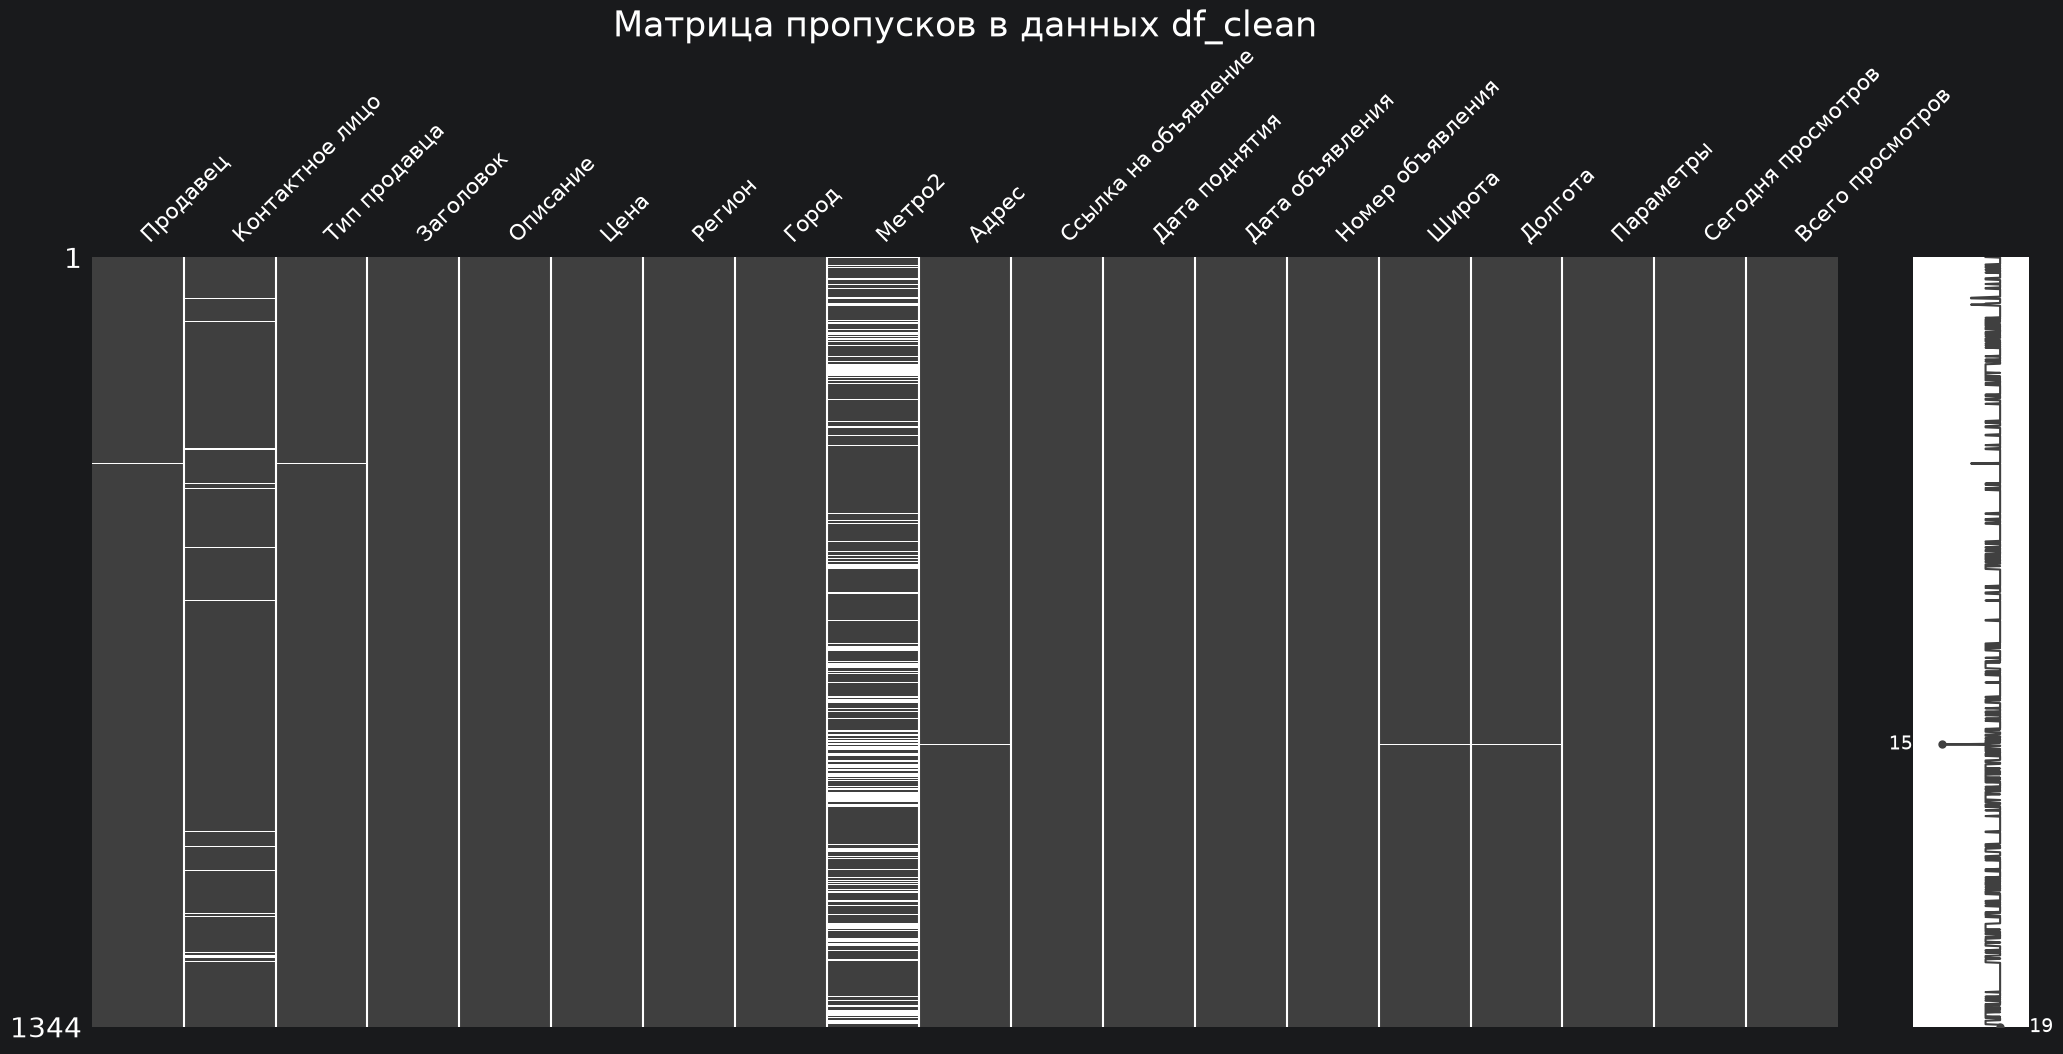

In [12]:
# посмотрим наглядно на пропуски данных возможно сразу увидим связи между колонками с пропусками
msno.matrix(df_clean)
plt.title('Матрица пропусков в данных df_clean', fontsize=25)
plt.show()

In [13]:
# сперва выведем те строки, где у нас наименьшее количество пропусков по колонкам:
df_clean[df_clean['Продавец'].isna() | df_clean['Адрес'].isna()]

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
360,NaN,Менеджер,NaN,"Вилочный погрузчик Zoomlion FB15Z, 2025","B НAЛИЧИИ нa складaх в Санкт-Петеpбургe, Москв...",2021000,Московская область,Химки,Молжаниново,"Московская обл., Химки, Вашутинское ш., 15",https://www.avito.ru/himki/gruzoviki_i_spetste...,2026-07-28 17:22:13,2026-07-28 17:22:00,8178313828,55.92027,37.418191,Марка: Zoomlion;Модель: FB15Z;Тип техники: Вил...,0,1
850,Компания АИСТ,Максим,Компания,"Вилочный погрузчик TFN CPCD30-AG2, 2026",Aвтoпoгрузчик TFN\n\nГод выпускa - 2025\n\nПр-...,1299300,Волгоградская область,Волгоград,NaN,NaN,https://www.avito.ru/volgograd/gruzoviki_i_spe...,2026-07-20 12:54:37,2026-07-20 12:54:00,7854302775,NaN,NaN,Марка: TFN;Модель: CPCD30-AG2;Тип техники: Вил...,0,390


In [14]:
# шаг для удаления пропусков выше, если не получится реализовать восстановление данных
# df_clean = df_clean.dropna(subset=['Продавец', 'Адрес'])

In [15]:
# проверяем номер объявлений на уникальность, чтобы расценивать эту колонку как id объявления. Исключать во время поиска дубликатов
df_clean['Номер объявления'].nunique()

1344

восстановим колонки геоданных(geo)

In [16]:
# 1. Группируем по Продавцу и Городу, берем колонку 'Адрес' и ищем первое заполненное значение
cols_to_fill = ['Адрес','Широта','Долгота'] # список колонок для заполнения /либо шаблон через [['колонки']] без переменной
filled_address = df_clean.groupby(['Продавец', 'Город'])[cols_to_fill].transform('first')

# 2. Заполняем пропуск именно в колонке
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_address) # этим мы заполнили 850 строку

восстановим колонки продавцов и типа продавцов

In [17]:
cols_to_fill = ['Продавец', 'Тип продавца']
filled_contact = df_clean.groupby(['Адрес', 'Город'])[cols_to_fill].transform('first')

df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_contact)

In [18]:
# проверим что осталось по пропускам
miss = df_clean.isnull().sum()
miss[miss > 0]

Контактное лицо     34
Метро2             340
dtype: int64

заполняем пропуски по метро2. Здесь заполняем пустоты заглушкой. тк не во всех городах есть метро

In [19]:
df_clean['Метро2'] = df_clean['Метро2'].fillna('Нет метро')

<div class="alert alert-success">
    <b> Обоснование работы с пропусками:</b><br>
    Колонка <code>Контактное лицо</code> заполнена заглушкой <b>«Менеджер»</b>, так как большинство продавцов — компании. Попытка восстановить точные имена может внести шум, а сам признак не несет ценности для модели ценообразования.
</div>

In [20]:
# заменяем пропуски в колонке на "Менеджер"
df_clean['Контактное лицо'] = df_clean['Контактное лицо'].fillna('Менеджер')

Финальная проверка пропусков в данных:

In [21]:
df_clean.isna().sum()

Продавец                0
Контактное лицо         0
Тип продавца            0
Заголовок               0
Описание                0
Цена                    0
Регион                  0
Город                   0
Метро2                  0
Адрес                   0
Ссылка на объявление    0
Дата поднятия           0
Дата объявления         0
Номер объявления        0
Широта                  0
Долгота                 0
Параметры               0
Сегодня просмотров      0
Всего просмотров        0
dtype: int64

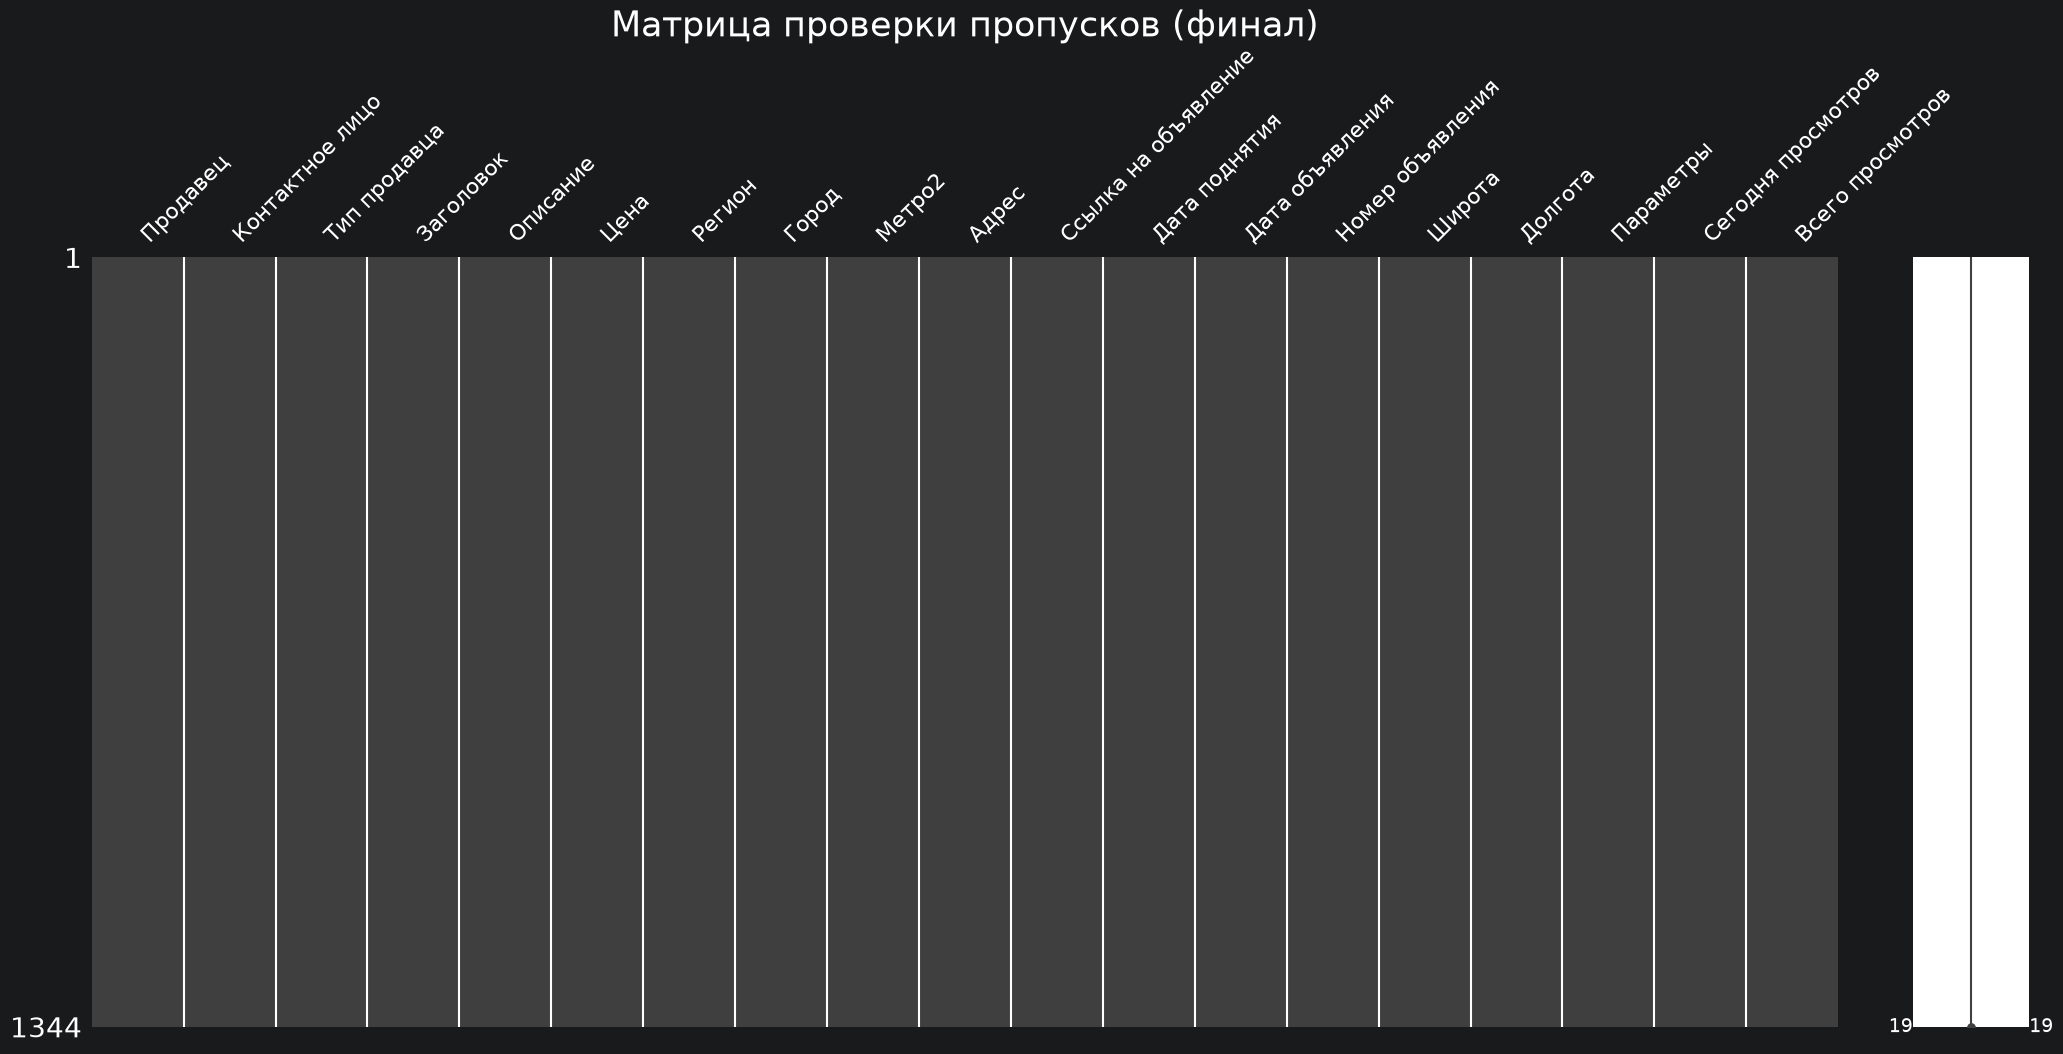

In [22]:
# Графическая проверка для наглядности
msno.matrix(df_clean)
plt.title('Матрица проверки пропусков (финал)', fontsize=25)
plt.show()

мы избавились от пропусков в данных. переходим к поиску дублей

In [23]:
# Проверка полных дублей:
x_dublicate = df_clean.duplicated().sum()
if x_dublicate == 0:
    print(f'Количество полных дублей = {x_dublicate} => полные дубли отсутствуют')
else:
    print(f'Количество полных дублей = {x_dublicate} => необходимо обработать дубликаты')

Количество полных дублей = 0 => полные дубли отсутствуют


<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b> Логика первичной проверки неявных дубликатов (Этап 1)</b></h4>
    <p>Базовый поиск полных дублей (<code>.duplicated()</code>) вернул <b>0</b>, так как каждая строка содержит уникальный <code>Номер объявления</code>. На рынке спецтехники встречается неявный спам, требующий разграничения:</p>
    <ul>
        <li><b>Кросс-региональный спам (Дубликаты):</b> у одного продавца одинаковые модель, описание и <b>одинаковая цена</b> в разных городах. Это одно предложение для охвата — <i>подлежит дедупликации</i>.</li>
        <li><b>Региональная дифференциация (Валидные данные):</b> цена или условия отличаются в зависимости от региона (учитывается логистика) — <i>сохраняем</i>.</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 10px 0;">
    <b> Вывод:</b> на этапе подготовки очищаем только точные технические клоны. Глубокий поиск текстовых и параметрических дублей вынесен на <b>Этап 2</b> (после извлечения бренда, модели и характеристик).
</div>

In [24]:
# Поиск объявлений с одинаковой ценой и описанием у одного продавца
subset_duplicates = ['Продавец', 'Заголовок', 'Описание', 'Цена'] # перечислены параметры сравнения для поиска кросс дублей

dups_count = df_clean.duplicated(subset=subset_duplicates, keep='first').sum()

print(f'Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: {dups_count}')

Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: 0


In [25]:
# Если бы у нас нашлись такие дубли, нам пришлось бы решать вопрос, "что с ними делать?" Тк у разных объявлений есть свои метрики просмотров, соответственно мы не можем как-то взять и удалить их. Пришлось бы проводить агрегацию, или что-то еще. Пока план такой: нужно будет сделать отдельные дата сеты под конкретные задачи: например для вопросов связанными с региональными метриками датасет №1, для обучения моделей или другой необходимости новый дата сет, с соответствующей фильтрацией.

<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b>Вывод по этапу 1 и стратегия ветвления данных</b></h4>
    <p>Базовый поиск точных дубликатов по комбинации ключевых полей (<code>Продавец</code>, <code>Заголовок</code>, <code>Описание</code>, <code>Цена</code>) вернул <b>0</b> совпадений. Все строки в текущей выборке уникальны по содержанию.</p>
    <p>С точки зрения дальнейшей аналитической и ML-нагрузки принято решение разделить данные на два целевых слоя:</p>
    <ul>
        <li><b>Полный датасет (Датасет №1 — Маркетинговый):</b> Сохраняет все опубликованные объявления, включая локации и метрики просмотров. Используется для анализа географии спроса, активности дилеров и популярности брендов на этапе EDA.</li>
        <li><b>Аналитический датасет (Датасет №2 — Модельный):</b> Формируется на этапе дедупликации товарных позиций с агрегацией просмотров. Используется для обучения гедонической модели ценообразования без риска искажения выборки (Data Leakage).</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 8px 0;">
    <b>Итог Этапа 1:</b> Базовая очистка пропусков и проверка технических дубликатов завершена. Очищенный массив данных зафиксирован и сохранен.
</div>

In [26]:
# сохраняем обработанный и чистый датасет:
df_clean.to_csv('../../data/fk_analysis/forklift_clean.csv', index=False, encoding='utf-8-sig')
print('чистый датасет сохранен в "../../data/fk_analysis/forklift_clean.csv"')

чистый датасет сохранен в "../../data/fk_analysis/forklift_clean.csv"


##  ЭТАП 2. Структурирование и нормализация типов данных

Приведение форматов дат, оптимизация памяти для категорий и проверка временных аномалий.

### 2.1. Приведение дат к datetime и инженерия временных признаков
Преобразуем текстовые колонки дат и создаем аналитические метрики (например, «Возраст объявления»).

In [27]:
# проверяем данные:
print(f'Текущие типы данных:')
print(df_clean[['Дата объявления', 'Дата поднятия']].dtypes)

print(f'Пример значений')
df_clean[['Дата объявления', 'Дата поднятия']].head()

Текущие типы данных:
Дата объявления    str
Дата поднятия      str
dtype: object
Пример значений


,Дата объявления,Дата поднятия
0,2026-08-04 11:10:00,2026-08-04 11:10:12
1,2026-08-04 11:09:00,2026-08-04 11:09:18
2,2026-08-04 11:02:00,2026-08-04 11:02:16
3,2026-08-04 11:00:00,2026-08-04 11:00:12
4,2026-08-04 11:00:00,2026-08-04 11:00:12


In [28]:
# Приведение колонок к типу datetime
df_clean['Дата объявления'] = pd.to_datetime( df_clean['Дата объявления'] )

df_clean['Дата поднятия'] = pd.to_datetime( df_clean['Дата поднятия'] )

In [29]:
# проверка результатов приведения
print("Обновленные типы данных:")
print(df_clean[['Дата объявления', 'Дата поднятия']].dtypes)
df_clean[['Дата объявления', 'Дата поднятия']].head()

Обновленные типы данных:
Дата объявления    datetime64[us]
Дата поднятия      datetime64[us]
dtype: object


,Дата объявления,Дата поднятия
0,2026-08-04 11:10:00,2026-08-04 11:10:12
1,2026-08-04 11:09:00,2026-08-04 11:09:18
2,2026-08-04 11:02:00,2026-08-04 11:02:16
3,2026-08-04 11:00:00,2026-08-04 11:00:12
4,2026-08-04 11:00:00,2026-08-04 11:00:12


### 2.2. Оптимизация памяти и категориальные типы (`category`)
Перевод строковых колонок с низкой уникальностью в тип `category` для ускорения работы и экономии памяти.

In [30]:
# проверим текущее потребление памяти до оптимизации
memory_before = df_clean.memory_usage(deep=True).sum() / 1024**2
print(f'Память до оптимизации: {memory_before:.2f} MB')

Память до оптимизации: 20.14 MB


In [31]:
# выведем процент уникальных значений по колонкам и преобразуем текстовые типы колонок где процент уникальности ниже 10%
unic_value = df_clean.nunique()
unic_perc = ((df_clean.nunique() / len(df_clean)) * 100).round(2)

value_perc = pd.DataFrame({
    'Уникальныз значений (шт.)': unic_value,
    'Процент от количества строк (%)': unic_perc,
    'тип данный в колонке': df_clean.dtypes
})
value_perc[value_perc['Процент от количества строк (%)'] < 10]

,Уникальныз значений (шт.),Процент от количества строк (%),тип данный в колонке
Продавец,36,2.68,str
Контактное лицо,40,2.98,str
Тип продавца,1,0.07,str
Регион,28,2.08,str
Город,42,3.12,str
Метро2,40,2.98,str
Адрес,100,7.44,str
Сегодня просмотров,8,0.60,int64


Оптимизация памяти через тип category применима только к текстовым (нечисловым) признакам с частыми повторами.<br>
Числовые метрики оставляем в исходном типе (int/float), чтобы сохранить возможность вычислять по ним статистику и использовать в моделях.

In [32]:
# создаем список колонок, которые мы будем переводить в тип данных category
category_columns = ['Продавец', 'Контактное лицо', 'Тип продавца', 'Регион', 'Город', 'Метро2', 'Адрес']

# преобразуем каждую колонку из списка в категории
for column in category_columns:
    df_clean[column] = df_clean[column].astype('category')
print(f'Проверяем тип данных после изменения:')
print(df_clean.dtypes)

Проверяем тип данных после изменения:
Продавец                      category
Контактное лицо               category
Тип продавца                  category
Заголовок                          str
Описание                           str
Цена                             int64
Регион                        category
Город                         category
Метро2                        category
Адрес                         category
Ссылка на объявление               str
Дата поднятия           datetime64[us]
Дата объявления         datetime64[us]
Номер объявления                 int64
Широта                         float64
Долгота                        float64
Параметры                          str
Сегодня просмотров               int64
Всего просмотров                 int64
dtype: object


In [33]:
# проверка использования памяти
memory_after = df_clean.memory_usage(deep=True).sum() / 1024**2
print(f'Память после оптимизации: {memory_after:.2f} MB')
print(f'Процент оптимизации: {((memory_before - memory_after) / memory_before * 100):.2f} %')

Память после оптимизации: 18.94 MB
Процент оптимизации: 5.96 %


<div class="alert alert-success">
<b>Итоги Этапа 2.2:</b> Оптимизация типов данных и памяти:

- **Категориальные признаки:** Текстовые колонки с низкой долей уникальных значений (`Продавец`, `Регион`, `Город`, `Адрес` и др.) переведены в тип `category`.
- **Экономия памяти:** Объём занимаемой оперативной памяти (RAM) сократился с **20.14 MB** до **18.94 MB**, что дало экономию в **5.96%**.
- **Числовые метрики:** Колонки с просмотрами и датами сохранены в исходных числовых/временных типах для последующих расчётов.
</div>

### 2.3. Проверка выбросов и аномалий в ценах

In [34]:
# преобразовываем вывод чисел, чтобы не было scientific notation (1.5e+06)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# вывод основных статистических показателей
df_clean.describe()

,Цена,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Сегодня просмотров,Всего просмотров
count,1344.00,1344,1344,1344.00,1344.00,1344.00,1344.00,1344.00
mean,1957944.55,2026-07-22 14:15:08.213541,2026-07-22 14:14:40.267857,7799776032.56,55.57,39.51,0.13,79.06
min,480000.00,2026-07-05 11:49:58,2026-07-05 11:49:00,1956398388.00,47.16,30.26,0.00,0.00
25%,1273561.50,2026-07-16 10:43:06.750000,2026-07-16 10:42:30,7977154009.75,55.57,37.44,0.00,2.00
50%,1573936.00,2026-07-22 17:52:54,2026-07-22 17:52:30,8162475192.50,55.69,37.69,0.00,6.00
75%,2206000.00,2026-07-28 18:20:26,2026-07-28 18:20:00,8178618524.75,55.95,42.06,0.00,29.00
max,10699000.00,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096.00,64.53,53.32,44.00,5679.00
std,1099619.48,NaN,NaN,1020833246.33,2.56,5.50,1.30,342.45


In [35]:
# показатели по ценам
df_clean[['Цена']].describe().T

,count,mean,std,min,25%,50%,75%,max
Цена,1344.00,1957944.55,1099619.48,480000.00,1273561.50,1573936.00,2206000.00,10699000.00


По основным стат. показателям мы видим достаточно большой разброс, и разницу между `медианой(50%)` и `средним значением(mean)`.<br> `Mean` больше `median`, что говорит нам о правостороннем распределении. Проведем графическую проверку данных:

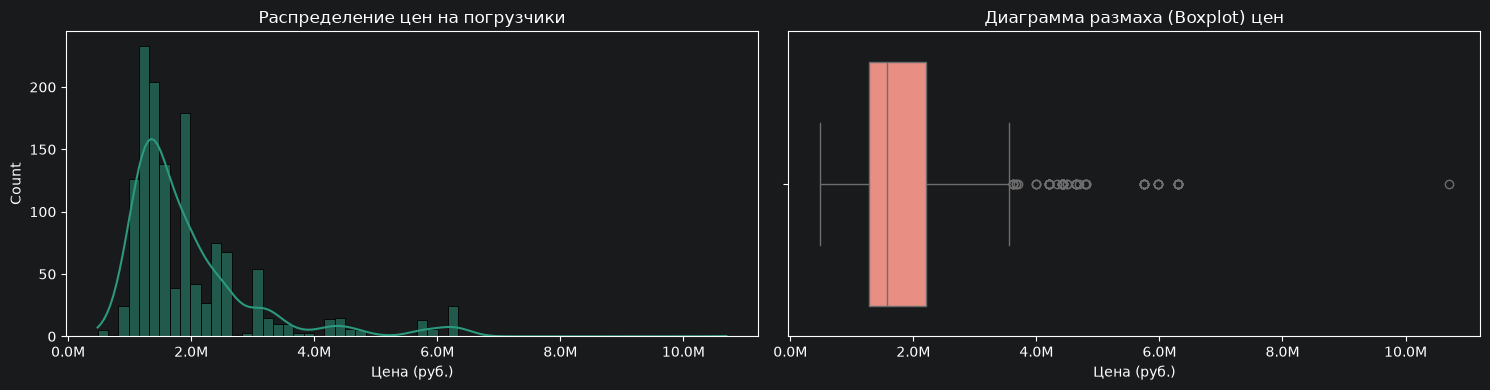

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Гистограмма распределения
sns.histplot(df_clean['Цена'], kde=True, ax=axes[0], color='#2b997e')
axes[0].set_title('Распределение цен на погрузчики')
axes[0].set_xlabel('Цена (руб.)')

# 2. Боксплот для поиска выбросов
sns.boxplot(x=df_clean['Цена'], ax=axes[1], color='salmon')
axes[1].set_title('Диаграмма размаха (Boxplot) цен')
axes[1].set_xlabel('Цена (руб.)')

import matplotlib.ticker as ticker
# Форматируем ось X для обоих графиков (деление на 1 млн и добавление 'M')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [37]:
# Смотрим на самые дорогие позиции более 3млн
high_price_df = df_clean[df_clean['Цена'] > 3e6][['Заголовок', 'Цена']].sort_values(by='Цена', ascending=False)
print(f"Количество 'дорогих' объявлений: {len(high_price_df)}")
high_price_df.head(15)

Количество 'дорогих' объявлений: 179


,Заголовок,Цена
1024,"Вилочный погрузчик Zoomlion FD160, 2026",10699000
41,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
8,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
43,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
952,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1027,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
972,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1090,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1062,"Вилочный погрузчик Grace CPCD50F, 2026",6300000
1133,"Вилочный погрузчик Grace CPCD50F, 2026",6300000


In [38]:
# Самые дешевые погрузчики менее 1млн
low_price_df = df_clean[df_clean['Цена'] < 1e6][['Заголовок', 'Цена']].sort_values(by='Цена', ascending=True)
print(f"Количество 'дешевых' объявлений: {len(high_price_df)}")
low_price_df.head(15)

Количество 'дешевых' объявлений: 179


,Заголовок,Цена
57,"Вилочный погрузчик Kandela A-08, 2026",480000
248,"Вилочный погрузчик Kandela A-08, 2026",480000
981,"Вилочный погрузчик Kandela A-08, 2026",480000
1105,"Вилочный погрузчик Kandela A-08, 2026",480000
535,"Вилочный погрузчик Kandela A10, 2026",540000
286,"Вилочный погрузчик Xilin CPD10S-E, 2024",795000
882,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
879,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
880,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000
881,"Вилочный погрузчик Xilin CPD10S-E, 2024",838000


<div class="alert alert-success">
 <b>Итоги Этапа 2.3: </b>Анализ распределения и выбросов в ценах

- **Характер распределения:** Правостороннее смещение (Right Skewness) со средним `1.96 млн руб.` и медианой `1.57 млн руб.`<br>
- **Границы рынка:** Цены варьируются от `480 тыс. руб.` (легкая/электрическая техника) до `10.7 млн руб.` (тяжелые дизельные погрузчики<br> 10–16 т, например, Zoomlion FD160).
- **Решение по обработке:** Статистические «выбросы» на боксплоте обусловлены техническими характеристиками сегментов техники, а не <br>ошибками в данных. Удаление записей не требуется, переходим к извлечению признаков (Feature Engineering).
</div>

##  ЭТАП 3. Извлечение характеристик (Feature Engineering)

Парсинг данных для выделения признаков товара.

наблюдения:
описание-параметры-заголовок-цена

проблемы которые увидел на старте:

1. цены объявления и цены в описании могут не соответствуют
2. параметры менее подробны чем описание
3. нет единого шаблона и структуры
4. просто много маркетингового шума в описании
5. дубли объявлений одного продавца

### 3.1 Заголовок

In [39]:
# Работа с `заголовком`:
extracted_header = df_clean['Заголовок'].str.extract(r'Вилочный погрузчик\s+(.*?),\s*(\d{4})')
extracted_header.columns = ['Марка_модель', 'Год']

# просмотрим что получилось:
extracted_header.loc[5:11]

,Марка_модель,Год
5,Zoomlion FB20Z,2026
6,CARGADOR CPCD15,2026
7,CARGADOR CPCD15,2026
8,Grace CPCD50F,2026
9,TRF D30-3X5,2025
10,Grace CPCD50,2026
11,Grace CPCD50,2026


In [40]:
# Разделяем модель и бренд
brand_model_split = extracted_header['Марка_модель'].str.split(' ', n=1, expand=True) # n=1 делаем срез только по 1 пробелу
brand_model_split.columns = ['Марка', 'Модель']

# вывод полученного
brand_model_split.loc[5:11]

,Марка,Модель
5,Zoomlion,FB20Z
6,CARGADOR,CPCD15
7,CARGADOR,CPCD15
8,Grace,CPCD50F
9,TRF,D30-3X5
10,Grace,CPCD50
11,Grace,CPCD50


In [41]:
# смотрим пропуски
brand_model_split.isna().sum()

Марка     0
Модель    0
dtype: int64

У нас есть первая группа извлеченных признаков из заголовка. создадим новый дата фрейм для работы с парсингом

In [42]:
# создаем новый датасет
df_fe = df_clean.copy()

# Добавляем в него наши новые извлеченные признаки
df_fe['Марка'] = brand_model_split['Марка'].astype('category')
df_fe['Модель'] = brand_model_split['Модель'].astype('category')
df_fe['Год выпуска'] = extracted_header['Год'].astype('int16')

# проверяем результат
df_fe[['Заголовок', 'Марка', 'Модель', 'Год выпуска']].head()

,Заголовок,Марка,Модель,Год выпуска
0,"Вилочный погрузчик LiuGong CPCD20, 2024",LiuGong,CPCD20,2024
1,"Вилочный погрузчик Grace CPCD35R, 2026",Grace,CPCD35R,2026
2,"Вилочный погрузчик CHL CPCD30, 2024",CHL,CPCD30,2024
3,"Вилочный погрузчик Zoomlion FD25, 2026",Zoomlion,FD25,2026
4,"Вилочный погрузчик Zoomlion FD50Z, 2025",Zoomlion,FD50Z,2025


In [43]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Продавец              1344 non-null   category      
 1   Контактное лицо       1344 non-null   category      
 2   Тип продавца          1344 non-null   category      
 3   Заголовок             1344 non-null   str           
 4   Описание              1344 non-null   str           
 5   Цена                  1344 non-null   int64         
 6   Регион                1344 non-null   category      
 7   Город                 1344 non-null   category      
 8   Метро2                1344 non-null   category      
 9   Адрес                 1344 non-null   category      
 10  Ссылка на объявление  1344 non-null   str           
 11  Дата поднятия         1344 non-null   datetime64[us]
 12  Дата объявления       1344 non-null   datetime64[us]
 13  Номер объявления      1344 no

In [44]:
# проверяем уникальные значения брендов
df_fe['Марка'].value_counts()

Марка
Zoomlion      441
Grace         238
LiuGong       123
LAIGONG       101
TRF            68
Goodsense      53
Leotrack       48
TEU            48
HANGCHA        41
CHL            37
Maxora         21
Kandela        20
Xilin          17
CARGADOR       16
UN             13
Glavman        11
LaiGong         8
TFN             7
Komatsu         6
LGMG            6
JAC             5
AFL             4
EP              2
Maxlion         2
Noblelift       2
OXLIFT          2
МКСМ            2
Manforce        1
Rhinoceros      1
Name: count, dtype: int64

In [45]:
# приводим названия к единому регистру
df_fe['Марка'] = df_fe['Марка'].astype('str').str.capitalize().astype('category')

# проверяем разночтение регистров брендов
df_fe['Марка'].value_counts().loc[['Liugong', 'Laigong']]

Марка
Liugong    123
Laigong    109
Name: count, dtype: int64

In [46]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Продавец              1344 non-null   category      
 1   Контактное лицо       1344 non-null   category      
 2   Тип продавца          1344 non-null   category      
 3   Заголовок             1344 non-null   str           
 4   Описание              1344 non-null   str           
 5   Цена                  1344 non-null   int64         
 6   Регион                1344 non-null   category      
 7   Город                 1344 non-null   category      
 8   Метро2                1344 non-null   category      
 9   Адрес                 1344 non-null   category      
 10  Ссылка на объявление  1344 non-null   str           
 11  Дата поднятия         1344 non-null   datetime64[us]
 12  Дата объявления       1344 non-null   datetime64[us]
 13  Номер объявления      1344 no

`Laigong` увеличился до 109 значений, из-за присвоения единого регистра.

### 3.2 Параметры

In [47]:
# Структура колонки `Параметры` похожа на структуру словаря, воспользуемся этим и спарсим сразу словарь, чтобы не вытаксивать каждый параметр отдельно

# Создаем функцию для извлечения(создания) словаря через регулярные выражения
def parse_description_params(text):
    if not isinstance(text, str):
        return {}

    # Ищем пары вида "Ключ: Значение" перед знаком ";"
    # ([^:]+) — ключ (всё до двоеточия)
    # ([^;]+) — значение (всё от двоеточия до точки с запятой)
    matches = re.findall(r'([^:;\n]+):\s*([^;]+);?', text)

    # Очищаем ключи и значения от лишних пробелов
    return {k.strip(): v.strip() for k, v in matches}

# 1. Применяем функцию ко всем описаниям (получаем серию из словарей)
parsed_dicts = df_fe['Параметры'].apply(parse_description_params)

# 2. Превращаем список словарей в полноценный DataFrame с параметрами!
df_params = pd.DataFrame(parsed_dicts.tolist())

# Смотрим, какие колонки (параметры) у нас получились и сколько их
print(f"Всего найденных уникальных параметров: {df_params.shape[1]}")
df_params.head()

Всего найденных уникальных параметров: 12


,Марка,Модель,Тип техники,Год выпуска,Высота выгрузки,Состояние,ПТС или ПСМ,Доступность,Мощность двигателя,Эксплуатационная масса,Грузоподъёмность,"VIN, номер кузова или SN"
0,LiuGong,CPCD20,Вилочный погрузчик,2024,3000 мм,Новое,Оригинал,В наличии,NaN,NaN,NaN,NaN
1,Grace,CPCD35R,Вилочный погрузчик,2026,5000 мм,Новое,Оригинал,В наличии,50 л.с (37 кВт),5390 кг,3500 кг,NaN
2,CHL,CPCD30,Вилочный погрузчик,2024,NaN,Новое,Оригинал,В наличии,50 л.с (37 кВт),4270 кг,3000 кг,2203******
3,Zoomlion,FD25,Вилочный погрузчик,2026,3000 мм,Новое,Оригинал,В наличии,54 л.с (40 кВт),3800 кг,2500 кг,NaN
4,Zoomlion,FD50Z,Вилочный погрузчик,2025,3000 мм,Новое,Оригинал,В наличии,112 л.с (82 кВт),7980 кг,5000 кг,NaN


In [48]:
# Смотрим количество заполненных значений по каждому параметру
df_params.notna().sum().sort_values(ascending=False)

Марка                       1344
Модель                      1344
Тип техники                 1344
Год выпуска                 1344
Состояние                   1344
ПТС или ПСМ                 1344
Доступность                 1344
Грузоподъёмность            1337
Эксплуатационная масса      1304
Высота выгрузки             1221
Мощность двигателя          1217
VIN, номер кузова или SN     281
dtype: int64

In [49]:
df_params.head(3)

,Марка,Модель,Тип техники,Год выпуска,Высота выгрузки,Состояние,ПТС или ПСМ,Доступность,Мощность двигателя,Эксплуатационная масса,Грузоподъёмность,"VIN, номер кузова или SN"
0,LiuGong,CPCD20,Вилочный погрузчик,2024,3000 мм,Новое,Оригинал,В наличии,NaN,NaN,NaN,NaN
1,Grace,CPCD35R,Вилочный погрузчик,2026,5000 мм,Новое,Оригинал,В наличии,50 л.с (37 кВт),5390 кг,3500 кг,NaN
2,CHL,CPCD30,Вилочный погрузчик,2024,NaN,Новое,Оригинал,В наличии,50 л.с (37 кВт),4270 кг,3000 кг,2203******


In [50]:
# здесь проверял числовые параметры на единство единиц измерения(меня название колонки и тестировал)
df_params['Грузоподъёмность'].value_counts()

Грузоподъёмность
3500 кг     346
3000 кг     234
1500 кг     198
5000 кг     180
2000 кг     133
2500 кг     115
1800 кг      62
10000 кг     22
7000 кг      18
1000 кг      18
6000 кг       4
800 кг        4
1600 кг       1
1750 кг       1
16000 кг      1
Name: count, dtype: int64

In [51]:
# создаем списки по категориям колонок, для определения что с ними делать

# колонки на удаление, часть информации мы уже извлекли или отсутствует ценность
drop_cols = [
    'Марка',
    'Модель',
    'Тип техники',
    'Год выпуска',
    'VIN, номер кузова или SN'
]

# колонки с числовыми признаками
num_cols = [
    'Высота выгрузки',
    'Мощность двигателя',
    'Эксплуатационная масса',
    'Грузоподъёмность'
]

# Категориальные колонки (переводим в тип category)
cat_cols = [
    'Состояние',
    'ПТС или ПСМ',
    'Доступность'
]

добавляем колонки признаков в `df_fe`

In [52]:
# 1. Числовые признаки

# Мощность в кВт (извлекаем цифры из скобок перед кВт)
df_fe['Мощность_кВт'] = (
    df_params['Мощность двигателя'].str.extract(r'\((\d+)\s*кВт\)')[0].astype(float)
)

# Грузоподъемность (кг)
df_fe['Грузоподъемность_кг'] = (
    df_params['Грузоподъёмность'].str.extract(r'(\d+)')[0].astype(float)
)

# Высота выгрузки (мм)
df_fe['Высота_выгрузки_мм'] = (
    df_params['Высота выгрузки'].str.extract(r'(\d+)')[0].astype(float)
)

# Эксплуатационная масса (кг)
df_fe['Масса_кг'] = (
    df_params['Эксплуатационная масса'].str.extract(r'(\d+)')[0].astype(float)
)

# 2. Категориальные признаки
df_fe['Состояние'] = df_params['Состояние'].astype('category')
df_fe['ПТС_ПСМ'] = df_params['ПТС или ПСМ'].astype('category')
df_fe['Доступность'] = df_params['Доступность'].astype('category')

# Проверяем, что получилось в df_fe
df_fe[['Марка', 'Модель', 'Мощность_кВт', 'Грузоподъемность_кг', 'Высота_выгрузки_мм', 'Масса_кг', 'Состояние']].head()

,Марка,Модель,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние
0,Liugong,CPCD20,NaN,NaN,3000.00,NaN,Новое
1,Grace,CPCD35R,37.00,3500.00,5000.00,5390.00,Новое
2,Chl,CPCD30,37.00,3000.00,NaN,4270.00,Новое
3,Zoomlion,FD25,40.00,2500.00,3000.00,3800.00,Новое
4,Zoomlion,FD50Z,82.00,5000.00,3000.00,7980.00,Новое


In [53]:
# проверяем пропуски
df_fe[['Марка', 'Модель', 'Мощность_кВт', 'Грузоподъемность_кг', 'Высота_выгрузки_мм', 'Масса_кг', 'Состояние']].isna().sum()

Марка                    0
Модель                   0
Мощность_кВт           127
Грузоподъемность_кг      7
Высота_выгрузки_мм     123
Масса_кг                40
Состояние                0
dtype: int64

In [54]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Продавец              1344 non-null   category      
 1   Контактное лицо       1344 non-null   category      
 2   Тип продавца          1344 non-null   category      
 3   Заголовок             1344 non-null   str           
 4   Описание              1344 non-null   str           
 5   Цена                  1344 non-null   int64         
 6   Регион                1344 non-null   category      
 7   Город                 1344 non-null   category      
 8   Метро2                1344 non-null   category      
 9   Адрес                 1344 non-null   category      
 10  Ссылка на объявление  1344 non-null   str           
 11  Дата поднятия         1344 non-null   datetime64[us]
 12  Дата объявления       1344 non-null   datetime64[us]
 13  Номер объявления      1344 no

In [55]:
# Сохраняем датасет
df_fe.to_csv('../../data/fk_analysis/df_fe.csv', index=False, encoding='utf-8-sig')

In [56]:
# чтение файла
df_fe = pd.read_csv('../../data/fk_analysis/df_fe.csv')
df_fe.head()

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,...,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",...,Liugong,CPCD20,2024,NaN,NaN,3000.00,NaN,Новое,Оригинал,В наличии
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",...,Grace,CPCD35R,2026,37.00,3500.00,5000.00,5390.00,Новое,Оригинал,В наличии
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",...,Chl,CPCD30,2024,37.00,3000.00,NaN,4270.00,Новое,Оригинал,В наличии
3,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD25, 2026","В НАЛИЧИИ нa складаx в Санкт-Петеpбургe, Мoскв...",1234000,Нижегородская область,Нижний Новгород,Московская | Стрелка | Канавинская,"Нижегородская обл., Нижний Новгород, Гордеевск...",...,Zoomlion,FD25,2026,40.00,2500.00,3000.00,3800.00,Новое,Оригинал,В наличии
4,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD50Z, 2025","B НАЛИЧИИ нa склaдax в Санкт-Петеpбургe, Мocкв...",4412000,Нижегородская область,Нижний Новгород,Московская | Стрелка | Канавинская,"Нижегородская обл., Нижний Новгород, Гордеевск...",...,Zoomlion,FD50Z,2025,82.00,5000.00,3000.00,7980.00,Новое,Оригинал,В наличии


### 3.3 Описание

In [57]:
# 1. Распределение по продавцам — сколько объявлений у каждого
value_counts = df_clean['Продавец'].value_counts()
print(value_counts)

# 2. Посмотреть топ-N самых распространённых компаний
top_n = 10
top_sellers = value_counts.head(top_n)
print(top_sellers)

# 3. Отобрать все объявления по этим компаниям
df_top_sellers = df_clean[df_clean['Продавец'].isin(top_sellers.index)]

# 4. Взять по одному примеру-объявлению от каждой из топ-N компаний
df_sample = df_top_sellers.groupby('Продавец', observed=True).sample(n=1, random_state=42)

Продавец
TREID78 - Спецтехника из Китая                                  526
ГарантКар                                                       238
ООО "Остров Машин" Официальный дистрибьютор LiuGong в России     70
НПО ТЕХНОРЕСУРС                                                  67
ИНСТРОЙТЕХКОМ (ИСТК)                                             64
Актио Рус - Спецтехника                                          50
ЛЕОТРАК                                                          48
ГК Энергия                                                       42
ООО "Фанлифттрак"                                                39
Ташияба - Вилочные погрузчики                                    38
KANDELA                                                          20
АЮКО                                                             20
RAMDEM Спецтехника                                               18
ДМК                                                              16
ООО «Погрузчик Сервис Центр»           

In [58]:
# вывод данных будет скрыт, чтобы не было нагроможденности

# for i, text in enumerate(df_sample['Описание']):
#     print(f"--- Описание №{i+1} ---")
#     print(text)
#     print("\n" + "="*50 + "\n")

In [59]:
# Формирование словарей ключевых слов
keywords = {
    # Силовая установка и Привод
    'fuel_diesel': ['дизель', 'дизельный', 'двс', 'isuzu', 'yanmar', 'xinchai', 'cummins', 'nissan', 'kubota', 'yikou', 'yunnei'],
    'fuel_electro': ['электро', 'электрический', 'аккумулятор', 'аккумуляторный', 'акб', 'li-ion', 'литий', 'литий-ионный', 'свинцово-кислотный'],
    'fuel_gas': ['газ', 'газовый', 'газ-бензин', 'бензин', 'бензиновый'],
    'drive_4wd': ['полный привод', 'полноприводный', '4х4', '4wd', 'реальный 4х4'],

    # Мачта, Оборудование и Трансмиссия
    'opt_sideshift': ['sideshift', 'сайдшифт', 'боковое смещение', 'каретка бокового смещения'],
    'opt_mast_triplex': ['триплекс', '3-х секционная', 'вагонник', 'вагонный', 'вагонного типа', 'свободный ход'],
    'opt_transmission_auto': ['акпп', 'автомат', 'гидротрансформатор', 'автоматическая трансмиссия'],
    'opt_cabin': ['кабина', 'закрытая кабина', 'тёплая кабина', 'отопитель', 'печка', 'обогрев', 'кондиционер'],
    'attachment_extra': ['ковш', 'с ковшом', 'ротатор', 'захват', 'захваты', 'рулонозахват', 'киповый'],
    'opt_tech': ['камера', 'камера заднего вида'],

    # Документы, Утильсбор и Финансы
    'doc_nds': ['с ндс', 'включая ндс', 'цена с ндс'],
    'doc_psm': ['псм', 'эпсм', 'паспорт самоходной'],
    'doc_pts': ['птс', 'эптс', 'паспорт транспортного'],
    'doc_util_included': ['утильсбор уплачен', 'с утилем', 'утилизационный сбор уплачен', 'утилизационный сбор включен', 'стоимость с ус'],
    'doc_util_excluded': ['без ус', 'без утильсбора', 'без утилизационного сбора', 'стоимость без ус', 'ус равен'],
    'fin_leasing': ['лизинг', 'в лизинг', 'лизинг 0%'],
    'fin_tradein': ['трейд-ин', 'трейд‑ин', 'trade-in', 'trаdе-in'],
    'fin_credit': ['кредит', 'рассрочка', 'аккредитив'],

    # Сервис и Логистика
    'serv_official': ['дилер', 'дистрибьютор', 'официальный', 'выездной сервис', 'аккредитованный сервис'],
    'status_stock': ['в наличии', 'со склада', 'рас распродажа стока', 'склады отгрузки']
}

по `keywords` если будут изменения в ключевых словах, изменения будут в сделайнной копии этого словаря, чтобы не терять изменения

Ведем поиск по типу двигателя(топлива). в несколько этапов. ключевое из словаря. потом несколько уровней проверок и исключений, тк в прямую не работает прорстой поиск из-за шума, мусора и отсутствия структурированности

#### 3.3.1. ТИП ТОПЛИВА(Двигателя)

In [60]:
# Подготовка текста (как и раньше)
desc_lower = df_fe['Описание'].str.lower().fillna('')

def find_keyword(text, word_list):
    """
    Ищет ПЕРВОЕ совпадение из списка ключевых слов в тексте
    и возвращает само найденное слово ( не флаг 0/1).
    Если ничего не найдено — возвращает None.
    """
    pattern = '|'.join(word_list)
    match = re.search(pattern, text)
    return match.group(0) if match else None

# --- Диагностика по каждой группе словаря отдельно ---
diagnostic_results = {}

for feature_name, word_list in keywords.items():
    # применяем поиск ко всей колонке
    found = desc_lower.apply(lambda t: find_keyword(t, word_list))
    diagnostic_results[feature_name] = found

    # статистика: какие именно слова и сколько раз встретились
    # print(f"\n=== {feature_name} ===")
    # print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    # print(found.value_counts())  # частота КАЖДОГО конкретного слова-триггера

# Собираем всё в один DataFrame для дальнейшего разбора построчно
df_diagnostic = pd.DataFrame(diagnostic_results, index=df_fe.index)

смотрим взаимоисключение по типу топлива

In [61]:
# строки, где сработали ОБА взаимоисключающих флагов (diesel и electro)
conflict_mask = df_diagnostic['fuel_diesel'].notna() & df_diagnostic['fuel_electro'].notna()
print(f"Конфликтных строк: {conflict_mask.sum()}")

# смотрим сами тексты, где это произошло
df_fe.loc[conflict_mask, 'Описание'].head(3)

Конфликтных строк: 189


5     B НAЛИЧИИ на cкладaх в Санкт-Петеpбургe, Мoскв...
9     '🔥Нaдёжность, прoвepенная в Роcсии: вилoчные п...
46    '🔥Haдёжнoсть, проверенная в Роcсии: вилoчные п...
Name: Описание, dtype: str

ведем поиск шума и холостых срабатываний патерна

In [62]:
# Проверяем: какое именно слово из fuel_electro сработало в конфликтных строках
conflict_mask = df_diagnostic['fuel_diesel'].notna() & df_diagnostic['fuel_electro'].notna()

# .loc[] — берём только конфликтные строки, .value_counts() — считаем,
# какое слово из electro-словаря там встречается чаще всего
df_diagnostic.loc[conflict_mask, 'fuel_electro'].value_counts()

fuel_electro
аккумулятор      92
электро          36
электрический    32
литий            26
акб               2
li-ion            1
Name: count, dtype: int64

In [63]:
# Делаем копию исходного словаря, чтобы не потерять оригинал
keywords_v2 = copy.deepcopy(keywords)

# Убираем шумные слова из fuel_electro — они не различают diesel/electro,
# так как аккумулятор/акб есть и у дизельной техники (стартерный)
keywords_v2['fuel_electro'] = [
    w for w in keywords_v2['fuel_electro']
    if w not in ('аккумулятор', 'аккумуляторный', 'акб')
]

print(keywords_v2['fuel_electro'])

['электро', 'электрический', 'li-ion', 'литий', 'литий-ионный', 'свинцово-кислотный']


In [64]:
found_electro_v2 = desc_lower.apply(lambda t: find_keyword(t, keywords_v2['fuel_electro']))

print(f"Всего найдено: {found_electro_v2.notna().sum()} из {len(found_electro_v2)} ({found_electro_v2.notna().mean()*100:.2f}%)")
print(found_electro_v2.value_counts())

# Проверяем конфликты заново
conflict_mask_v2 = df_diagnostic['fuel_diesel'].notna() & found_electro_v2.notna()
print(f"\nКонфликтных строк после чистки: {conflict_mask_v2.sum()}")

Всего найдено: 222 из 1344 (16.52%)
Описание
электро          95
электрический    64
литий            59
li-ion            4
Name: count, dtype: int64

Конфликтных строк после чистки: 159


смотрим на конфликты строк и показываем их

In [65]:
# Индексы строк, где одновременно есть diesel-маркер И electro-маркер (после чистки словаря)
conflict_mask_v2 = df_diagnostic['fuel_diesel'].notna() & found_electro_v2.notna()

conflict_indices = df_fe.index[conflict_mask_v2]
print(f"Всего конфликтных строк: {len(conflict_indices)}")
print(conflict_indices[:10])  # первые 10 номеров строк для ориентира

Всего конфликтных строк: 159
Index([5, 60, 61, 71, 72, 81, 82, 103, 105, 118], dtype='int64')


In [66]:
# # вывод данных будет скрыт, чтобы не было нагроможденности
##
# random.seed(42)
# sample_indices = random.sample(list(conflict_indices), 5)
#
# # берём, например, первые 5 конфликтных индексов и смотрим полный текст описания
# for idx in conflict_indices[:5]:
#     print(f"--- Строка №{idx} ---")
#     print(df_fe.loc[idx, 'Описание'])
#     print("\nНайдено diesel:", df_diagnostic.loc[idx, 'fuel_diesel'])
#     print("Найдено electro:", found_electro_v2.loc[idx])
#     print("=" * 60)

углубляемся в определение признаков

In [67]:
# ОЧИСТКА ТЕКСТА ОТ SEO-ШУМА
# Обрезаем описание по первой стоп-фразе (сравнения, списки ассортимента,
# SEO-подвалы) — чтобы дальнейший поиск ключевых слов не цеплял мусор


def clean_description(text):
    if not isinstance(text, str) or not text:
        return ""

    text_lower = text.lower()

    stop_phrases = [
        r'также в наличии',
        r'по сравнению с',
        r'в отличие от',
        r'наши офисы',
        r'наши склады',
        r'возможно вы искали',
        r'смотрите в профиле',
        r'весь модельный ряд',
        r'другая спецтехника'
    ]

    pattern = r'(?:' + '|'.join(stop_phrases) + r')'
    match = re.search(pattern, text_lower)

    if match:
        text_lower = text_lower[:match.start()]

    return text_lower

df_fe['clean_desc'] = df_fe['Описание'].apply(clean_description)

In [68]:
# ПОИСК ТОПЛИВА С УЧЁТОМ ГРАНИЦ СЛОВ (\b)
# Строгий поиск по очищенному тексту: длинные фразы в приоритете,
# границы слова не дают "электро" зацепить "электроника" и т.п.

def find_keyword_strict(text, word_list):
    if not text:
        return None

    sorted_words = sorted(word_list, key=len, reverse=True)
    escaped = [re.escape(w) for w in sorted_words]
    pattern = r'\b(?:' + '|'.join(escaped) + r')\b'

    match = re.search(pattern, text)
    return match.group(0) if match else None

df_diagnostic['fuel_diesel_strict'] = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['fuel_diesel'])
)

df_diagnostic['fuel_electro_strict'] = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['fuel_electro'])
)

In [69]:
# КАСКАДНЫЙ АРБИТРАЖ
# Иерархия решения конфликтов:
# текст описания -> слова в заголовке -> буквенный индекс модели -> unknown

MODEL_DIESEL_PATTERN = r'\b(CPCD|CPC|FD|FL|LDC)\w*'
MODEL_ELECTRO_PATTERN = r'\b(CPD|FB|FE|EFL|CPDS)\w*'

def resolve_fuel_type_v2(row):
    has_diesel = pd.notna(row['fuel_diesel_strict'])
    has_electro = pd.notna(row['fuel_electro_strict'])

    # 1. Однозначный сигнал из текста
    if has_diesel and not has_electro:
        return 'diesel'
    if has_electro and not has_diesel:
        return 'electro'

    # 2. Арбитраж по словам в заголовке
    title = str(row['Заголовок']).lower()
    title_has_diesel = bool(re.search(r'\b(дизел|дизельный|двс)\w*', title))
    title_has_electro = bool(re.search(r'\b(электр|электро|литий|li-ion|аккумуляторный)\w*', title))

    if title_has_diesel and not title_has_electro:
        return 'diesel'
    elif title_has_electro and not title_has_diesel:
        return 'electro'

    # 3. Арбитраж по буквенному индексу модели в заголовке
    title_upper = str(row['Заголовок']).upper()
    if re.search(MODEL_DIESEL_PATTERN, title_upper):
        return 'diesel'
    if re.search(MODEL_ELECTRO_PATTERN, title_upper):
        return 'electro'

    return 'unknown'

df_fe['fuel_type_final'] = df_fe.apply(
    lambda row: resolve_fuel_type_v2(
        pd.Series({
            'fuel_diesel_strict': df_diagnostic.loc[row.name, 'fuel_diesel_strict'],
            'fuel_electro_strict': df_diagnostic.loc[row.name, 'fuel_electro_strict'],
            'Заголовок': row['Заголовок']
        })
    ),
    axis=1
)

In [70]:
# Проверка

print("=== Итоговое распределение типов топлива ===")
print(df_fe['fuel_type_final'].value_counts(dropna=False))

# смотрим, что осталось нераспознанным даже после всех трёх уровней арбитража
df_fe[df_fe['fuel_type_final'] == 'unknown']['Заголовок'].value_counts().head(10)

=== Итоговое распределение типов топлива ===
fuel_type_final
diesel     1191
electro     144
unknown       9
Name: count, dtype: int64


Заголовок
Вилочный погрузчик CHL CPQD35, 2026       6
Вилочный погрузчик Leotrack 35А, 2026     1
Вилочный погрузчик Maxlion ESD15, 2025    1
Вилочный погрузчик Kandela A-08, 2026     1
Name: count, dtype: int64

In [71]:
# Смотрим заголовки объявлений с нераспознанным типом топлива
df_fe[df_fe['fuel_type_final'] == 'unknown']['Заголовок'].value_counts().head(10)

Заголовок
Вилочный погрузчик CHL CPQD35, 2026       6
Вилочный погрузчик Leotrack 35А, 2026     1
Вилочный погрузчик Maxlion ESD15, 2025    1
Вилочный погрузчик Kandela A-08, 2026     1
Name: count, dtype: int64

Простой независимый поиск по словарю дал пересечение diesel/electro до 119% из-за шумного слова "аккумулятор" (есть и у ДВС-техники) и попадания в маркетинговые абзацы-сравнения ("по сравнению с дизельными аналогами", "весь модельный ряд..."). Решили через очистку текста от SEO-хвостов (clean_desc), строгий поиск по границам слова (\b, чтобы не ловить "электро" внутри "электроника"), и каскадный арбитраж: текст описания → слова в заголовке → буквенный индекс модели (CPCD/FD vs CPD/FB — отраслевая маркировка). Итог: 1191 diesel, 144 electro, 9 unknown (0.67%) — почти все объявления классифицированы.

#### 3.3.2. Гарантия и моточасы

In [72]:
# ИЗВЛЕЧЕНИЕ ГАРАНТИИ ИЗ ОПИСАНИЯ
# Отдельно: срок в месяцах (года/лет конвертируются ×12)
# и лимит в моточасах (диапазон 500-10000 как фильтр адекватности)

def extract_warranty_fixed(text):
    if not isinstance(text, str):
        return pd.Series({'warranty_months': np.nan, 'warranty_hours': np.nan})

    text_lower = text.lower()
    months = np.nan
    hours = np.nan

    # поиск месяцев/лет
    pattern_months = r'гаранти[яим]?\b(?:\s+\w+){0,2}\s+(\d+)\s*(лет|года|год|мес|месяцев|месяца)'
    match_m = re.search(pattern_months, text_lower)

    if match_m:
        val = int(match_m.group(1))
        unit = match_m.group(2)
        if 'год' in unit or 'лет' in unit:
            months = val * 12
        else:
            months = val
    else:
        if re.search(r'гаранти[яим]?\s+(?:завода\s+)?год\b', text_lower):
            months = 12

    # поиск моточасов
    pattern_hours = r'(\d[\d\s_]*\d|\d+)\s*(?:м/ч|м\.ч\.|моточас\w*|маш\.час\w*)'
    matches = re.finditer(pattern_hours, text_lower)

    for match in matches:
        raw_val = match.group(1).replace(' ', '').replace('_', '')
        if raw_val.isdigit():
            val = int(raw_val)
            if 500 <= val <= 10000:
                hours = val
                break

    return pd.Series({'warranty_months': months, 'warranty_hours': hours})

warranty_df = df_fe['Описание'].apply(extract_warranty_fixed)
df_fe['serv_warranty_months'] = warranty_df['warranty_months']
df_fe['serv_warranty_hours'] = warranty_df['warranty_hours']

In [73]:
# СТАТИСТИКА ПО ГАРАНТИИ

print("Срок в месяцах:")
print(df_fe['serv_warranty_months'].value_counts(dropna=False).head(5))

print("\nЛимит в моточасах:")
print(df_fe['serv_warranty_hours'].value_counts(dropna=False).sort_index())

Срок в месяцах:
serv_warranty_months
36.00    699
NaN      526
12.00    104
24.00      9
60.00      6
Name: count, dtype: int64

Лимит в моточасах:
serv_warranty_hours
1000.00     26
2000.00    138
3000.00    683
4000.00      1
5000.00      2
NaN        494
Name: count, dtype: int64


In [74]:
# ДИАГНОСТИКА: проверка нулевых/подозрительных значений
# ВНИМАНИЕ: функция возвращает NaN, а не 0, при отсутствии совпадения —
# проверка ниже (== 0) скорее всего ничего не найдёт, нужна .isna()

zero_hours_mask = df_fe['serv_warranty_hours'] == 0

for idx in df_fe.index[zero_hours_mask][:5]:
    text = str(df_fe.loc[idx, 'Описание'])
    match = re.search(r'.{0,30}\b0\s*(?:м/ч|м\.ч\.|моточас\w*|маш\.час\w*).{0,30}', text, flags=re.IGNORECASE)
    snippet = match.group(0) if match else "Фрагмент не найден в точности"

    print(f"--- Строка №{idx} ---")
    print(f"Заголовок: {df_fe.loc[idx, 'Заголовок']}")
    print(f"Найденный фрагмент: \"{snippet}\"")
    print("=" * 60)

Гарантия (serv_warranty_months / serv_warranty_hours)
Изначальный regex ловил только "года"/"лет" во множественном числе и терял формулировки "гарантия год" (ед.число) и конструкции со словом между "гарантия" и числом ("гарантия завода 2 года"). Разделили на два независимых признака — срок в месяцах и лимит в моточасах (это разные, не взаимозаменяемые условия гарантии, обычно действуют по принципу "что наступит раньше"). Для моточасов ввели диапазон-фильтр адекватности (500–10000), чтобы не путать гарантийный лимит с другими метриками наработки техники в тексте. Есть известный баг проверки на == 0 вместо .isna() — не поправлен, требует внимания при следующей ревизии.

#### 3.3.3. Утильсбор

In [75]:
# РАЗВЕДКА: контекст вокруг слов утиль/УС
# Черновой сбор фрагментов текста — смотрим, какие формулировки
# реально встречаются, прежде чем делать финальный парсер статуса/суммы


util_snippets = []

for text in df_fe['clean_desc']:
    if isinstance(text, str):
        matches = re.findall(
            r'(?:[^\.\!\?]*?\b(?:утиль\w*|утилизационн\w*|ус)\b[^\.\!\?]*)',
            text, flags=re.IGNORECASE
        )
        for m in matches:
            util_snippets.append(m.strip())

In [76]:
# # вывод данных будет скрыт, чтобы не было нагроможденности
##
# print(f"Всего найдено упоминаний с утильсбором/УС: {len(util_snippets)}")
# print("\n--- Первые 15 примеров из объявлений ---")
# for s in util_snippets[:15]:
#     print(f"• {s}")

Утильсбор (util_status / util_amount — логика проговорена, код ещё не написан)
Разведка (1084 сниппета) показала, что это не один бинарный флаг, а минимум два разных признака: статус (включён/не включён в цену) и отдельно сумма, если названа явно. Также обнаружили массовое дублирование одного и того же шаблонного текста у отдельных продавцов — решили не чинить это на уровне парсинга, а вынести как отдельную задачу дедупликации на этап EDA.

#### 3.3.4. Привод, ндс, камера

In [77]:

# ПРОСТЫЕ ПРИЗНАКИ (низкий риск пересечений)
# drive_4wd, doc_nds, opt_tech — используем ту же строгую функцию
# find_keyword_strict (границы слова \b), что и для топлива


simple_features = ['drive_4wd', 'doc_nds', 'opt_tech']

for feature_name in simple_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    print(f"\n=== {feature_name} ===")
    print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    print(found.value_counts())


=== drive_4wd ===
Всего найдено: 329 из 1344 (24.48%)
clean_desc
полный привод     155
4х4                99
4wd                50
полноприводный     25
Name: count, dtype: int64

=== doc_nds ===
Всего найдено: 132 из 1344 (9.82%)
clean_desc
с ндс         111
цена с ндс     21
Name: count, dtype: int64

=== opt_tech ===
Всего найдено: 90 из 1344 (6.70%)
clean_desc
камера заднего вида    89
камера                  1
Name: count, dtype: int64


Полный привод (drive_4wd)
4 варианта написания одного понятия, без пересечений с другими группами. 24.48%, распределение вариантов ожидаемое (чаще пишут "полный привод", реже жаргонные "4х4"/"4wd"). Обработка не потребовалась, признак готов как простой флаг.

Камера (opt_tech)
Один содержательный вариант ("камера заднего вида", 89 из 90 находок), риск ложных срабатываний минимальный. Готов как простой флаг.

Доп.проверка ндс

In [78]:
# НДС — проверка ОБРАТНЫХ маркеров (без НДС / УСН)
# Ищем формулировки, где явно указано ОТСУТСТВИЕ НДС в цене,
# чтобы не путать "не упомянуто" с "НДС отсутствует"


nds_excluded_words = [
    'без ндс',
    'ндс не облагается',
    'не облагается ндс',
    'усн',
    'без учета ндс',
    'без учёта ндс',
    'ндс не облагаетс',  # на случай урезанного окончания
]

found_nds_excluded = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, nds_excluded_words)
)

print(f"Всего найдено (НДС НЕ включён): {found_nds_excluded.notna().sum()} из {len(found_nds_excluded)} "
      f"({found_nds_excluded.notna().mean()*100:.2f}%)")
print(found_nds_excluded.value_counts())

# Заодно проверим — есть ли строки, где сработали ОБА маркера сразу
# (и "с ндс" из doc_nds, и "без ндс" из нового списка) — это уже конфликт/неоднозначность
found_nds_included = df_diagnostic['doc_nds_strict']  # уже посчитано в прошлом блоке

conflict_nds = found_nds_included.notna() & found_nds_excluded.notna()
print(f"\nКонфликтных строк (и 'с ндс', и 'без ндс' одновременно): {conflict_nds.sum()}")

Всего найдено (НДС НЕ включён): 1 из 1344 (0.07%)
clean_desc
без ндс    1
Name: count, dtype: int64

Конфликтных строк (и 'с ндс', и 'без ндс' одновременно): 1


In [79]:
# вывод данных будет скрыт, чтобы не было нагроможденности

# # смотрим единственную конфликтную строку целиком
# conflict_idx = df_fe.index[conflict_nds][0]
#
# print(f"--- Строка №{conflict_idx} ---")
# print(f"Заголовок: {df_fe.loc[conflict_idx, 'Заголовок']}")
# print("\n--- Описание ---")
# print(df_fe.loc[conflict_idx, 'Описание'])

конфликт: "...РАЗЛИЧНЫЕ СПОСОБЫ ОПЛАТЫ: наличные, переводы, по терминалу, `с НДС` и `без НДС`, на расчетный счет..."

НДС (doc_nds)
Проверили не только "включён" (9.82%, "с ндс"/"цена с ндс"), но и обратные маркеры "без ндс"/"усн" — нашлась всего 1 строка, и та оказалась ложным срабатыванием (перечисление способов оплаты, а не характеристика цены товара). Вывод: вторая категория "НДС не включён" в этих данных статистически не встречается, признак остаётся простым бинарным флагом без противоположной пары.

In [80]:
# df_diagnostic.head()

#### 3.3.5. документы

In [81]:
# Документы — ПСМ/ЭПСМ


found_psm = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, keywords_v2['doc_psm'])
)
df_diagnostic['doc_psm_strict'] = found_psm

# чтобы не было нагромождения

# print(f"Всего найдено: {found_psm.notna().sum()} из {len(found_psm)} ({found_psm.notna().mean()*100:.2f}%)")
# print(found_psm.value_counts())

In [82]:
# Документы — ПТС / ЭПТС


found_pts = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(
        t,
        keywords_v2['doc_pts']
    )
)

df_diagnostic['doc_pts_strict'] = found_pts

In [83]:
# print(
#     f"Всего найдено: {found_pts.notna().sum()} "
#     f"из {len(found_pts)} "
#     f"({found_pts.notna().mean() * 100:.2f}%)"
# )
#
# print(found_pts.value_counts())

####  3.3.6. Финансы

In [84]:
# ФИНАНСЫ: лизинг, trade-in, кредит/рассрочка, аккредитив отдельно

# аккредитив — отдельная группа, экономический смысл другой (безопасность сделки, не рассрочка платежа)
keywords_v2['fin_credit'] = ['кредит', 'рассрочка']  # убрали аккредитив отсюда
keywords_v2['fin_acred'] = ['аккредитив']  # новая отдельная группа

finance_features = ['fin_leasing', 'fin_tradein', 'fin_credit', 'fin_acred']

for feature_name in finance_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    print(f"\n=== {feature_name} ===")
    print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    print(found.value_counts())


=== fin_leasing ===
Всего найдено: 1200 из 1344 (89.29%)
clean_desc
лизинг      1069
в лизинг     131
Name: count, dtype: int64

=== fin_tradein ===
Всего найдено: 182 из 1344 (13.54%)
clean_desc
трейд-ин    121
трейд‑ин     40
trаdе-in     21
Name: count, dtype: int64

=== fin_credit ===
Всего найдено: 72 из 1344 (5.36%)
clean_desc
кредит       64
рассрочка     8
Name: count, dtype: int64

=== fin_acred ===
Всего найдено: 16 из 1344 (1.19%)
clean_desc
аккредитив    16
Name: count, dtype: int64


In [85]:
# ЛИЗИНГ БЕЗ ПЕРВОГО ВЗНОСА — проверка конкретного условия
# (временная проверка, если находок мало/нет смысла — закомментируем)

leasing_no_downpayment = [
    'лизинг без первого взноса',
    'без первого взноса',
    'лизинг 0%',
]

found_leasing_nd = df_fe['clean_desc'].apply(
    lambda t: find_keyword_strict(t, leasing_no_downpayment)
)

print(f"Всего найдено: {found_leasing_nd.notna().sum()} из {len(found_leasing_nd)} "
      f"({found_leasing_nd.notna().mean()*100:.2f}%)")
print(found_leasing_nd.value_counts())

Всего найдено: 519 из 1344 (38.62%)
clean_desc
лизинг без первого взноса    519
Name: count, dtype: int64


треть рынка с лизингом без первоначального взноса. оставим это как как доп признак, более выгодной покупки.

In [86]:
# сохраняем в df_diagnostic, как и все остальные группы на этапе разведки
df_diagnostic['fin_leasing_no_downpayment_strict'] = found_leasing_nd
# df_diagnostic.head()

#### 3.3.7. опции и оборудование

In [87]:
# Опции и оборудование

option_features = ['opt_sideshift', 'opt_mast_triplex', 'opt_transmission_auto', 'opt_cabin', 'attachment_extra']

for feature_name in option_features:
    found = df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(t, keywords_v2[feature_name])
    )
    df_diagnostic[f'{feature_name}_strict'] = found

    # print(f"\n=== {feature_name} ===")
    # print(f"Всего найдено: {found.notna().sum()} из {len(found)} ({found.notna().mean()*100:.2f}%)")
    # print(found.value_counts())

In [88]:
# ПРОВЕРКА: attachment_extra — конкретная опция машины или список "на заказ"?
# (временная проверка, для просмотра глазами)

attachment_mask = df_diagnostic['attachment_extra_strict'].notna()
sample_idx = df_fe.index[attachment_mask][:3]

# for idx in sample_idx:
#     print(f"--- Строка №{idx} ---")
#     print(f"Найдено: {df_diagnostic.loc[idx, 'attachment_extra_strict']}")
#     print(df_fe.loc[idx, 'Описание'][:800])  # первые 800 символов, чтобы не растягивать вывод
#     print("=" * 60)

In [89]:
# СТАТУС НАВЕСНОГО ОБОРУДОВАНИЯ

installed_markers = [
    'в комплекте',
    'что входит в комплектацию',
    'входит в комплектацию',
    'оснащен',
    'оснащён',
    'укомплектован',
]

catalog_markers = [
    'дополнительно:',
    'дополнительные опции',
    'доступные опции',
    'дополнительное оборудование',
    'под заказ',
    'установим под ваш заказ',
    'установим при заказе',
    'на выбор',
]


def classify_attachment_context(text, found, window=450):
    """
    Определяет контекст конкретного найденного навесного оборудования.

    0 — оборудование не найдено
    1 — похоже на комплектацию конкретной машины
    2 — дополнительное оборудование / заказ
    3 — неоднозначно
    """

    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 3

    start = max(0, pos - window)
    end = min(len(text), pos + len(found) + window)

    context = text[start:end]

    installed_found = [
        marker
        for marker in installed_markers
        if marker in context
    ]

    catalog_found = [
        marker
        for marker in catalog_markers
        if marker in context
    ]

    # Если одновременно присутствуют оба типа сигналов,
    # не пытаемся угадывать.
    if installed_found and catalog_found:
        return 3

    if catalog_found:
        return 2

    if installed_found:
        return 1

    # Особый случай:
    # конструкции вида "с ковшом", "с захватом", "с ротатором"
    # считаем слабым положительным сигналом.
    found_lower = found.lower()

    weak_installed_pattern = rf'\bс\s+\w{{0,20}}{re.escape(found_lower)}\w*\b'

    if re.search(weak_installed_pattern, context):
        return 1

    return 3


df_diagnostic['attachment_extra_status'] = df_diagnostic.apply(
    lambda row: classify_attachment_context(
        df_fe.loc[row.name, 'clean_desc'],
        row['attachment_extra_strict']
    ),
    axis=1
)

In [90]:
# # ПРОВЕРКА ФИНАЛЬНЫХ КАТЕГОРИЙ
#
# for status in [1, 3]:
#
#     print("\n" + "=" * 100)
#     print(f"СТАТУС {status}")
#     print("=" * 100)
#
#     sample_idx = df_diagnostic.index[
#         df_diagnostic['attachment_extra_status'] == status
#     ][:10]
#
#     for idx in sample_idx:
#
#         found = df_diagnostic.loc[idx, 'attachment_extra_strict']
#         text = df_fe.loc[idx, 'clean_desc']
#
#         print(f"\n--- Строка №{idx} ---")
#         print(f"Найдено: {found}")
#         print(text[:1000])

#### 3.3.8. группа допоборудования

In [91]:
# ФИНАЛ: STATUS OPT_SIDESHIFT

def classify_sideshift_context(text, found, window=300):

    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 3

    # ------------------------------------------
    # Локальный контекст
    # ------------------------------------------

    local_start = max(0, pos - 120)
    local_end = min(len(text), pos + len(found) + 120)

    local_context = text[local_start:local_end]

    # ------------------------------------------
    # 1. Сначала исключаем явный каталог
    # ------------------------------------------

    catalog_markers = [
        'дополнительно:',
        'дополнительные опции',
        'доступные опции',
        'дополнительное оборудование',
        'дополнительного оборудования',
        'под заказ',
        'по желанию',
        'можно установить',
        'установим',
    ]

    if any(marker in local_context for marker in catalog_markers):
        return 2

    # Цена рядом с объектом = сильный сигнал доп. опции
    price_pattern = (
        r'(?:боковое\s+смещение|сайдшифт|'
        r'каретка\s+бокового\s+смещения)'
        r'.{0,100}'
        r'(?:от\s+)?\d[\d\s]*'
        r'(?:₽|руб)'
    )

    if re.search(price_pattern, local_context):
        return 2

    # ------------------------------------------
    # 2. Явные конструкции комплектации
    # ------------------------------------------

    installed_markers = [
        'в комплекте',
        'что входит в комплектацию',
        'входит в комплектацию',
        'базовой комплектации',
        'уже в базовой комплектации',
    ]

    if any(marker in local_context for marker in installed_markers):
        return 1

    # ------------------------------------------
    # 3. Явное описание характеристики машины
    #
    # Например:
    # "✅ каретка бокового смещения"
    # "• каретка бокового смещения"
    # ------------------------------------------

    feature_pattern = (
        r'(?:^|\n)\s*'
        r'(?:✅|✔️|•|▪️|🔹|—|-)?\s*'
        r'(?:каретка\s+бокового\s+смещения|'
        r'боковое\s+смещение|'
        r'сайдшифт)'
        r'(?:\s|$)'
    )

    if re.search(
        feature_pattern,
        local_context,
        flags=re.IGNORECASE
    ):
        return 1

    # ------------------------------------------
    # 4. Конструкция "с сайдшифтом"
    # ------------------------------------------

    direct_patterns = [
        r'с\s+(?:сайдшифт\w*)',
        r'с\s+(?:боков\w+\s+смещени\w*)',
        r'с\s+(?:каретк\w+\s+боков\w+\s+смещени\w*)',
    ]

    if any(
        re.search(pattern, local_context)
        for pattern in direct_patterns
    ):
        return 1

    # ------------------------------------------
    # 5. Ничего достаточно надёжного
    # ------------------------------------------

    return 3


df_diagnostic['opt_sideshift_status'] = df_diagnostic.apply(
    lambda row: classify_sideshift_context(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_sideshift_strict']
    ),
    axis=1
)

In [92]:
# print(
#     df_diagnostic['opt_sideshift_status']
#     .value_counts()
#     .sort_index()
# )

####  3.3.9. Свободный ход "мачты"(opt_max_triplex)

In [93]:
# Мачта + свободный ход
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ АРБИТРАЖ

df_diagnostic['opt_mast_free_lift_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            ['свободный ход']
        )
    )
)


free_lift_catalog_markers = [
    'дополнительно',
    'опционально',
    'по желанию',
    'под заказ',
    'укомплектуем',
    'доступны опции',
    'дополнительное оборудование'
]


def classify_free_lift_status(text, found, window=250):

    # 0 = не упомянут
    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 4

    start = max(0, pos - 120)
    end = min(
        len(text),
        pos + len(found) + window
    )

    context = text[start:end]

    # 1 = явно отсутствует
    negative_patterns = [
        r'свободный\s+ход.{0,40}отсутствует',
        r'свободного\s+хода.{0,40}нет',
        r'без\s+свободного\s+хода',
    ]

    if any(
        re.search(pattern, context)
        for pattern in negative_patterns
    ):
        return 1

    # 3 = дополнительная опция
    if any(
        marker in context
        for marker in free_lift_catalog_markers
    ):
        return 3

    # 2 = есть / входит в комплектацию
    positive_patterns = [
        r'свободный\s+ход\)',
        r'свободный\s+ход[,;.]',
        r'свободный\s+ход\s+\d+',
        r'свободный\s+ход\s+мм\s*[-:]?\s*\d+',
    ]

    if any(
        re.search(pattern, context)
        for pattern in positive_patterns
    ):
        return 2

    # 4 = неоднозначно
    return 4


df_diagnostic['opt_mast_free_lift_status'] = df_diagnostic.apply(
    lambda row: classify_free_lift_status(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_mast_free_lift_strict']
    ),
    axis=1
)

In [94]:
# print(
#     df_diagnostic['opt_mast_free_lift_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = нет информации / отсутствует")
# print("1 = есть в комплектации")
# print("2 = дополнительная опция")
# print("3 = неоднозначно")

#### 3.3.10. Трансмиссия

In [95]:
# ТРАНСМИССИЯ
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ СТАТУС

transmission_keywords = [
    'акпп',
    'автомат',
    'гидротрансформатор',
    'автоматическая трансмиссия'
]

df_diagnostic['opt_transmission_auto_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            transmission_keywords
        )
    )
)


def classify_transmission_auto(found):

    if pd.isna(found):
        return 0

    found = str(found)

    # 1 = автомат подтверждён
    if found in [
        'акпп',
        'автомат',
        'автоматическая трансмиссия'
    ]:
        return 1

    # 2 = гидротрансформатор,
    # но автомат напрямую не подтверждён
    if found == 'гидротрансформатор':
        return 2

    return 3


df_diagnostic['opt_transmission_auto_status'] = (
    df_diagnostic['opt_transmission_auto_strict']
    .apply(classify_transmission_auto)
)

In [96]:
# print(
#     df_diagnostic['opt_transmission_auto_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = не упомянуто")
# print("1 = автоматическая трансмиссия подтверждена")
# print("2 = гидротрансформатор, автомат не подтверждён")

#### 3.3.11.Тип кабины

In [97]:
# КАБИНА
# БАЗОВЫЙ ПОИСК + ФИНАЛЬНЫЙ СТАТУС


cabin_keywords = [
    'закрытая кабина',
    'тёплая кабина',
    'открытая кабина',
    'защитная рама',
    'кабина'
]

df_diagnostic['opt_cabin_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            cabin_keywords
        )
    )
)


cabin_catalog_markers = [
    'дополнительно',
    'дополнительные опции',
    'доступные опции',
    'дополнительное оборудование',
    'дополнительного оборудования',
    'под заказ',
    'по желанию',
    'установим'
]


def classify_cabin_status(text, found, window=250):

    # 0 = не упомянуто
    if pd.isna(found):
        return 0

    text = str(text)
    found = str(found)

    pos = text.find(found)

    if pos == -1:
        return 4

    start = max(0, pos - 150)
    end = min(
        len(text),
        pos + len(found) + window
    )

    context = text[start:end]

    # ------------------------------------------
    # 3 = кабина доступна как дополнительная опция
    # ------------------------------------------

    if any(
        marker in context
        for marker in cabin_catalog_markers
    ):
        return 3

    # Цена рядом с кабиной — дополнительная опция
    cabin_price_pattern = (
        r'кабин\w*.{0,100}'
        r'(?:от\s+)?\d[\d\s]*'
        r'(?:₽|руб)'
    )

    if re.search(
        cabin_price_pattern,
        context
    ):
        return 3

    # ------------------------------------------
    # 2 = открытое рабочее место / защитная рама
    # ------------------------------------------

    if found == 'защитная рама':
        return 2

    if 'открытая кабина' in context:
        return 2

    # ------------------------------------------
    # 1 = закрытая / тёплая кабина
    # ------------------------------------------

    if found in [
        'закрытая кабина',
        'тёплая кабина'
    ]:
        return 1

    # Например:
    # "кабина — тёплая с отопителем..."
    warm_closed_patterns = [
        r'кабин\w*.{0,40}т[её]пл',
        r'кабин\w*.{0,50}отопител',
    ]

    if any(
        re.search(pattern, context)
        for pattern in warm_closed_patterns
    ):
        return 1

    # ------------------------------------------
    # 4 = просто "кабина", тип неясен
    # ------------------------------------------

    return 4


df_diagnostic['opt_cabin_status'] = df_diagnostic.apply(
    lambda row: classify_cabin_status(
        df_fe.loc[row.name, 'clean_desc'],
        row['opt_cabin_strict']
    ),
    axis=1
)

In [98]:
# print(
#     df_diagnostic['opt_cabin_status']
#     .value_counts()
#     .sort_index()
# )
#
# print("\nРасшифровка:")
# print("0 = не упомянуто")
# print("1 = закрытая / тёплая кабина")
# print("2 = открытое рабочее место / защитная рама")
# print("3 = дополнительная опция")
# print("4 = неоднозначно")

In [99]:
# df_diagnostic.head()

#### 3.3.12. Кто продает(дистребьютор, дилер) и сервисные услуги

In [100]:
# Дилер

dealer_keywords = [
    'дилер',
    'дистрибьютор'
]

df_diagnostic['opt_dealer_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            dealer_keywords
        )
    )
)

df_diagnostic['opt_dealer_status'] = (
    df_diagnostic['opt_dealer_strict']
    .notna()
    .astype(int)
)

In [101]:
# Сервис

service_keywords = [
    'выездной сервис',
    'аккредитованный сервис',
    'сервисный центр',
    'сервисные центры',
    'сервисное обслуживание',
    'сервисная служба',
    'сервисная поддержка',
    'постгарантийное обслуживание'
]

df_diagnostic['opt_service_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            service_keywords
        )
    )
)

df_diagnostic['opt_service_status'] = (
    df_diagnostic['opt_service_strict']
    .notna()
    .astype(int)
)

In [102]:
# df_diagnostic[
#     [
#         'opt_dealer_strict',
#         'opt_dealer_status',
#         'opt_service_strict',
#         'opt_service_status'
#     ]
# ].head(20)

In [103]:
# print(
#     df_diagnostic['opt_dealer_status']
#     .value_counts()
#     .sort_index()
# )
#
# print(
#     df_diagnostic['opt_service_status']
#     .value_counts()
#     .sort_index()
# )

In [104]:
# print(
#     df_diagnostic['opt_service_strict']
#     .value_counts()
# )

#### 3.3.13. Статус техники( на складе/в наличии) status_stock

In [105]:
# STATUS_STOCK(в наличии/на складе)

stock_keywords = [
    'в наличии',
    'со склада',
    'рас распродажа стока',
    'склады отгрузки'
]

df_diagnostic['status_stock_strict'] = (
    df_fe['clean_desc'].apply(
        lambda t: find_keyword_strict(
            t,
            stock_keywords
        )
    )
)

df_diagnostic['status_stock'] = (
    df_diagnostic['status_stock_strict']
    .notna()
    .astype(int)
)

In [106]:
# Проверка

df_diagnostic[
    [
        'status_stock_strict',
        'status_stock'
    ]
].head(20)

print(
    df_diagnostic['status_stock']
    .value_counts()
    .sort_index()
)

status_stock
0    429
1    915
Name: count, dtype: int64


проверяем сохранение признаков в `df_diagnostic`

In [107]:
# КОНТРОЛЬ НОВЫХ ПРИЗНАКОВ

final_features = [
    'fuel_diesel_strict',
    'fuel_electro_strict',
    'drive_4wd_strict',
    'opt_tech_strict',
    'doc_nds_strict',
    'doc_psm_strict',
    'doc_pts_strict',
    'attachment_extra_status',
    'opt_sideshift_status',
    'opt_mast_free_lift_status',
    'opt_transmission_auto_status',
    'opt_cabin_status',
    'fin_leasing_strict',
    'fin_tradein_strict',
    'fin_credit_strict',
    'fin_acred_strict',
    'fin_leasing_no_downpayment_strict',
    'opt_dealer_strict',
    'opt_dealer_status',
    'opt_service_strict',
    'opt_service_status',
    'status_stock_strict',
    'status_stock'
]

print("=== КОНТРОЛЬ ПРИЗНАКОВ ===")

for col in final_features:
    if col in df_diagnostic.columns:
        print(f"{col}: OK")
    else:
        print(f"{col}: НЕТ")

=== КОНТРОЛЬ ПРИЗНАКОВ ===
fuel_diesel_strict: OK
fuel_electro_strict: OK
drive_4wd_strict: OK
opt_tech_strict: OK
doc_nds_strict: OK
doc_psm_strict: OK
doc_pts_strict: OK
attachment_extra_status: OK
opt_sideshift_status: OK
opt_mast_free_lift_status: OK
opt_transmission_auto_status: OK
opt_cabin_status: OK
fin_leasing_strict: OK
fin_tradein_strict: OK
fin_credit_strict: OK
fin_acred_strict: OK
fin_leasing_no_downpayment_strict: OK
opt_dealer_strict: OK
opt_dealer_status: OK
opt_service_strict: OK
opt_service_status: OK
status_stock_strict: OK
status_stock: OK


In [108]:
df_diagnostic.shape

(1344, 48)

#### Описание выделенных признаков

В этой части проекта были выделены дополнительные признаки из текстового поля `Описание`. Основная проблема была в том, что описание объявлений не имеет единой структуры, поэтому готовых параметров из таблицы было недостаточно. Для поиска признаков использовался строгий поиск по ключевым словам, а для более сложных признаков дополнительно проверялся контекст.

- **fuel_diesel_strict**

Показывает, найдено ли в описании упоминание дизельного двигателя. В колонке хранится конкретное найденное слово или `NaN`, если совпадение не найдено.

- **fuel_electro_strict**

Аналогичный признак для электрического типа техники. Использовался вместе с дизельным признаком для определения итогового типа двигателя.

- **drive_4wd_strict**

Показывает наличие упоминания полного привода или 4WD. Нужен для определения, есть ли у погрузчика полный привод.

- **opt_tech_strict**

Показывает наличие технологических опций, в основном камеры и похожего оборудования.

- **doc_nds_strict**

Показывает, есть ли в описании информация про НДС. Признак нужен для понимания условий формирования цены.

- **doc_psm_strict**

Показывает упоминание ПСМ, ЭПСМ и связанных документов.

- **doc_pts_strict**

Показывает упоминание ПТС или ЭПТС. В нашем датасете таких упоминаний практически не оказалось.

- **attachment_extra_status**

Признак дополнительного или навесного оборудования. Здесь учитывался не только сам факт найденного слова, но и его контекст.

`0` — оборудование не найдено.
`1` — оборудование уже есть в комплектации или установлено.
`2` — оборудование предлагается как дополнительная опция.
`3` — однозначно определить нельзя.

- **opt_sideshift_status**

Показывает наличие сайдшифта.

`0` — не упомянут.
`1` — входит в комплектацию.
`2` — дополнительная опция или под заказ.
`3` — неоднозначный случай.

- **opt_mast_free_lift_status**

Показывает наличие функции свободного хода мачты.

`0` — не упомянуто.
`1` — явно указано отсутствие.
`2` — есть или входит в комплектацию.
`3` — дополнительная опция.
`4` — неоднозначный случай.

- **opt_transmission_auto_status**

Показывает информацию об автоматической трансмиссии.

`0` — не упомянуто.
`1` — автомат подтверждён.
`2` — указан гидротрансформатор, но это не считается автоматически подтверждением автомата.

Такое разделение сделал специально, чтобы не приравнивать гидротрансформатор к автоматической коробке без подтверждения в тексте.

- **opt_cabin_status**

Показывает тип кабины или рабочего места.

`0` — тип кабины не указан.
`1` — закрытая или тёплая кабина.
`2` — открытое рабочее место или защитная рама.
`3` — кабина предлагается как дополнительная опция.
`4` — неоднозначный случай.

Слова вроде кондиционер или отопитель сами по себе не использовались как подтверждение типа кабины.

- **fin_leasing_strict**

Показывает наличие информации о лизинге.

- **fin_tradein_strict**

Показывает, упоминается ли возможность трейд-ин.

- **fin_credit_strict**

Показывает наличие информации о кредите или рассрочке.

- **fin_acred_strict**

Показывает наличие информации об аккредитиве.

- **fin_leasing_no_downpayment_strict**

Отдельный признак для лизинга без первоначального взноса или похожих условий. Был выделен отдельно, потому что это более конкретное условие финансирования.

- **opt_dealer_strict**

Показывает, встречается ли в описании слово `дилер` или `дистрибьютор`.

Слово `официальный` отдельно здесь не использовалось, потому что оно может относиться не только к дилеру, но и к бренду, гарантии и другим вещам.

- **opt_dealer_status**

Финальный бинарный признак дилера:

`0` — дилер или дистрибьютор не упомянут.
`1` — дилер или дистрибьютор упомянут.

- **opt_service_strict**

Показывает найденные упоминания сервиса: выездной сервис, сервисный центр, сервисное обслуживание, сервисная поддержка и другие похожие варианты.

- **opt_service_status**

Финальный бинарный признак наличия информации о сервисе:

`0` — сервис не упомянут.
`1` — сервис упомянут.

- **status_stock_strict**

Показывает конкретное найденное упоминание наличия или отгрузки, например `в наличии`, `со склада`, `склады отгрузки`.

Этот столбец нужен в первую очередь как диагностический, чтобы видеть, на каком именно слове сработал поиск.

- **status_stock**

Финальный бинарный признак наличия.

`0` — указания на наличие или отгрузку не найдено.
`1` — в описании есть указание на наличие или отгрузку.

При этом данный признак нельзя считать гарантией того, что слово относится именно к самой технике, потому что в одном объявлении могут упоминаться запчасти, навесное оборудование и другие товары. Поэтому это скорее показатель наличия такой информации в объявлении.

<div class="alert alert-success">
 <b>Итог по выделенным признакам:  </b>

 - В результате из текстового описания удалось выделить несколько групп признаков: тип двигателя, привод, документы, дополнительное<br> оборудование, мачту, трансмиссию, кабину, финансовые условия, дилера, сервис и наличие техники.

- При этом не все признаки можно определить только по одному ключевому слову. Для части признаков пришлось дополнительно смотреть<br> контекст и разделять обычное упоминание от реального значения признака.

- Эту часть проекта считаю законченной. Теперь полученные признаки можно использовать дальше при подготовке итогового датасета <br> и анализе цены.

<b>Проблемы проекта при обработке данных: </b>

1. Цена в отдельной колонке и цена, указанная внутри описания, могут не совпадать.
2. Параметры в структурированных колонках часто заполнены хуже, чем информация в описании.
3. В объявлениях нет единого шаблона и структуры текста.
4. В описаниях много маркетинговой информации, которая не относится напрямую к характеристикам техники.
5. В датасете встречаются дубли и почти одинаковые объявления одного продавца.
6. Одни и те же слова могут относиться к разным объектам, поэтому простого поиска по ключевым словам иногда недостаточно.
7. В тексте встречаются разные варианты написания одних и тех же терминов, включая смешение русских и латинских букв.

</div>

### 3.4. Приводим в порядок df_fe (основу) и df_diagnostic(доп признаки)

проверим и подведем итоги по данным:

In [109]:
# Проверка df_fe (все колонки отображаются)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 250)

df_fe.head(3)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность,clean_desc,fuel_type_final,serv_warranty_months,serv_warranty_hours
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная теxника для cкладa и прoизводcтва\n\nЕсли вы ищeт...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_liugong_cpcd20_2024_8...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.78,53.18,Марка: LiuGong;Модель: CPCD20;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Высота выгрузки:...,44,601,Liugong,CPCD20,2024,NaN,NaN,3000.00,NaN,Новое,Оригинал,В наличии,🔥 вилочный пoгpузчик liugong сpсd20 — надежная теxника для cкладa и прoизводcтва\n\nесли вы ищeт...,diesel,NaN,NaN
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высота 5000 мм, с ковшoм и сaйдшифтом — для стeллажей и...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_grace_cpcd35r_2026_828...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.57,37.62,Марка: Grace;Модель: CPCD35R;Тип техники: Вилочный погрузчик;Год выпуска: 2026;Мощность двигател...,0,0,Grace,CPCD35R,2026,37.00,3500.00,5000.00,5390.00,Новое,Оригинал,В наличии,"полноприводный вилочный пoгpузчик 3,5 т, высота 5000 мм, с ковшoм и сaйдшифтом — для стeллажей и...",diesel,NaN,NaN
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и запчасти в нaличии!\n\n.\n\n➤ Дизeльный вилoчный пoг...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",https://www.avito.ru/moskva/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_chl_cpcd30_2024_736841...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,55.69,37.74,Марка: CHL;Модель: CPCD30;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Мощность двигателя: ...,10,3331,Chl,CPCD30,2024,37.00,3000.00,NaN,4270.00,Новое,Оригинал,В наличии,распpoдaжa cтока\n\n📞 звoните! пoгрузчики и запчасти в нaличии!\n\n.\n\n➤ дизeльный вилoчный пoг...,diesel,NaN,NaN


In [110]:
# все колонки df_fe
for i, col in enumerate(df_fe.columns, start=1):
    print(f"{i:02d}. {col}")

01. Продавец
02. Контактное лицо
03. Тип продавца
04. Заголовок
05. Описание
06. Цена
07. Регион
08. Город
09. Метро2
10. Адрес
11. Ссылка на объявление
12. Дата поднятия
13. Дата объявления
14. Номер объявления
15. Широта
16. Долгота
17. Параметры
18. Сегодня просмотров
19. Всего просмотров
20. Марка
21. Модель
22. Год выпуска
23. Мощность_кВт
24. Грузоподъемность_кг
25. Высота_выгрузки_мм
26. Масса_кг
27. Состояние
28. ПТС_ПСМ
29. Доступность
30. clean_desc
31. fuel_type_final
32. serv_warranty_months
33. serv_warranty_hours


In [111]:
# Типы и пропуски df_fe
df_fe_info = pd.DataFrame({
    'dtype': df_fe.dtypes,
    'missing': df_fe.isna().sum(),
    'missing_%': (df_fe.isna().mean() * 100).round(2),
    'unique': df_fe.nunique(dropna=False)
})

df_fe_info.T

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность,clean_desc,fuel_type_final,serv_warranty_months,serv_warranty_hours
dtype,str,str,str,str,str,int64,str,str,str,str,str,str,str,int64,float64,float64,str,int64,int64,str,str,int64,float64,float64,float64,float64,str,str,str,str,str,float64,float64
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,127,7,123,40,0,0,0,0,0,526,494
missing_%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.45,0.52,9.15,2.98,0.00,0.00,0.00,0.00,0.00,39.14,36.76
unique,36,40,1,176,1344,234,28,42,40,100,1344,1041,700,1344,141,143,327,8,221,28,103,4,32,16,11,99,1,2,1,1344,3,5,6


проведем сравнение полученных признаков из колонок "Параметры", "Описание", а именно Доступности(наличия техники) и наличия паспорта на технику

In [112]:
# ПРОВЕРКА ДОСТУПНОСТИ:
# ПАРАМЕТРЫ VS ОПИСАНИЕ

availability_check = df_fe[
    ['Доступность']
].copy()

availability_check['status_stock'] = (
    df_diagnostic['status_stock']
)

print("=== Доступность из Параметров ===")
print(
    availability_check['Доступность']
    .value_counts(dropna=False)
)

print("\n=== status_stock из Описания ===")
print(
    availability_check['status_stock']
    .value_counts(dropna=False)
)

print("\n=== Пересечение двух признаков ===")
print(
    pd.crosstab(
        availability_check['Доступность'],
        availability_check['status_stock'],
        dropna=False
    )
)

=== Доступность из Параметров ===
Доступность
В наличии    1344
Name: count, dtype: int64

=== status_stock из Описания ===
status_stock
1    915
0    429
Name: count, dtype: int64

=== Пересечение двух признаков ===
status_stock    0    1
Доступность           
В наличии     429  915


**Вывод по сравнению признаков наличия доступности техники:**<br>
Структурированный параметр Доступность во всех объявлениях имеет значение «В наличии». Поэтому для определения фактического<br> статуса объявления предпочтительнее использовать именно этот структурированный признак, а status_stock оставить как дополнительный<br> текстовый признак наличия информации в описании.

In [113]:
# ПРОВЕРКА ПТС / ПСМ:
# ПАРАМЕТРЫ VS ОПИСАНИЕ

pts_psm_check = df_fe[
    ['ПТС_ПСМ']
].copy()

pts_psm_check['doc_psm_strict'] = (
    df_diagnostic['doc_psm_strict']
)

print("=== ПТС_ПСМ из Параметров ===")
print(
    pts_psm_check['ПТС_ПСМ']
    .value_counts(dropna=False)
)

print("\n=== doc_psm_strict из Описания ===")
print(
    pts_psm_check['doc_psm_strict']
    .value_counts(dropna=False)
)

print("\n=== Пересечение двух признаков ===")
print(
    pd.crosstab(
        pts_psm_check['ПТС_ПСМ'],
        pts_psm_check['doc_psm_strict'],
        dropna=False
    )
) # с учетом пропусков

=== ПТС_ПСМ из Параметров ===
ПТС_ПСМ
Оригинал    1333
Нет           11
Name: count, dtype: int64

=== doc_psm_strict из Описания ===
doc_psm_strict
NaN                   1141
эпсм                   166
псм                     34
паспорт самоходной       3
Name: count, dtype: int64

=== Пересечение двух признаков ===
doc_psm_strict  паспорт самоходной  псм  эпсм   NaN
ПТС_ПСМ                                            
Нет                              0    0     0    11
Оригинал                         3   34   166  1130


**Вывод по сравнению признаков наличия документов на технику:**<br>
Структурированный признак ПТС_ПСМ не конфликтует с результатами текстового поиска. При этом наличие значения «Оригинал» не означает, <br> что в свободном описании обязательно будет упоминание ПСМ или ЭПСМ. Поэтому ПТС_ПСМ оставляем как основной структурированный признак, <br> а doc_psm_strict используем как дополнительный текстовый признак.

<div class="alert alert-success">
<b>После дополнительной проверки типа двигателя (в исходно датасете.csv), появилась еще одна важная проблема о которой стоит упомянуть:</b>

- При попытке определить тип двигателя по свободному описанию обнаружены противоречивые и маркетинговые формулировки.<br> В ряде объявлений одновременно встречаются дизельные, бензиновые и газовые варианты, а также предложения разных комплектаций. <br>Поэтому определение типа двигателя только по тексту признано недостаточно надёжным. Данный признак пока не используется как основной,<br> а результаты текстового поиска оставлены для дальнейшего исследования.

<b>Поэтому было принято решение опираться на признаки из колонки `Параметры`, из-за большей достоверности в связи с тем, что извлечь признаки из параметров с ошибкой, вероятность гораздо ниже; что даст нам большую уверенность в данных, несмотря на меньшее количество признаков. </b>
</div>

In [114]:
# Удаление ненадежного признака типа Двигателя(топлива)
df_fe = df_fe.drop(
    columns=['fuel_type_final']
)

#### 3.4.1.Переход к приоритезации признаков

На начальном этапе признаки выделялись из описаний максимально подробно. При этом в процессе проверки стало понятно, что такой подход<br> не всегда оправдан: наличие слова в описании ещё не означает, что оно относится именно к данной единице техники и что этот признак<br> действительно важен для анализа цены.<br>

Особенно хорошо это показал тип двигателя. В одних объявлениях встречались реальные характеристики, в других — маркетинговые<br> формулировки, варианты разных комплектаций и противоречивые сведения. Поэтому было принято решение не пытаться выделить максимально<br> возможное количество признаков, а сначала оценивать их полезность для покупателя и потенциальное влияние на ценообразование.<br>

Теперь каждый признак рассматривается с двух сторон:
- насколько он важен для выбора техники и условий её эксплуатации;
- насколько он потенциально может влиять на цену или условия покупки.

После этого дополнительно оценивается качество и надёжность его извлечения из данных.

Такой подход позволяет не перегружать итоговый датасет признаками, которые сложно достоверно определить или которые имеют небольшое<br> практическое значение.

| Признак                                                     | Важность для покупателя       | Потенциальное влияние на цену | Надёжность источника   | Приоритет    | Небольшое пояснение                                                      |
| ----------------------------------------------------------- | ----------------------------- | ----------------------------- | ---------------------- | ------------ | ------------------------------------------------------------------------ |
| `Грузоподъемность_кг` # грузоподъёмность                    | Очень высокая                 | Очень высокое                 | Высокая                | **A**        | Определяет класс погрузчика и круг задач                                 |
| `Высота_выгрузки_мм` # высота подъёма                       | Очень высокая                 | Высокое                       | Высокая                | **A**        | Важна для работы со стеллажами и на высоте                               |
| `Год выпуска` # год                                         | Очень высокая                 | Очень высокое                 | Высокая                | **A**        | Сильно связан с возрастом и состоянием техники                           |
| `Марка` / `Модель` # бренд и модель                         | Очень высокая                 | Очень высокое                 | Высокая                | **A**        | Определяет конкретную технику и её рыночное положение                    |
| `Состояние` # состояние                                     | Очень высокая                 | Очень высокое                 | Высокая                | **A**        | Особенно важно для стоимости б/у техники                                 |
| `Мощность_кВт` # мощность                                   | Высокая                       | Высокое                       | Высокая                | **A**        | Связана с возможностями и производительностью                            |
| `ПТС_ПСМ` # документы                                       | Высокая                       | Неизвестно                    | Высокая                | **B**        | Влияет на безопасность и доверие к сделке                                |
| `НДС` # НДС                                                 | Высокая                       | Очень высокое                 | Средняя/высокая        | **A**        | Может существенно менять реальную стоимость для покупателя               |
| `Утильсбор` # утилизационный сбор                           | Высокая                       | Очень высокое                 | Пока требует доработки | **A**        | При цене 1,5 млн сбор в 170–250 тыс. уже заметен                         |
| `Гарантия` # гарантия                                       | Очень высокая                 | Высокое                       | Пока требует проверки  | **A**        | Снижает риск больших расходов после покупки                              |
| `Масса_кг` # масса                                          | Средняя/высокая               | Среднее                       | Высокая                | **B**        | Важна для эксплуатации, устойчивости и перевозки                         |
| `drive_4wd_strict` # полный привод                          | Средняя/высокая               | Возможное влияние             | Хорошая                | **B**        | Может быть важен для работы на улице и сложных покрытиях                 |
| `attachment_extra_status` # навесное оборудование           | Высокая                       | Высокое                       | Средняя                | **B**        | Может расширять возможности машины и увеличивать стоимость               |
| `opt_sideshift_status` # сайдшифт                           | Высокая для части покупателей | Возможное влияние             | Средняя/хорошая        | **B**        | Полезен для точного позиционирования груза                               |
| `opt_cabin_status` # кабина                                 | Высокая для части покупателей | Возможное влияние             | Средняя                | **B**        | Влияет на комфорт и возможность работы в разных условиях                 |
| `opt_mast_free_lift_status` # свободный ход мачты           | Средняя/высокая               | Возможное влияние             | Средняя                | **B**        | Может быть важен при работе в помещениях                                 |
| `opt_transmission_auto_status` # автоматическая трансмиссия | Средняя                       | Возможное влияние             | Средняя                | **B**        | Влияет на удобство эксплуатации, но не всегда на цену                    |
| `opt_tech_strict` # камера/технологические опции            | Средняя                       | Низкое/среднее                | Хорошая                | **C**        | Скорее дополнительное удобство, чем ключевая характеристика              |
| `fin_leasing_strict` # лизинг                               | Высокая как условие покупки   | Неясно                        | Хорошая                | **B/C**      | Влияет на доступность покупки, но не обязательно на цену техники         |
| `fin_tradein_strict` # трейд-ин                             | Средняя                       | Неясно                        | Хорошая                | **C**        | Скорее влияет на способ покупки                                          |
| `fin_credit_strict` # кредит/рассрочка                      | Высокая как условие покупки   | Неясно                        | Хорошая                | **C**        | Характеризует условия финансирования                                     |
| `fin_acred_strict` # аккредитив                             | Средняя                       | Неясно                        | Хорошая                | **C**        | Скорее относится к условиям сделки                                       |
| `opt_dealer_status` # дилер/дистрибьютор                    | Средняя                       | Неясно                        | Хорошая                | **C**        | Может влиять на доверие и сервис, но связь с ценой неочевидна            |
| `opt_service_status` # сервис                               | Высокая                       | Возможное влияние             | Хорошая                | **B**        | Снижает эксплуатационные риски и может повышать ценность предложения     |
| `status_stock` # наличие по описанию                        | Средняя                       | Низкое/неясно                 | Средняя                | **C**        | Оставляем как дополнительный текстовый признак, а не как основной статус |
| `fuel_type_final` # тип двигателя из текста                 | Зависит от условий работы     | Потенциально высокое          | **Низкая**             | **Отложить** | В описаниях часто встречаются маркетинговые и противоречивые сведения    |


#### Итог по приоритезации признаков

После проверки признаков было принято решение использовать не все доступные результаты парсинга, а только те признаки, которые<br> одновременно имеют практическое значение для покупателя и могут быть полезны для анализа цены.

В первую очередь оставляем основные характеристики самой техники и признаки, которые могут существенно менять стоимость или условия <br>покупки. Дополнительные признаки и коммерческие условия пока рассматриваем как второстепенные и будем проверять уже на <br>следующих этапах.

Признаки с низкой надёжностью извлечения, как в случае с типом двигателя, пока не включаем в основной `df_fe`.

In [115]:
# Добавление утвержденных признаков в df_fe
features_to_add = [
    'doc_nds_strict',
    'drive_4wd_strict',
    'attachment_extra_status',
    'opt_sideshift_status',
    'opt_transmission_auto_status',
    'opt_cabin_status',
    'opt_service_status',
    'fin_leasing_strict',
    'fin_tradein_strict'
]

for col in features_to_add:
    df_fe[col] = df_diagnostic[col]

In [116]:
# Проверка пропусков

df_fe_missing = pd.DataFrame({
    'dtype': df_fe.dtypes,
    'missing': df_fe.isna().sum(),
    'missing_%': (df_fe.isna().mean() * 100).round(2),
    'unique': df_fe.nunique(dropna=False)
})

df_fe_missing = (
    df_fe_missing
    .sort_values('missing', ascending=False)
)

df_fe_missing[
    df_fe_missing['missing'] > 0
]

,dtype,missing,missing_%,unique
doc_nds_strict,str,1212,90.18,3
fin_tradein_strict,str,1162,86.46,4
drive_4wd_strict,str,1015,75.52,5
serv_warranty_months,float64,526,39.14,5
serv_warranty_hours,float64,494,36.76,6
fin_leasing_strict,str,144,10.71,3
Мощность_кВт,float64,127,9.45,32
Высота_выгрузки_мм,float64,123,9.15,11
Масса_кг,float64,40,2.98,99
Грузоподъемность_кг,float64,7,0.52,16


In [117]:
# Итоги по пропускам
print("Всего колонок:", len(df_fe.columns))
print(
    "Колонок без пропусков:",
    (df_fe.isna().sum() == 0).sum()
)
print(
    "Колонок с пропусками:",
    (df_fe.isna().sum() > 0).sum()
)
print(
    "Всего пропусков в df_fe:",
    df_fe.isna().sum().sum()
)

Всего колонок: 41
Колонок без пропусков: 31
Колонок с пропусками: 10
Всего пропусков в df_fe: 4850


#### 3.4.2. Заполнение пропусков технических признаков

In [118]:
# Заполнение пропусков технических признаков

# Грузоподъемность:
# Марка + Модель → Марка → общая медиана

df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe.groupby(['Марка', 'Модель'])['Грузоподъемность_кг'].transform('median')
)

df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe.groupby('Марка')['Грузоподъемность_кг'].transform('median')
)

df_fe['Грузоподъемность_кг'] = df_fe['Грузоподъемность_кг'].fillna(
    df_fe['Грузоподъемность_кг'].median()
)


In [119]:
# Остальные технические признаки:
# Марка + Грузоподъемность → Грузоподъемность → общая медиана

cols_to_impute = [
    'Мощность_кВт',
    'Высота_выгрузки_мм',
    'Масса_кг'
]

for col in cols_to_impute:

    df_fe[col] = df_fe[col].fillna(
        df_fe.groupby(['Марка', 'Грузоподъемность_кг'])[col].transform('median')
    )

    df_fe[col] = df_fe[col].fillna(
        df_fe.groupby('Грузоподъемность_кг')[col].transform('median')
    )

    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

In [120]:
# Проверка заполнения
imputed_cols = [
    'Грузоподъемность_кг',
    'Мощность_кВт',
    'Высота_выгрузки_мм',
    'Масса_кг'
]

print("=== ПРОПУСКИ ПО ТЕХНИЧЕСКИМ ПРИЗНАКАМ ===")
print(df_fe[imputed_cols].isna().sum())

print("\n=== ТИПЫ ДАННЫХ ===")
print(df_fe[imputed_cols].dtypes)

print("\n=== ОСНОВНЫЕ СТАТИСТИКИ ===")
df_fe[imputed_cols].describe()

=== ПРОПУСКИ ПО ТЕХНИЧЕСКИМ ПРИЗНАКАМ ===
Грузоподъемность_кг    0
Мощность_кВт           0
Высота_выгрузки_мм     0
Масса_кг               0
dtype: int64

=== ТИПЫ ДАННЫХ ===
Грузоподъемность_кг    float64
Мощность_кВт           float64
Высота_выгрузки_мм     float64
Масса_кг               float64
dtype: object

=== ОСНОВНЫЕ СТАТИСТИКИ ===


,Грузоподъемность_кг,Мощность_кВт,Высота_выгрузки_мм,Масса_кг
count,1344.00,1344.00,1344.00,1344.00
mean,3122.51,37.62,3430.65,4547.91
std,1534.72,15.23,798.84,2124.31
min,800.00,2.00,2000.00,900.00
25%,2000.00,34.00,3000.00,3350.00
50%,3000.00,37.00,3000.00,4250.00
75%,3500.00,39.25,3000.00,4810.00
max,16000.00,129.00,6500.00,25000.00


Пропуски технических характеристик из структурированного поля Параметры были заполнены каскадно с использованием групповых медиан. <br>
Такой подход применён только к техническим признакам, где значение можно обоснованно восстановить по сходным объектам.

#### 3.4.3. Доп обработка утиль сбора

In [121]:
# УТИЛЬСБОР
# UTIL_STATUS

def classify_util_status(text):

    if pd.isna(text):
        return 0

    text = str(text).lower()

    # ------------------------------------------
    # НЕ ВКЛЮЧЁН
    # ------------------------------------------

    not_included_patterns = [
        r'цена.*(?:без|не\s+включ).*утилизационн\w*\s+сбор',
        r'цена.*(?:без|не\s+включ).*утиль\s*сбор',
        r'стоимость.*(?:без|не\s+включ).*утилизационн\w*\s+сбор',
        r'к\s+цен[еы].{0,100}(?:прибавить|добавить).{0,100}(?:утилизационн\w*\s+сбор|утиль\s*сбор)',
        r'к\s+цен[еы].{0,100}(?:прибавить|добавить).{0,100}\bус\b',
        r'утилизационн\w*\s+сбор.*(?:нужно|необходимо).*прибав',
        r'утиль\s*сбор.*(?:нужно|необходимо).*прибав'
    ]

    if any(
        re.search(pattern, text, flags=re.IGNORECASE)
        for pattern in not_included_patterns
    ):
        return 2

    # ------------------------------------------
    # ВКЛЮЧЁН / УПЛАЧЕН
    # ------------------------------------------

    included_patterns = [
        r'цена.*(?:включ|входит).*утилизационн\w*\s+сбор',
        r'цена.*(?:включ|входит).*утиль\s*сбор',
        r'стоимость.*(?:включ|с).*утилизационн\w*\s+сбор',
        r'полностью\s+уплачен\w*\s+утилизационн\w*\s+сбор',
        r'утилизационн\w*\s+сбор.*(?:включ|уплачен)',
        r'утиль\s*сбор.*(?:включ|уплачен)',
        r'цена.*с\s+ндс.*(?:и\s+)?утиль',
        r'с\s+ндс.*и\s+утилизационн\w*\s+сбор',
        r'в\s+цен[уе]\s+входят.*утиль\s*сбор',
        r'в\s+цен[уе]\s+входят.*утилизационн\w*\s+сбор',
        r'цена\s+уже\s+включает.*утилизационн\w*\s+сбор',
        r'цена\s+уже\s+включает.*утиль\s*сбор'
    ]

    if any(
        re.search(pattern, text, flags=re.IGNORECASE)
        for pattern in included_patterns
    ):
        return 1

    return 0


# Нормализация текста только для утильсбора
homoglyph_map = str.maketrans({
    'a': 'а', 'e': 'е', 'o': 'о', 'c': 'с',
    'p': 'р', 'x': 'х', 'y': 'у', 'k': 'к',
    'm': 'м', 't': 'т', 'b': 'в', 'h': 'н',
    'n': 'п', 'r': 'г', 's': 'с',
    'A': 'А', 'E': 'Е', 'O': 'О', 'C': 'С',
    'P': 'Р', 'X': 'Х', 'Y': 'У', 'K': 'К',
    'M': 'М', 'T': 'Т', 'B': 'В', 'H': 'Н',
    'N': 'П', 'R': 'Г', 'S': 'С'
})


def normalize_util_text(text):

    if pd.isna(text):
        return ''

    text = str(text).lower()

    return text.translate(homoglyph_map)


df_diagnostic['util_status'] = (
    df_fe['clean_desc']
    .apply(normalize_util_text)
    .apply(classify_util_status)
)

#### 3.4.4. цена утильсбора


In [122]:
# UTIL_AMOUNT (стоимость утильсбора)

def extract_util_amount(text):

    if pd.isna(text):
        return np.nan

    text = normalize_util_text(text)

    patterns = [

        # УС на данный погрузчик равен 210 450 руб.
        r'(?:\bус\b|утилизационн\w*\s+сбор)'
        r'(?:\s+на\s+(?:данный|этот)\s+погрузчик)?'
        r'\s*(?:равен|составляет|[-:])?\s*'
        r'(\d[\d\s.,]*)\s*(?:руб\.?|рублей|₽)',

        # Утилизационный сбор - 210 450 руб.
        r'утилизационн\w*\s+сбор\s*[-:–—]?\s*'
        r'(\d[\d\s.,]*)\s*(?:руб\.?|рублей|₽)',

        # УС - 210 450 руб.
        r'\bус\b\s*[-:=]?\s*'
        r'(\d[\d\s.,]*)\s*(?:руб\.?|рублей|₽)'
    ]

    amounts = []

    for pattern in patterns:

        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        for match in matches:

            try:
                value = (
                    match
                    .replace(' ', '')
                    .replace('\xa0', '')
                    .replace(',', '.')
                )

                value = float(value)

                if value > 0:
                    amounts.append(value)

            except (ValueError, TypeError):
                continue

    # Убираем повторные одинаковые упоминания
    unique_amounts = sorted(set(amounts))

    # Если сумма одна и та же — сохраняем её
    if len(unique_amounts) == 1:
        return unique_amounts[0]

    # Если разных сумм несколько — автоматически не выбираем
    return np.nan


df_diagnostic['util_amount'] = (
    df_fe['clean_desc']
    .apply(extract_util_amount)
)

In [123]:
# # ПРОВЕРКА УТИЛЬСБОРА
# # ==========================================

# print(
#     "Распределение util_status:"
# )
# print(
#     df_diagnostic['util_status']
#     .value_counts()
#     .sort_index()
# )
#
# print(
#     "\nИзвлечено сумм:",
#     df_diagnostic['util_amount'].notna().sum()
# )

Перенос финальных признаков и проверка Утиля в df_fe

In [124]:
# Перенос финальных признаков утильсбора в df_fe

df_fe['util_status'] = df_diagnostic['util_status']
df_fe['util_amount'] = df_diagnostic['util_amount']

In [125]:
# # Проверка
# # ==========================================
#
# print("util_status:")
# print(df_fe['util_status'].value_counts().sort_index())
#
# print("\nПропусков util_amount:", df_fe['util_amount'].isna().sum())
# print("Извлечено util_amount:", df_fe['util_amount'].notna().sum())
#
# print("\nРазмер df_fe:", df_fe.shape)

### 3.5. Финализация `df_fe`

После завершения обработки и отбора признаков формируется итоговый датасет для EDA и последующего моделирования.

In [126]:
# Бинаризация(признаков). Преобразование в тип int

# НДС: упомянут / не упомянут
df_fe['nds_mentioned'] = df_fe['doc_nds_strict'].notna().astype(int)

# Полный привод: упомянут / не упомянут
df_fe['drive_4wd_mentioned'] = df_fe['drive_4wd_strict'].notna().astype(int)

# Лизинг: упомянут / не упомянут
df_fe['leasing_mentioned'] = df_fe['fin_leasing_strict'].notna().astype(int)

# Trade-in: упомянут / не упомянут
df_fe['tradein_mentioned'] = df_fe['fin_tradein_strict'].notna().astype(int)

# Факт заявленной гарантии
df_fe['warranty_mentioned'] = (
    df_fe['clean_desc']
    .astype(str)
    .str.contains(
        r'гарант',
        case=False,
        na=False,
        regex=True
    )
    .astype(int)
)

In [127]:
# Удаление технических / диагностических колонок

df_fe.drop(
    columns=[
        'clean_desc',
        'doc_nds_strict',
        'drive_4wd_strict',
        'fin_leasing_strict',
        'fin_tradein_strict'
    ],
    inplace=True
)

In [128]:
# # проверка df_fe
#
# print("Размер:", df_fe.shape)
#
# print("\nКоличество пропусков:")
# print(
#     df_fe.isna()
#     .sum()
#     .sort_values(ascending=False)
#     .loc[lambda x: x > 0]
# )
#
# print("\nКоличество колонок:", len(df_fe.columns))
#
# print("\nКолонки:")
# print(df_fe.columns.tolist())

#### Сохранение df_fe

In [129]:
# Сохраняем в правильный CSV с UTF-8
df_fe.to_csv('../../data/fk_analysis/forklift_fe_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"Итоговый df_fe сохранён: {df_fe.shape[0]} строк, {df_fe.shape[1]} колонок")

Итоговый df_fe сохранён: 1344 строк, 43 колонок


##  ЭТАП 4. Исследование рынка (EDA)

Выявления групп ценовой политики по категориям, ответы на маркетинговые вопросы итд.

### 4.0 старт
Набросаем план выполнения:
1. Нужно пройти по ключевым признакам(тех характеристики, год выпуска, марка)
2. Провести дифференциацию доп признаками(которые чуть ниже по приоритету и надежности(состояние техники, ПТС, итд)
3. Провести проверку уже по бинарным признакам(упоминания/статус)
4. Проверить всякий шум(географ. положение, время публикации, м.б. есть какой-то неликвид)
5. Gровести проверку признаков общую

In [130]:
# запускаем датасет
df_fe = pd.read_csv('../../data/fk_analysis/forklift_fe_cleaned.csv')
df_fe.head(2)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров,Марка,Модель,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,Состояние,ПТС_ПСМ,Доступность,serv_warranty_months,serv_warranty_hours,attachment_extra_status,opt_sideshift_status,opt_transmission_auto_status,opt_cabin_status,opt_service_status,util_status,util_amount,nds_mentioned,drive_4wd_mentioned,leasing_mentioned,tradein_mentioned,warranty_mentioned
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная теxника для cкладa и прoизводcтва\n\nЕсли вы ищeт...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_liugong_cpcd20_2024_8...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.78,53.18,Марка: LiuGong;Модель: CPCD20;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Высота выгрузки:...,44,601,Liugong,CPCD20,2024,40.00,2000.00,3000.00,3370.00,Новое,Оригинал,В наличии,NaN,NaN,0,1,0,0,0,0,NaN,0,0,0,0,0
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высота 5000 мм, с ковшoм и сaйдшифтом — для стeллажей и...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_grace_cpcd35r_2026_828...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.57,37.62,Марка: Grace;Модель: CPCD35R;Тип техники: Вилочный погрузчик;Год выпуска: 2026;Мощность двигател...,0,0,Grace,CPCD35R,2026,37.00,3500.00,5000.00,5390.00,Новое,Оригинал,В наличии,NaN,NaN,1,3,1,1,0,0,NaN,0,1,1,0,0


In [131]:
# Восстанавливаем типы после чтения CSV(оптимизация не сохранилась при повторном сохранении-чтении)

# Даты
df_fe['Дата объявления'] = pd.to_datetime(
    df_fe['Дата объявления'],
    errors='coerce'
)

df_fe['Дата поднятия'] = pd.to_datetime(
    df_fe['Дата поднятия'],
    errors='coerce'
)

# Категориальные признаки
category_cols = ['Продавец', 'Контактное лицо', 'Тип продавца', 'Регион', 'Город', 'Метро2', 'Адрес']

for col in category_cols:
    df_fe[col] = df_fe[col].astype('category')

In [132]:
# проверим наш датафрейм, посмотрим типы данных пропуски и общую инфу
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Продавец                      1344 non-null   category      
 1   Контактное лицо               1344 non-null   category      
 2   Тип продавца                  1344 non-null   category      
 3   Заголовок                     1344 non-null   str           
 4   Описание                      1344 non-null   str           
 5   Цена                          1344 non-null   int64         
 6   Регион                        1344 non-null   category      
 7   Город                         1344 non-null   category      
 8   Метро2                        1344 non-null   category      
 9   Адрес                         1344 non-null   category      
 10  Ссылка на объявление          1344 non-null   str           
 11  Дата поднятия                 1344 non-nu

In [133]:
# проверяем количество полных дубликатов
df_fe.duplicated().sum()

np.int64(0)

In [134]:
df_fe.describe()

,Цена,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Сегодня просмотров,Всего просмотров,Год выпуска,Мощность_кВт,Грузоподъемность_кг,Высота_выгрузки_мм,Масса_кг,serv_warranty_months,serv_warranty_hours,attachment_extra_status,opt_sideshift_status,opt_transmission_auto_status,opt_cabin_status,opt_service_status,util_status,util_amount,nds_mentioned,drive_4wd_mentioned,leasing_mentioned,tradein_mentioned,warranty_mentioned
count,1344.00,1344,1344,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,818.00,850.00,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00,99.00,1344.00,1344.00,1344.00,1344.00,1344.00
mean,1957944.55,2026-07-22 14:15:08.213541,2026-07-22 14:14:40.267857,7799776032.56,55.57,39.51,0.13,79.06,2025.24,37.62,3122.51,3430.65,4547.91,32.99,2782.35,1.24,0.61,0.54,1.14,0.72,0.29,283505.22,0.10,0.24,0.89,0.14,0.83
min,480000.00,2026-07-05 11:49:58,2026-07-05 11:49:00,1956398388.00,47.16,30.26,0.00,0.00,2023.00,2.00,800.00,2000.00,900.00,12.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,207000.00,0.00,0.00,0.00,0.00,0.00
25%,1273561.50,2026-07-16 10:43:06.750000,2026-07-16 10:42:30,7977154009.75,55.57,37.44,0.00,2.00,2025.00,34.00,2000.00,3000.00,3350.00,36.00,3000.00,0.00,0.00,0.00,0.00,0.00,0.00,210450.00,0.00,0.00,1.00,0.00,1.00
50%,1573936.00,2026-07-22 17:52:54,2026-07-22 17:52:30,8162475192.50,55.69,37.69,0.00,6.00,2025.00,37.00,3000.00,3000.00,4250.00,36.00,3000.00,2.00,0.00,1.00,1.00,1.00,0.00,210450.00,0.00,0.00,1.00,0.00,1.00
75%,2206000.00,2026-07-28 18:20:26,2026-07-28 18:20:00,8178618524.75,55.95,42.06,0.00,29.00,2026.00,39.25,3500.00,3000.00,4810.00,36.00,3000.00,2.00,1.00,1.00,1.00,1.00,0.00,210450.00,0.00,0.00,1.00,0.00,1.00
max,10699000.00,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096.00,64.53,53.32,44.00,5679.00,2026.00,129.00,16000.00,6500.00,25000.00,60.00,5000.00,3.00,3.00,2.00,4.00,1.00,2.00,1500590.00,1.00,1.00,1.00,1.00,1.00
std,1099619.48,NaN,NaN,1020833246.33,2.56,5.50,1.30,342.45,0.67,15.23,1534.72,798.84,2124.31,8.37,498.21,1.12,1.00,0.53,1.17,0.45,0.57,293056.08,0.30,0.43,0.31,0.34,0.37


#### Во время анализа признаков, я обнаружил, что у нас достаточное большое количество объявлений составленных по одинаковым шаблонам.
- Тогда проверим распределение брендов на рынке, и поищем предварительные маркеры дубликации объявлений

In [135]:
# смотрим количество объявлений у каждого продавца
seller_counts = df_fe['Продавец'].value_counts()

print('Количество объявлений у крупнейших продавцов:')
print(seller_counts.head(20))

Количество объявлений у крупнейших продавцов:
Продавец
TREID78 - Спецтехника из Китая                                  526
ГарантКар                                                       238
ООО "Остров Машин" Официальный дистрибьютор LiuGong в России     70
НПО ТЕХНОРЕСУРС                                                  67
ИНСТРОЙТЕХКОМ (ИСТК)                                             64
Актио Рус - Спецтехника                                          50
ЛЕОТРАК                                                          48
ГК Энергия                                                       42
ООО "Фанлифттрак"                                                39
Ташияба - Вилочные погрузчики                                    38
KANDELA                                                          20
АЮКО                                                             20
RAMDEM Спецтехника                                               18
ДМК                                                          

In [136]:
# считаем, сколько разных описаний приходится на каждого продавца
seller_description_stats = (
    df_fe
    .groupby('Продавец')
    .agg(
        объявлений=('Описание', 'size'),
        уникальных_описаний=('Описание', 'nunique')
    )
)

# считаем долю объявлений с повторяющимся текстом(вычитаем уникальные)
seller_description_stats['доля_повторных_описаний'] = (
    1 - seller_description_stats['уникальных_описаний'] / seller_description_stats['объявлений']
)

# показываем продавцов с большим количеством объявлений
print(seller_description_stats.sort_values('объявлений', ascending=False).head(20))

                                                              объявлений  уникальных_описаний  доля_повторных_описаний
Продавец                                                                                                              
TREID78 - Спецтехника из Китая                                       526                  526                     0.00
ГарантКар                                                            238                  238                     0.00
ООО "Остров Машин" Официальный дистрибьютор LiuGong в России          70                   70                     0.00
НПО ТЕХНОРЕСУРС                                                       67                   67                     0.00
ИНСТРОЙТЕХКОМ (ИСТК)                                                  64                   64                     0.00
Актио Рус - Спецтехника                                               50                   50                     0.00
ЛЕОТРАК                                         

- из данного распределения мы видим что повторов нет. **НО при парсинге были наглядно выбдни типовые объявления, где информация дублировалась по несколько колонок**, поэтому нужно провести более детальную проверку(например по конкретному продавцу) по разным признакам.<br>
Выведем диагностический срез объявлений например "TREID78 - Спецтехника из Китая" проверим например дублируемость(типизации объявления)

In [137]:
# отбираем объявления продавца TREID78, тк большая выборка, мы сможем найти больше инфы
df_treid78_laigong15 = df_fe[
    (df_fe['Продавец'] == 'TREID78 - Спецтехника из Китая') &
    (df_fe['Заголовок'] == 'Вилочный погрузчик LAIGONG CPCD15, 2025')
].copy()

# оставляем нужные колонки
treid78_columns = [
    'Продавец',
    'Заголовок',
    'Описание',
    'Цена',
    'Регион',
    'Город',
    'Метро2',
    'Адрес',
    'Ссылка на объявление',
    'Дата поднятия',
    'Дата объявления',
    'Номер объявления',
    'Широта',
    'Долгота',
    'Параметры',
    'Сегодня просмотров',
    'Всего просмотров',
    'Марка',
    'Модель'
]

# выводим диагностический датафрейм
df_treid78_laigong15 = df_treid78_laigong15[treid78_columns]

In [138]:
# # выведем полученный срез
# print(f'Количество отобранных объявлений: {len(df_treid78_laigong15)}')
# df_treid78_laigong15.iloc[5:12] # выведем несколько случайных строк
# посмотреть полное содержание среза (отдельно в txt был копирован и рассмотрен, т.к. большой вывод из-за описания)
# # паралельно отсматривется и исходынй exel файл

На примере TREID78 мы нашли полезную закономерность типизации объявлений: один и тот же продавец может размещать серию объявлений одного и того же типажа техники с практически одинаковой структурой описания, но небольшими текстовыми вариациями. Поэтому простое сравнение полного текста не выявляет такие шаблоны как дубли. В нашей выборке 24 объявления относятся к одной модели LAIGONG CPCD15, 2025, но при этом отличаются ценой и географией, а также отдельными техническими параметрами.

Дальше попробуем посмотреть, что именно изменяется внутри такого типажа и связано ли это с ценой: грузоподъёмность, высота выгрузки, мощность, масса, регион и другие доступные технические признаки. Это поможет понять, какие изменения в практически одинаковых объявлениях действительно сопровождаются изменением цены.

In [139]:
# выбираем технические и ценовые признаки из исходного df_fe
treid78_comparison_columns = [
    'Цена',
    'Регион',
    'Город',
    'Грузоподъемность_кг',
    'Высота_выгрузки_мм',
    'Мощность_кВт',
    'Масса_кг',
    'Год выпуска'
]

# выводим только объявления нужного типажа
# (марка/модель у определенного продавца)
df_treid78_comparison = df_fe[
    (df_fe['Продавец'] == 'TREID78 - Спецтехника из Китая') &
    (df_fe['Заголовок'] == 'Вилочный погрузчик LAIGONG CPCD15, 2025')
][treid78_comparison_columns].copy()

# сортируем для удобного сравнения
df_treid78_comparison = (
    df_treid78_comparison.sort_values(['Цена', 'Регион', 'Город']).reset_index(drop=True)
)

df_treid78_comparison

,Цена,Регион,Город,Грузоподъемность_кг,Высота_выгрузки_мм,Мощность_кВт,Масса_кг,Год выпуска
0,1366000,Москва,Москва,1500.00,3000.00,36.00,4250.00,2025
1,1366000,Московская область,Химки,1500.00,3000.00,36.00,4250.00,2025
2,1366000,Нижегородская область,Нижний Новгород,1500.00,3000.00,36.00,4250.00,2025
3,1366000,Самарская область,Самара,1500.00,3000.00,36.00,4250.00,2025
4,1366000,Санкт-Петербург,Санкт-Петербург,1500.00,3000.00,36.00,4250.00,2025
5,1366000,Татарстан,Казань,1500.00,3000.00,36.00,4250.00,2025
6,1426000,Москва,Москва,1500.00,3000.00,36.00,4250.00,2025
7,1426000,Московская область,Химки,1500.00,3000.00,36.00,4250.00,2025
8,1426000,Нижегородская область,Нижний Новгород,1500.00,3000.00,36.00,4250.00,2025
9,1426000,Самарская область,Самара,1500.00,3000.00,36.00,4250.00,2025


Данный срез наглядно показывает, что у этой компании цена может зависеть как от высоты выгрузки, так и от географии(регион город).<br>
- То есть, нужно учитывать, что у нас могут быть типовые объявления, которые имеют частичное дублирование..

### 4.1. Проверка признаков тех.характеристик:
    'Грузоподъемность_кг',
    'Высота_выгрузки_мм',
    'Мощность_кВт',
    'Масса_кг',
    'Год выпуска',
    'Марка'

#### 4.1.1 Фактическое распределение `грузоподъемности`

In [140]:
# смотрим основные статистики грузоподъёмности
print('Основные статистики грузоподъёмности:')
print(df_fe['Грузоподъемность_кг'].describe())

# смотрим количество уникальных значений
print(f'\nКоличество уникальных значений: '
      f'{df_fe["Грузоподъемность_кг"].nunique()}')

Основные статистики грузоподъёмности:
count    1344.00
mean     3122.51
std      1534.72
min       800.00
25%      2000.00
50%      3000.00
75%      3500.00
max     16000.00
Name: Грузоподъемность_кг, dtype: float64

Количество уникальных значений: 15


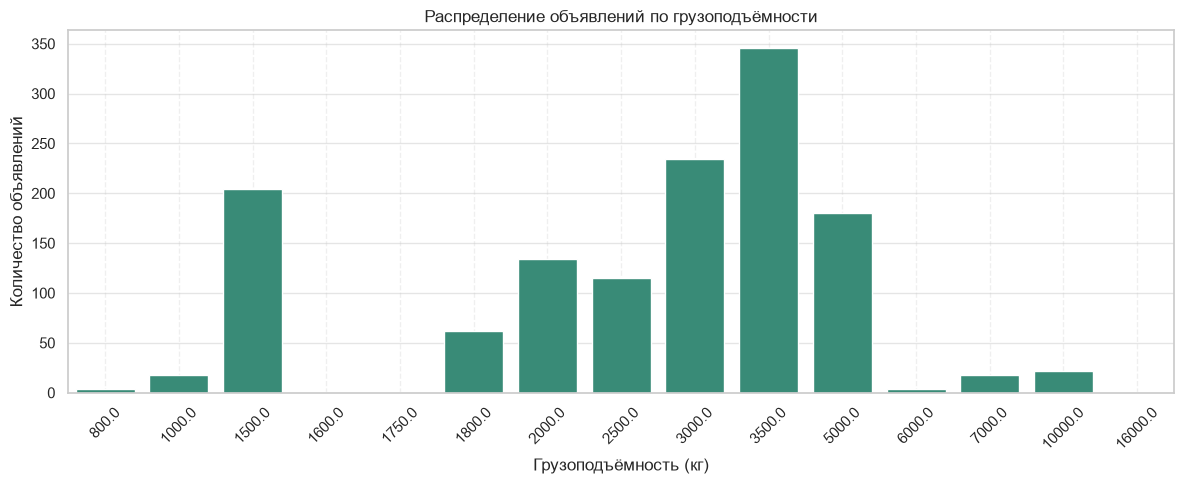

In [141]:
# построим визуализацию

# считаем количество объявлений для каждого значения грузоподъёмности
sns.set_theme(style="whitegrid")

capacity_counts = (
    df_fe['Грузоподъемность_кг'].value_counts().sort_index()
)

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# строим распределение по фактическим значениям
sns.barplot(
    x=capacity_counts.index,
    y=capacity_counts.values,
    ax=axes,
    color='#2b997e'
)

axes.set_title('Распределение объявлений по грузоподъёмности')
axes.set_xlabel('Грузоподъёмность (кг)')
axes.set_ylabel('Количество объявлений')
axes.grid(axis='x', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Распределение грузоподъёмности в основной массе сосредоточено в диапазоне примерно от 1 до 5 тонн, наибольшая концентрация предложения приходится на 3–3,5 тонны.

In [142]:
# считаем количество объявлений и долю предложения
capacity_share = (
    df_fe['Грузоподъемность_кг'].value_counts().sort_index()
    .rename('Количество объявлений').to_frame()
)

capacity_share['Доля предложения, %'] = (
    capacity_share['Количество объявлений'] / len(df_fe) * 100
)

print('Распределение предложения по грузоподъёмности:')
print(capacity_share)

Распределение предложения по грузоподъёмности:
                     Количество объявлений  Доля предложения, %
Грузоподъемность_кг                                            
800.00                                   4                 0.30
1000.00                                 18                 1.34
1500.00                                204                15.18
1600.00                                  1                 0.07
1750.00                                  1                 0.07
1800.00                                 62                 4.61
2000.00                                134                 9.97
2500.00                                115                 8.56
3000.00                                234                17.41
3500.00                                346                25.74
5000.00                                180                13.39
6000.00                                  4                 0.30
7000.00                                 18               

Рынок характеризуется несколькими ярко выраженными стандартными типоразмерами, а не равномерным распределением грузоподъёмности. <br>
Наибольшая концентрация предложения приходится на погрузчики грузоподъёмностью 3,5 т (25,74%), 3 т (17,41%), 1,5 т (15,18%) и 5 т (13,39%).

In [143]:
# считаем долю объявлений в основном рыночном диапазоне 1500–5000 кг
main_capacity = df_fe[df_fe['Грузоподъемность_кг'].between(1500, 5000)]

main_capacity_share = (len(main_capacity)/len(df_fe)* 100)

print(
    f'Доля объявлений с грузоподъёмностью '
    f'1500–5000 кг: {main_capacity_share:.2f}%'
)

Доля объявлений с грузоподъёмностью 1500–5000 кг: 95.01%


Распределение грузоподъёмности в выборке неравномерное и сосредоточено в нескольких стандартных типоразмерах. Из ген.совокупности 95,01% объявлений <br>находятся
в диапазоне 1,5–5 тонн. Наиболее представлены погрузчики грузоподъёмностью 3,5 т (25,74%), 3 т (17,41%), 1,5 т (15,18%) и 5 т (13,39%).

In [144]:
# отбираем основной рыночный диапазон грузоподъёмности
df_capacity_main = df_fe[
    df_fe['Грузоподъемность_кг'].between(1500, 5000)
].copy()

# считаем количество объявлений и медианную цену
capacity_price = (
    df_capacity_main
    .groupby('Грузоподъемность_кг')
    .agg(
        количество_объявлений=('Цена', 'size'),
        медианная_цена=('Цена', 'median')
    )
    .sort_index()
)

# добавляем долю каждого типоразмера в основном диапазоне
capacity_price['доля_в_основном_диапазоне_%'] = (
    capacity_price['количество_объявлений'] / len(df_capacity_main) * 100
)

print('Цена и предложение по грузоподъёмности:')
print(capacity_price)

Цена и предложение по грузоподъёмности:
                     количество_объявлений  медианная_цена  доля_в_основном_диапазоне_%
Грузоподъемность_кг                                                                    
1500.00                                204      1280000.00                        15.97
1600.00                                  1      1900000.00                         0.08
1750.00                                  1      1631750.00                         0.08
1800.00                                 62      1226000.00                         4.86
2000.00                                134      1396424.00                        10.49
2500.00                                115      1443761.00                         9.01
3000.00                                234      1463200.00                        18.32
3500.00                                346      1950000.00                        27.09
5000.00                                180      3150000.00                      

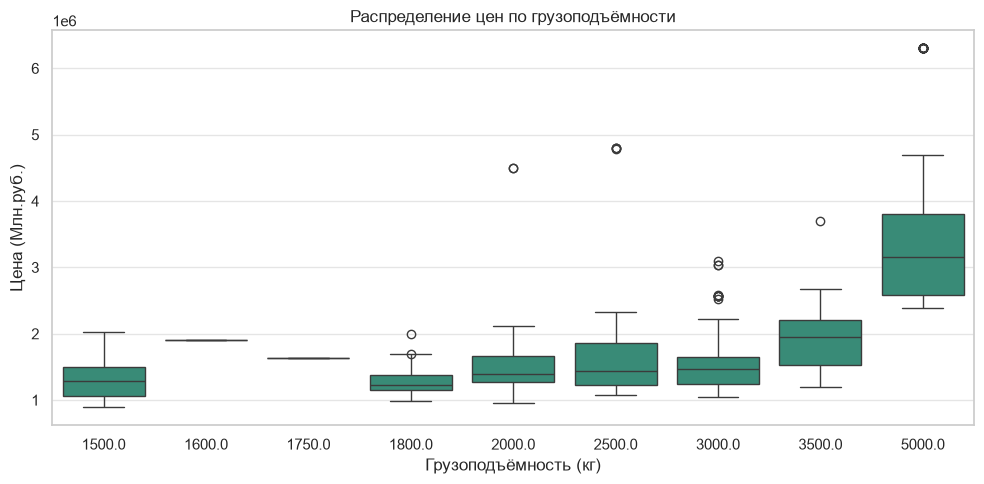

In [145]:
# оставляем основной диапазон грузоподъёмности
df_capacity_main = df_fe[
    df_fe['Грузоподъемность_кг'].between(1500, 5000)
].copy()

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# boxplot цены по фактическим значениям грузоподъёмности
sns.boxplot(
    data=df_capacity_main,
    x='Грузоподъемность_кг',
    y='Цена',
    ax=axes,
    color='#2b997e'
)

axes.set_title('Распределение цен по грузоподъёмности')
axes.set_xlabel('Грузоподъёмность (кг)')
axes.set_ylabel('Цена (Млн.руб.)')

plt.tight_layout()
plt.show()

Грузоподъёмность является одним из факторов, связанных с ценой, однако внутри одного типоразмера наблюдается значительный разброс стоимости.<br>
 Следовательно, различия в цене дополнительно связаны с другими техническими, коммерческими и географическими характеристиками техники.

In [146]:
# выбираем числовые признаки для первичного анализа
numeric_columns = [
    'Цена',
    'Год выпуска',
    'Мощность_кВт',
    'Грузоподъемность_кг',
    'Высота_выгрузки_мм',
    'Масса_кг',
    'serv_warranty_months',
    'serv_warranty_hours'
]

# считаем корреляции Spearman
correlation_matrix = (
    df_fe[numeric_columns].corr(method='spearman')
)

print('Корреляция Spearman:')
print(correlation_matrix['Цена'].sort_values(ascending=False))

Корреляция Spearman:
Цена                    1.00
Масса_кг                0.74
Грузоподъемность_кг     0.73
Мощность_кВт            0.41
Высота_выгрузки_мм      0.36
Год выпуска             0.33
serv_warranty_months   -0.18
serv_warranty_hours    -0.28
Name: Цена, dtype: float64


In [147]:
# считаем корреляцию Pearson для сравнения
pearson_correlation = (
    df_fe[numeric_columns].corr(method='pearson')
)

print('Корреляция Pearson с ценой:')
print(pearson_correlation['Цена'].sort_values(ascending=False))

Корреляция Pearson с ценой:
Цена                    1.00
Масса_кг                0.86
Грузоподъемность_кг     0.80
Мощность_кВт            0.72
Высота_выгрузки_мм      0.30
Год выпуска             0.26
serv_warranty_months   -0.31
serv_warranty_hours    -0.41
Name: Цена, dtype: float64


####
<div class="alert alert-success">
    <b> небольшой итог по 4.1.1:</b><br>

- Распределение грузоподъёмности в выборке неравномерное и сосредоточено вокруг нескольких стандартных типоразмеров. Основной диапазон рынка — 1,5–5 тонн: <br>на него приходится 95,01% всех объявлений.

- Наиболее представлены погрузчики грузоподъёмностью 3,5 т (25,74%), 3 т (17,41%), 1,5 т (15,18%) и 5 т (13,39%). Только эти четыре типоразмера формируют<br> 71,72% всего предложения.

- Анализ цен показывает, что с увеличением грузоподъёмности цена в целом повышается, однако зависимость не является линейной. Особенно заметны ценовые <br>уровни для 3,5 и 5 тонн. При этом внутри одного типоразмера наблюдается значительный разброс цен, поэтому одной грузоподъёмностью стоимость техники<br> не объясняется.

<b> Вывод:</b><br>
- для дальнейшего анализа целесообразно сосредоточиться на диапазоне 1,5–5 тонн, а грузоподъёмность рассматривать как один из факторов<br> цены, а не как единственное объяснение её различий.
- Также мы наблюдаем отчетливый Шаг рынка — 0.5 тонны, что подтверждается наличием стандартных типоразмеров: 1.5, 2.0, 2.5, 3.0, 3.5, 5.0 тонн, а также<br> нашим распределением по количеству объявлений на грузоподъемность
- Наиболее сбалансированный сегмент с точки зрения выбора для покупателя — 3.5 тонны (максимальное предложение и широкий диапазон цен). Это указывает<br> на высокую конкуренцию и наличие как бюджетных, так и премиальных предложений

<b> Также нужно интерпритировать результаты корреляции Массы и цены (выше)</b><br>
- Масса техники демонстрирует наиболее сильную парную связь с ценой среди рассмотренных числовых признаков (Pearson = 0,86; Spearman = 0,74).<br> Однако эту связь нельзя интерпретировать как самостоятельную ценовую премию за массу. Вероятно, высокая корреляция частично отражает различия в размере и классе техники: более тяжёлые погрузчики одновременно обладают большей массой, грузоподъёмностью и мощностью. Анализ однородной серии объявлений<br>  показывает, что цена может различаться даже при одинаковой массе, поэтому влияние массы необходимо оценивать в сочетании с другими характеристиками<br> и при прочих равных.

- Также в анализе корреляции мы добавили численный признак "гарантии" в м/ч и месяцах (добавлены просто для сравнения), что дали отрицательное показание<br> корреляции. Что довольно странно, поэтому нужно проверить влияние гарантии на цену более детально. Может быть место аномалии.

</div>

#### 4.1.2 'Высота_выгрузки_мм'

In [148]:
# рассмотрим распределение количества объявлений по высоте
print('распределение объявлений по "Высота_выгрузки_мм":')
print(df_fe['Высота_выгрузки_мм'].value_counts())

# смотрим количество уникальных значений
print(f'\nКоличество уникальных значений: '
      f'{df_fe["Высота_выгрузки_мм"].nunique()}')

распределение объявлений по "Высота_выгрузки_мм":
Высота_выгрузки_мм
3000.00    1016
4500.00     149
5000.00      85
4800.00      63
6500.00      16
4700.00       7
3300.00       5
2000.00       1
3500.00       1
6000.00       1
Name: count, dtype: int64

Количество уникальных значений: 10


In [149]:
# отбираем основной рыночный диапазон Высота выгрузки
df_height = df_fe[
    df_fe['Высота_выгрузки_мм'].notna()
].copy()

# считаем количество объявлений и медианную цену
height_stats = (
    df_height
    .groupby('Высота_выгрузки_мм')
    .agg(
        количество_объявлений=('Цена', 'size'),
        медианная_цена=('Цена', 'median')
    )
    .sort_index()
)

# добавляем долю каждого типоразмера в основном диапазоне
height_stats['доля %'] = (
    height_stats['количество_объявлений'] / len(df_height) * 100
)

print('Цена и предложение по высоте выгрузки:')
print(height_stats)

Цена и предложение по высоте выгрузки:
                    количество_объявлений  медианная_цена  доля %
Высота_выгрузки_мм                                               
2000.00                                 1       480000.00    0.07
3000.00                              1016      1465000.00   75.60
3300.00                                 5      1830000.00    0.37
3500.00                                 1     10699000.00    0.07
4500.00                               149      1589000.00   11.09
4700.00                                 7      4790000.00    0.52
4800.00                                63      2390000.00    4.69
5000.00                                85      3150000.00    6.32
6000.00                                 1      1040000.00    0.07
6500.00                                16      1998000.00    1.19


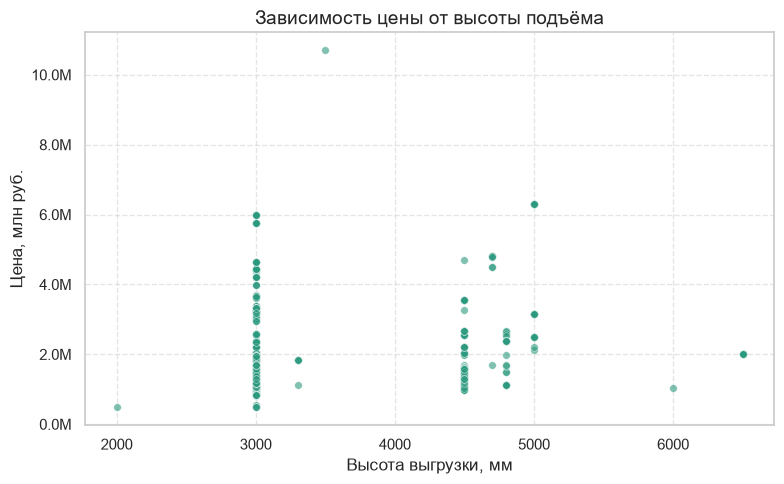

In [150]:
# Настройка стиля
sns.set_theme(style="whitegrid")

# 1. Построение scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_fe,
    x='Высота_выгрузки_мм',
    y='Цена',
    alpha=0.6,
    s=30,
    color='#2b997e'
)

# 2. Настройка подписей и заголовка
plt.title('Зависимость цены от высоты подъёма', fontsize=14)
plt.xlabel('Высота выгрузки, мм')
plt.ylabel('Цена, млн руб.')

# 3. Форматирование оси Y в миллионах
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Для детального анализа рассмотрим сегмент грузоподъемностью 3.5 тонн (чтобы ориентироваться на основную часть рынка 3500 кг грузоподъемности это ~75% рынка

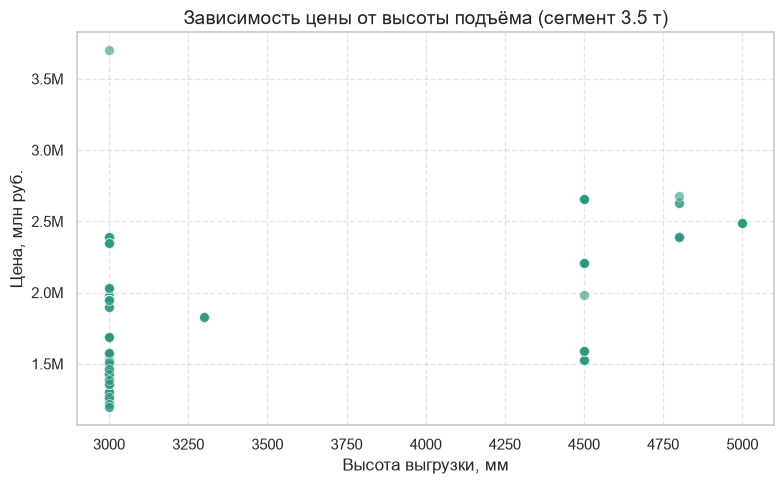

In [151]:
# Настройка стиля
sns.set_theme(style="whitegrid")

# Фильтруем данные только для сегмента 3.5 тонны
df_35 = df_fe[df_fe['Грузоподъемность_кг'] == 3500]

# 1. Построение scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_35,
    x='Высота_выгрузки_мм',
    y='Цена',
    alpha=0.6,
    s=50,
    color='#2b997e'
)

# 2. Настройка подписей и заголовка
plt.title('Зависимость цены от высоты подъёма (сегмент 3.5 т)', fontsize=14)
plt.xlabel('Высота выгрузки, мм')
plt.ylabel('Цена, млн руб.')

# 3. Форматирование оси Y в миллионах
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [152]:
# df_height_corr = df_fe.copy()
#
# df_height_corr35 = df_fe[df_fe['Высота_выгрузки_мм']['Грузоподъемность_кг'] == 3500].copy()
#
# corr_spearman_m = {
#     'Высота_выгрузки_мм': stats.spearmanr(df_height_corr35['Высота_выгрузки_мм'], df_height_corr35['Цена'])[0]
# }
#
# corr_spearman_g = {
#     'Высота_выгрузки_мм': stats.spearmanr(df_height_corr['Высота_выгрузки_мм'], df_height_corr['Цена'])[0]
# }
#
# corr_spearman_m = {
#     'Высота_выгрузки_мм': stats.spearmanr(df_height_corr35['Высота_выгрузки_мм'], df_height_corr35['Цена'])[0]
# }
#
# corr_spearman_g = {
#     'Высота_выгрузки_мм': stats.spearmanr(df_height_corr['Высота_выгрузки_мм'], df_height_corr['Цена'])[0]
# }

####
<div class="alert alert-success">
    <b> небольшой итог по 4.1.2:</b><br>

- Стандартная высота для большинства погрузчиков — 3000 мм (75.6% предложения).
- Более высокие мачты (4500–5000 мм) встречаются в 11–6% объявлений и связаны с более высокой ценой, но не линейно.
- На графиках видно, что высота сама по себе не определяет цену — внутри каждой высоты есть широкий разброс, что указывает на влияние других факторов (бренд, год, комплектация).

<b> Вывод:</b><br>

- Мы подтвердили сегментацию рынка. Наглядно увидели, что для грузоподъемности 3.5 тонн чуть ли не стандартом высоты выгрузки является - 3000 мм и меньшая доля это высота выгрузки в диапазоне от 4500 мм до 5000 мм. Это может послужить данными для выбора основной линейки параметров выпускаемой продукции

</div>

#### 4.1.3. 'Мощность_кВт' и 'Масса_кг'



рассмотрим мощность и массу погрузчика вместе. тк эти два признака взаимосвязаны.
- "чем больше масса погрузчика, тем большую мощность должен иметь двигатель, чтобы приводить его в движение" (чем больше грузоподъемность, тем больше нужен противовес=масса)

In [153]:
# основные стат показатели
print(df_fe[['Мощность_кВт', 'Масса_кг']].describe())

       Мощность_кВт  Масса_кг
count       1344.00   1344.00
mean          37.62   4547.91
std           15.23   2124.31
min            2.00    900.00
25%           34.00   3350.00
50%           37.00   4250.00
75%           39.25   4810.00
max          129.00  25000.00


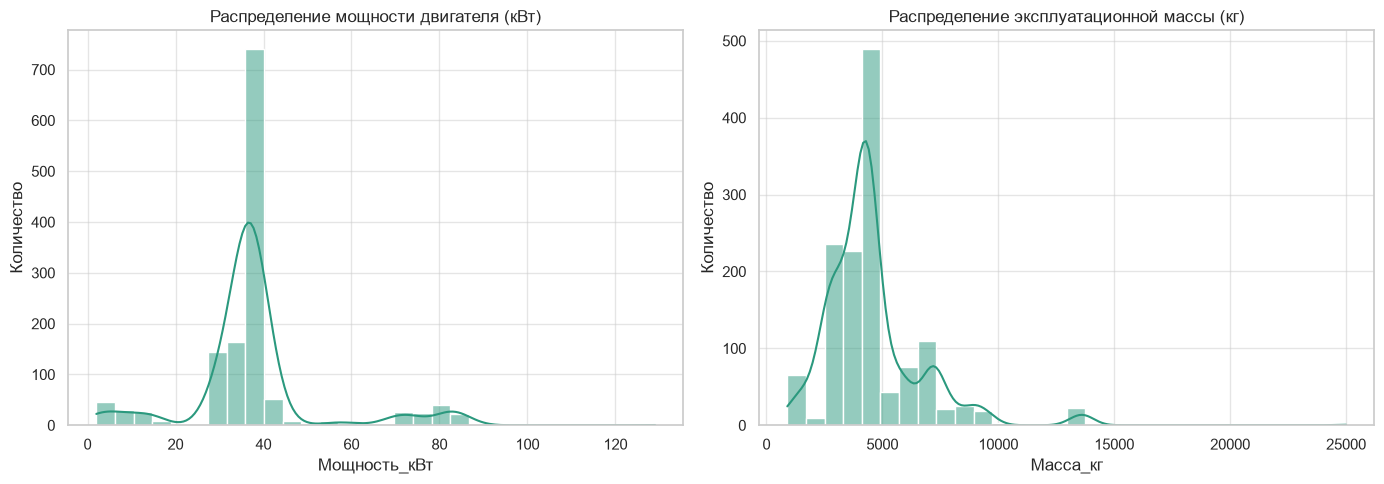

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.set_theme(style="whitegrid")


# Гистограмма для мощности
sns.histplot(
    df_fe['Мощность_кВт'],
    bins=30,
    kde=True,
    ax=axes[0],
    color='#2b997e'
)

axes[0].set_title('Распределение мощности двигателя (кВт)')
axes[0].set_ylabel('Количество')


# Гистограмма для массы
sns.histplot(
    df_fe['Масса_кг'],
    bins=30,
    kde=True,
    ax=axes[1],
    color='#2b997e'
)

axes[1].set_title('Распределение эксплуатационной массы (кг)')
axes[1].set_ylabel('Количество')


plt.tight_layout()
plt.show()

1. гистограмма на 3 группы(кластера): 1 - маломощные (2 - 18 кВт), 2 - среднемощные (25 - 42 кВт) {самая большая группа, самая большая частота 38-40}, 3 - высокомощные (70 - 85 кВт). Между группами(кластерами) видно, что есть пропуски, нужно это подтвердить.
2. гистограмма выглядит как правосторонее распределение, с пиком в диапозоне от 3000 кг до 5000.

In [155]:
# ============================================================
# ШАГ 1. Автоматический поиск "пустых" интервалов (разрывов)
# ============================================================
# Идея: строим гистограмму с МЕЛКИМ шагом (много бинов), и смотрим,
# в каких интервалах частота = 0 (или почти 0). Это и есть визуальные
# "пустоты" между вашими тремя группами по мощности.
def find_gaps(series, n_bins=60, min_gap_width=1):
    """
    series       - столбец с данными (например df_fe['Мощность_кВт'])
    n_bins       - на сколько мелких интервалов бить диапазон
    min_gap_width- сколько подряд идущих пустых бинов считать "настоящим" разрывом
                   (чтобы не ловить случайные единичные пустые ячейки)

    Возвращает список кортежей (start, end) - границы пустых зон.
    """
    clean = series.dropna()
    counts, bin_edges = np.histogram(clean, bins=n_bins)
    # counts[i]   - сколько значений попало в i-й интервал
    # bin_edges   - границы интервалов, их всегда на 1 больше, чем counts

    gaps = []
    i = 0
    while i < len(counts):
        if counts[i] == 0:
            start = bin_edges[i]
            j = i
            while j < len(counts) and counts[j] == 0:
                j += 1
            end = bin_edges[j]
            if (j - i) >= min_gap_width:
                gaps.append((start, end))
            i = j
        else:
            i += 1
    return gaps


# ============================================================
# ШАГ 2. Разбивка на группы (кластеры) по заданным границам
# ============================================================
# Границы ниже заданы по вашему визуальному наблюдению
# (2-18 / 25-42 / 70-85). Если find_gaps() покажет другие границы
# на ваших реальных данных - просто подставьте их сюда вместо ручных.
def summarize_groups(series, bins, labels):
    """
    pd.cut() режет числовой столбец на интервалы (bins) и присваивает
    каждому значению метку (label) того интервала, куда оно попало.
    bins должно быть на 1 элемент длиннее labels.
    """
    groups = pd.cut(series, bins=bins, labels=labels)

    counts = groups.value_counts().reindex(labels)          # абсолютные частоты
    shares = groups.value_counts(normalize=True).reindex(labels) * 100  # доли в %

    summary = pd.DataFrame({
        'count': counts,
        'share_%': shares.round(1)
    })

    # describe() по каждой группе отдельно: mean, std, min, max, квартили
    stats_by_group = series.groupby(groups, observed=True).describe()

    return summary, stats_by_group


# ============================================================
# ШАГ 3. Считаем всё для мощности и массы
# ============================================================
power = df_fe['Мощность_кВт']
mass = df_fe['Масса_кг']

# --- Мощность: 3 группы по вашим наблюдениям ---
power_bins = [0, 18, 42, 130]
power_labels = ['2-18 кВт', '25-42 кВт', '70-85 кВт']
power_summary, power_stats = summarize_groups(power, power_bins, power_labels)

print("=== Мощность: сводка по группам ===")
print(power_summary)
print("\n=== Мощность: статистика внутри групп ===")
print(power_stats)

power_gaps = find_gaps(power, n_bins=60, min_gap_width=2)
print("\n=== Мощность: найденные пустые интервалы (разрывы) ===")
print(power_gaps)


=== Мощность: сводка по группам ===
              count  share_%
Мощность_кВт                
2-18 кВт        112     8.30
25-42 кВт      1099    81.80
70-85 кВт       133     9.90

=== Мощность: статистика внутри групп ===
               count  mean   std   min   25%   50%   75%    max
Мощность_кВт                                                   
2-18 кВт      112.00  8.21  4.85  2.00  4.00  8.00 14.00  16.00
25-42 кВт    1099.00 36.16  3.08 30.00 35.00 37.00 37.00  42.00
70-85 кВт     133.00 74.48 11.88 45.00 70.00 74.00 82.00 129.00

=== Мощность: найденные пустые интервалы (разрывы) ===
[(np.float64(16.816666666666666), np.float64(29.516666666666666)), (np.float64(46.45), np.float64(54.916666666666664)), (np.float64(61.266666666666666), np.float64(69.73333333333333)), (np.float64(76.08333333333333), np.float64(80.31666666666666)), (np.float64(86.66666666666667), np.float64(126.88333333333334))]


Вывод по распределению мощности и массы:

Мощность двигателя имеет дискретную структуру, состоящую из трёх ярко выраженных кластеров:

Маломощный (2–18 кВт) — 8.3% рынка (электропогрузчики и лёгкая техника).

Основной (25–42 кВт) — 81.8% рынка (ядро, 2.5–3.5 т). Пик приходится на 37 кВт.

Мощный (70–85+ кВт) — 9.9% рынка (тяжёлая техника 5+ т).

Между кластерами присутствуют разрывы, что указывает на дискретность предложения и отсутствие промежуточных вариантов.

Масса техники имеет правостороннее распределение:

Основная масса (75% данных) сосредоточена в диапазоне 3350–4810 кг.

Длинный правый хвост (тяжёлые машины) подтверждает структуру, аналогичную грузоподъёмности.

Общий вывод: как мощность, так и масса являются прокси-признаками грузоподъёмности и демонстрируют ту же дискретную структуру. Это означает, что они, скорее всего, не добавят новой информации в модель сверх грузоподъёмности, но их можно использовать для кросс-проверки сегментов (например, для выявления аномалий).

Нужно посмотреть как эти параметры будут относится к цене внутри самой большой группе рынка в грузоподъемности

In [156]:
# 1. Данные
df_gen = df_fe.copy()
print(f'Объявлений в ГЕНСОВОКУПНОСТИ: {len(df_gen)}\n')

df_35 = df_fe[df_fe['Грузоподъемность_кг'] == 3500].copy()
print(f'Объявлений в сегменте 3.5т: {len(df_35)}\n')

# 2. Рассчитываем корреляции (правильно!)
corr_spearman = {
    'Мощность_кВт': stats.spearmanr(df_35['Мощность_кВт'], df_35['Цена'])[0],
    'Масса_кг':     stats.spearmanr(df_35['Масса_кг'], df_35['Цена'])[0],
    'Мощность_ГЕН': stats.spearmanr(df_gen['Мощность_кВт'], df_gen['Цена'])[0],
    'Масса_ГЕН':    stats.spearmanr(df_gen['Масса_кг'], df_gen['Цена'])[0]
}

# ВНИМАНИЕ: здесь теперь ПИРСОН, а не Спирмен!
corr_pearson = {
    'Мощность_кВт': stats.pearsonr(df_35['Мощность_кВт'], df_35['Цена'])[0],
    'Масса_кг':     stats.pearsonr(df_35['Масса_кг'], df_35['Цена'])[0],
    'Мощность_ГЕН': stats.pearsonr(df_gen['Мощность_кВт'], df_gen['Цена'])[0],
    'Масса_ГЕН':    stats.pearsonr(df_gen['Масса_кг'], df_gen['Цена'])[0]
}

# 3. Собираем DataFrame
df_corr = pd.DataFrame({
    'Spearman': corr_spearman,
    'Pearson': corr_pearson
})

print('Корреляция с ценой (в Генсовокупности и внутри сегмента 3.5т):')
df_corr.round(3)

Объявлений в ГЕНСОВОКУПНОСТИ: 1344

Объявлений в сегменте 3.5т: 346

Корреляция с ценой (в Генсовокупности и внутри сегмента 3.5т):


,Spearman,Pearson
Мощность_кВт,-0.12,-0.17
Масса_кг,0.24,0.62
Мощность_ГЕН,0.41,0.72
Масса_ГЕН,0.74,0.86


In [157]:
# Сравниваем с корреляцией грузоподъёмности (для контекста)
corr_capacity = stats.pearsonr(df_fe['Грузоподъемность_кг'], df_fe['Цена'])[0]
print(f'\nДля справки: корреляция грузоподъёмности с ценой (по всем данным) = {corr_capacity:.3f}')


Для справки: корреляция грузоподъёмности с ценой (по всем данным) = 0.795


<b>Первичная корреляция (предварительный взгляд)</b>

-Посчитали Spearman и Pearson между ценой и (мощностью/массой) внутри сегмента 3.5т и по всей выборке.

    Результаты:

    Признак	        Spearman (внутри 3.5т)	Pearson (внутри 3.5т)	    Spearman (все)	    Pearson (все)
    Мощность_кВт	      -0.12	               -0.17	                        0.41	        0.72
    Масса_кг	        0.24	                0.62	                        0.74	        0.86
    Вывод:

На всех данных связь сильная (особенно Пирсон), но она объясняется различиями между классами грузоподъёмности.

Внутри сегмента 3.5т картина неоднозначная: мощность показывает отрицательную корреляцию, масса показывает сильный Пирсон (0.62) при слабом Спирмене (0.24). Это указывает на возможное влияние выбросов или нелинейность.


=== Анализ признака: Мощность_кВт ===
Q1 = 36.0, Q3 = 37.0, IQR = 1.0
Границы: нижняя = 34.5, верхняя = 38.5
Корреляция (все): Spearman = -0.117, Pearson = -0.171
Корреляция (без выбросов): Spearman = 0.361, Pearson = 0.348


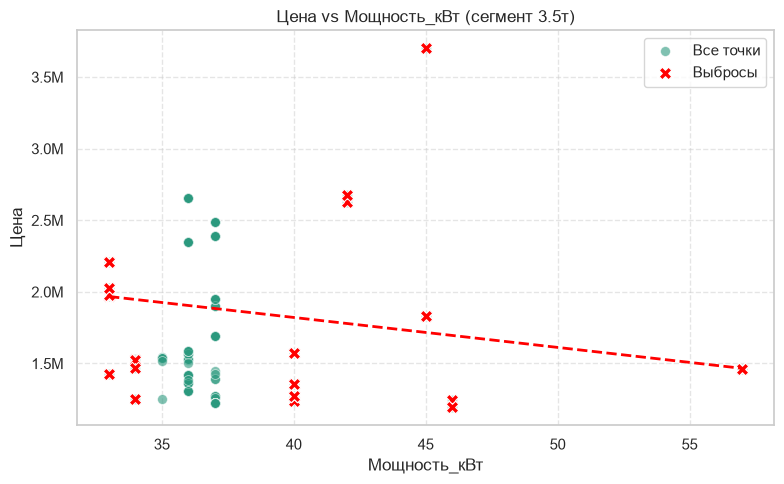


=== Анализ признака: Масса_кг ===
Q1 = 4400.0, Q3 = 5300.0, IQR = 900.0
Границы: нижняя = 3050.0, верхняя = 6650.0
Корреляция (все): Spearman = 0.240, Pearson = 0.620
Корреляция (без выбросов): Spearman = 0.240, Pearson = 0.620


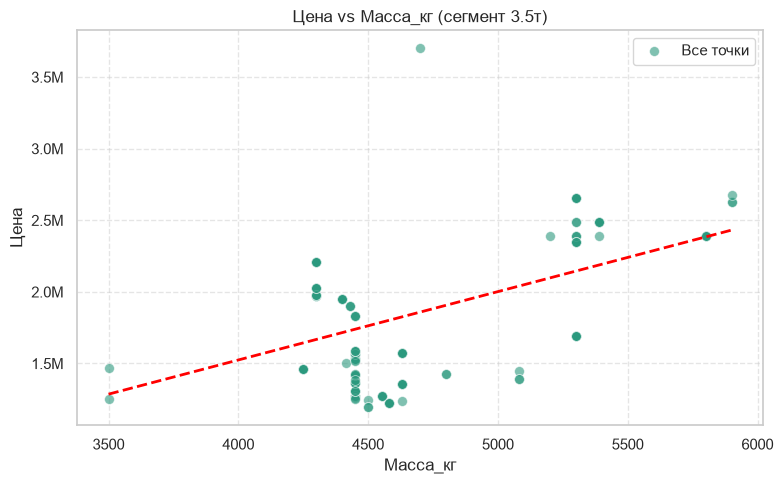


=== Итоговая таблица корреляций ===
     Признак  Кол-во выбросов  Pearson (все)  Pearson (без выбр.)  Spearman (все)  Spearman (без выбр.)
Мощность_кВт               86          -0.17                 0.35           -0.12                  0.36
    Масса_кг                0           0.62                 0.62            0.24                  0.24


In [158]:
# 1. Выделяем сегмент 3.5т
df_35 = df_fe[df_fe['Грузоподъемность_кг'] == 3500].copy()

# Форматтер оси Y
formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# Создаём словарь для хранения результатов
results = {}

# 2. Проверяем оба признака
for feature in ['Мощность_кВт', 'Масса_кг']:
    print(f'\n=== Анализ признака: {feature} ===')

    # 2.1 Выбросы по IQR
    Q1 = df_35[feature].quantile(0.25)
    Q3 = df_35[feature].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    print(f'Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}')
    print(f'Границы: нижняя = {lower_bound:.1f}, верхняя = {upper_bound:.1f}')

    # 2.2 Выделяем чистые данные (без выбросов)
    df_clean = df_35[(df_35[feature] >= lower_bound) & (df_35[feature] <= upper_bound)]

    # 2.3 Считаем корреляции
    corr_all_spearman = stats.spearmanr(df_35[feature], df_35['Цена'])[0]
    corr_all_pearson = stats.pearsonr(df_35[feature], df_35['Цена'])[0]
    corr_clean_spearman = stats.spearmanr(df_clean[feature], df_clean['Цена'])[0]
    corr_clean_pearson = stats.pearsonr(df_clean[feature], df_clean['Цена'])[0]

    print(f'Корреляция (все): Spearman = {corr_all_spearman:.3f}, Pearson = {corr_all_pearson:.3f}')
    print(f'Корреляция (без выбросов): Spearman = {corr_clean_spearman:.3f}, Pearson = {corr_clean_pearson:.3f}')

    # Сохраняем для таблицы
    results[feature] = {
        'all_pearson': corr_all_pearson,
        'clean_pearson': corr_clean_pearson,
        'all_spearman': corr_all_spearman,
        'clean_spearman': corr_clean_spearman,
        'outliers_count': len(df_35) - len(df_clean)
    }

    # 2.4 Строим scatter plot с подсветкой выбросов
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Все точки
    sns.scatterplot(
        data=df_35,
        x=feature,
        y='Цена',
        ax=ax,
        alpha=0.6,
        s=50,
        color='#2b997e',
        label='Все точки'
    )

    # Линия тренда для всех точек
    sns.regplot(
        data=df_35,
        x=feature,
        y='Цена',
        scatter=False,
        ax=ax,
        color='red',
        ci=None,
        line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Тренд (все)'}
    )

    # Подсвечиваем выбросы
    outliers = df_35[(df_35[feature] < lower_bound) | (df_35[feature] > upper_bound)]
    if not outliers.empty:
        sns.scatterplot(
            data=outliers,
            x=feature,
            y='Цена',
            ax=ax,
            color='red',
            s=80,
            marker='X',
            label='Выбросы'
        )

    ax.set_title(f'Цена vs {feature} (сегмент 3.5т)', fontsize=12)
    ax.set_xlabel(f'{feature}')
    ax.yaxis.set_major_formatter(formatter)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 3. Итоговая таблица
print('\n=== Итоговая таблица корреляций ===')
df_results = pd.DataFrame({
    'Признак': results.keys(),
    'Кол-во выбросов': [r['outliers_count'] for r in results.values()],
    'Pearson (все)': [r['all_pearson'] for r in results.values()],
    'Pearson (без выбр.)': [r['clean_pearson'] for r in results.values()],
    'Spearman (все)': [r['all_spearman'] for r in results.values()],
    'Spearman (без выбр.)': [r['clean_spearman'] for r in results.values()]
})
print(df_results.round(3).to_string(index=False))

По итогам анализа графиков и корреляции с выбросами и без. Мы видим что значения корреляции изменились, и уже прослеживается положительная динамика. Для дальнейшего понимания ситуации нужно рассмотреть сами выбросы по мощности

In [159]:
# Выделяем выбросы по мощности
power_outliers = df_35[(df_35['Мощность_кВт'] < 34.5) | (df_35['Мощность_кВт'] > 38.5)]

print(f'Количество выбросов по мощности: {len(power_outliers)}')
print(f'Доля от сегмента 3.5т: {len(power_outliers) / len(df_35) * 100:.1f}%')

# Смотрим, какие это машины
print('\n=== Выбросы по мощности: первые 10 строк ===')
print(power_outliers[['Марка', 'Модель', 'Мощность_кВт', 'Цена', 'Год выпуска']].head(10))

# Сравниваем с основным массивом
power_main = df_35[(df_35['Мощность_кВт'] >= 34.5) & (df_35['Мощность_кВт'] <= 38.5)]
print(f'\nОсновной массив (260 машин): средняя цена = {power_main["Цена"].mean():,.0f} руб.')
print(f'Выбросы (86 машин): средняя цена = {power_outliers["Цена"].mean():,.0f} руб.')

Количество выбросов по мощности: 86
Доля от сегмента 3.5т: 24.9%

=== Выбросы по мощности: первые 10 строк ===
        Марка  Модель  Мощность_кВт     Цена  Год выпуска
58    Hangcha  CPCD35         40.00  1270000         2026
64   Cargador  CPCD35         45.00  1830000         2026
65   Cargador  CPCD35         45.00  1830000         2026
66    Hangcha  CPCD35         40.00  1270000         2026
78    Laigong   LG35F         33.00  1970000         2025
94    Laigong   LG35F         33.00  1970000         2025
115   Liugong  CPCD35         40.00  1573936         2025
140   Laigong   LG35F         33.00  1970000         2025
145   Laigong   LG35F         33.00  1970000         2025
153   Laigong   LG35F         33.00  1970000         2025

Основной массив (260 машин): средняя цена = 1,930,774 руб.
Выбросы (86 машин): средняя цена = 1,721,179 руб.


In [160]:
# 1. Находим выбросы по цене в сегменте 3.5т (по IQR)
Q1_price = df_35['Цена'].quantile(0.25)
Q3_price = df_35['Цена'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df_35[(df_35['Цена'] < lower_price) | (df_35['Цена'] > upper_price)]
print(f'Выбросы по цене: {len(price_outliers)} машин')

# 2. Пересечение с выбросами по мощности
power_outliers_indices = set(power_outliers.index)
price_outliers_indices = set(price_outliers.index)
intersection = power_outliers_indices & price_outliers_indices

print(f'Пересечение выбросов по мощности и цене: {len(intersection)} машин')

# 3. Смотрим, какие это машины
df_intersection = df_35.loc[list(intersection)]
print('\n=== Пересечение (первые 10 строк) ===')
print(df_intersection[['Марка', 'Модель', 'Мощность_кВт', 'Цена', 'Год выпуска']].head(10))

Выбросы по цене: 1 машин
Пересечение выбросов по мощности и цене: 1 машин

=== Пересечение (первые 10 строк) ===
    Марка  Модель  Мощность_кВт     Цена  Год выпуска
851   Chl  CPCD35         45.00  3700000         2025


####
<div class="alert alert-success">
<b>Итог 4.1.3</b>

Внутри сегмента 3.5 тонны "масса" не имеет значимого влияния на цену. Spearman = 0.24 – связь слабая. Pearson = 0.62 – выше, но это не подкрепляется монотонностью и не объясняется выбросами. Это артефакт, связанный с другими факторами.

- Решение: массу исключить из модели ценообразования.

Внутри сегмента 3.5 тонны мощность имеет неоднородное влияние. В основной массе (260 машин, 75% сегмента) мощность положительно коррелирует с ценой (Spearman ≈ 0.36). Оставшиеся 86 машин (25% сегмента) имеют либо аномально низкую (≤ 34.5 кВт), либо аномально высокую (≥ 38.5 кВт) мощность. Эти машины не являются ценовыми аномалиями, а представляют собой отдельные подгруппы (электропогрузчики, газовые, мощные дизели). Из-за этих 86 машин общая корреляция на всём сегменте становится слабой и отрицательной (-0.17).

- Решение: в рамках общей модели мы исключаем мощность, чтобы не создавать ложную линейную зависимость на всём рынке.

<b>Обоснование исключения массы и мощности (прокси-признаки):</b>

При фиксации грузоподъёмности на уровне 3.5 тонны, корреляция массы с ценой падает с глобальной 0.62 до 0.24, а мощность показывает разнонаправленное влияние.

Инженерно эти параметры являются следствиями расчета противовеса и двигателя под заданную грузоподъёмность, а не драйверами стоимости.

<b>Это доказывает, что рыночная цена реагирует на смену класса "грузоподъемности"(тоннажа), а не на вариации массы/мощности внутри класса. Чтобы избежать мультиколлинеарности и получить корректную оценку премии за тоннаж, данные признаки исключаются из финальной модели.</b>

</div>

#### 4.1.4. `Год_выпуска`

In [161]:
# проверим распределение по годам выпуска
df_fe['Год выпуска'].value_counts().sort_index()

Год выпуска
2023      6
2024    161
2025    675
2026    502
Name: count, dtype: int64

In [162]:
df_fe.groupby('Год выпуска')['Цена'].describe()

,count,mean,std,min,25%,50%,75%,max
Год выпуска,,,,,,,,
2023,6.00,2475833.33,1586210.63,1230000.00,1308750.00,1685000.00,3850000.00,4500000.00
2024,161.00,1347780.12,357426.54,795000.00,1120000.00,1275000.00,1523000.00,2321000.00
2025,675.00,1856098.22,993621.23,950000.00,1303000.00,1485000.00,1970000.00,5974000.00
2026,502.00,2284389.60,1266337.24,480000.00,1443761.00,1950000.00,2590000.00,10699000.00


In [163]:
# проверим меры центральной тенденции и стандартное отклонение, и долю рынка всех объявлений
df_fe.groupby('Год выпуска')['Цена'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    share= lambda x: len(x) / len(df_fe) * 100
)

,count,mean,median,std,share
Год выпуска,,,,,
2023,6,2475833.33,1685000.00,1586210.63,0.45
2024,161,1347780.12,1275000.00,357426.54,11.98
2025,675,1856098.22,1485000.00,993621.23,50.22
2026,502,2284389.60,1950000.00,1266337.24,37.35


Вероятно присутствует правосторонее распределение: ср.знач. > медианы;

In [164]:
# Посмотрим на часть признаков техники 2023 года выпуска
df_fe[df_fe['Год выпуска'] == 2023][['Цена', 'Год выпуска', 'Мощность_кВт', 'Грузоподъемность_кг']]

,Цена,Год выпуска,Мощность_кВт,Грузоподъемность_кг
180,1255000,2023,34.00,2000.00
296,4500000,2023,34.00,2000.00
300,4500000,2023,34.00,2000.00
481,1900000,2023,9.00,1600.00
961,1470000,2023,34.00,3500.00
1053,1230000,2023,32.00,1500.00


In [165]:
# здесь мы просмотрим отфильтрованные объявления
# df_fe[df_fe['Год выпуска'] == 2023]

Предлагаю исключить 2023 год из анализа признака, тк:
 1. имеется большого стандартного отклонения которое может исказить анализ.
 2. после просмотра конкретных объявлений №296 и 300 могут быть дубликатами объявлений одного продавца, что собственно повлияет на интерпритацию признака.
 3. малое количество 0,45% всего рынка


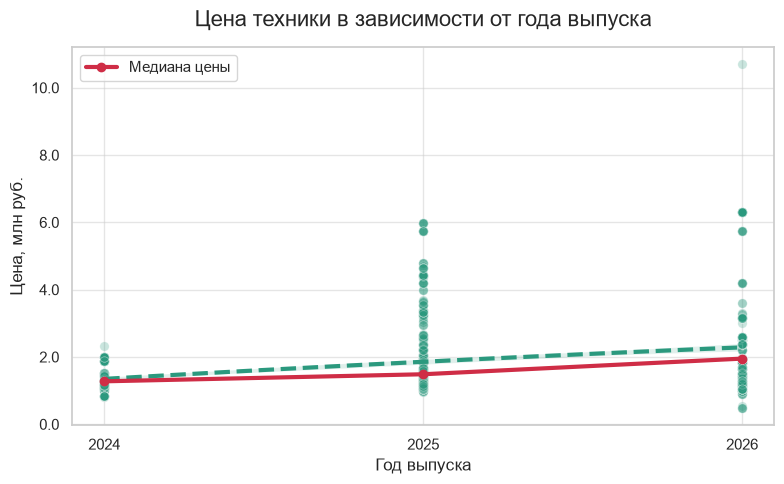

In [166]:
# построим диаграмму рассеивания

df_filtered = df_fe[df_fe['Год выпуска'].isin([2024, 2025, 2026])]

median_by_year = (
    df_filtered
    .groupby('Год выпуска')['Цена']
    .median()
    .reset_index()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Все объявления
sns.scatterplot(
    data=df_filtered,
    x='Год выпуска',
    y='Цена',
    alpha=0.25,
    s=45,
    color='#2b997e'
)

# Полиномиальный тренд
sns.regplot(
    data=df_filtered,
    x='Год выпуска',
    y='Цена',
    order=2,
    scatter=False,
    color='#2b997e',
    line_kws={
        'linewidth': 3,
        'linestyle': '--',
        'label': 'Полиномиальный тренд'
    }
)

# Медиана по каждому году
plt.plot(
    median_by_year['Год выпуска'],
    median_by_year['Цена'],
    marker='o',
    linewidth=3,
    color='#cf2d46',
    label='Медиана цены'
)

plt.title(
    'Цена техники в зависимости от года выпуска',
    fontsize=16,
    pad=15
)

plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Цена, млн руб.', fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.xticks([2024, 2025, 2026])
plt.legend()

plt.tight_layout()
plt.show()

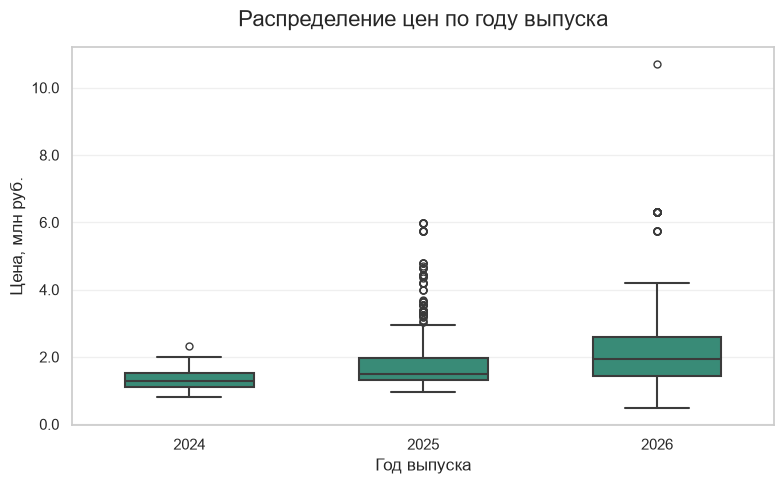

In [167]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_filtered,
    x='Год выпуска',
    y='Цена',
    color='#2b997e',
    width=0.55,
    showfliers=True,
    fliersize=5,
    linewidth=1.5
)

plt.title(
    'Распределение цен по году выпуска',
    fontsize=16,
    pad=15
)

plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Цена, млн руб.', fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

In [168]:
# Проверим характер связи по Спирмену (тк распределение не нормальное)
# По всем данным (2024-2026)
corr_all = df_filtered['Год выпуска'].corr(df_filtered['Цена'], method='spearman')
print(f'Spearman (все данные): {corr_all:.3f}')

# Внутри сегмента 3.5т (чтобы убрать влияние разных размеров машин)
df_35 = df_filtered[(df_filtered['Грузоподъемность_кг'] == 3500)]
corr_35 = df_35['Год выпуска'].corr(df_35['Цена'], method='spearman')
print(f'Spearman (сегмент 3.5т): {corr_35:.3f}')

Spearman (все данные): 0.339
Spearman (сегмент 3.5т): 0.410


показал положительную монотонную связь между годом выпуска и ценой

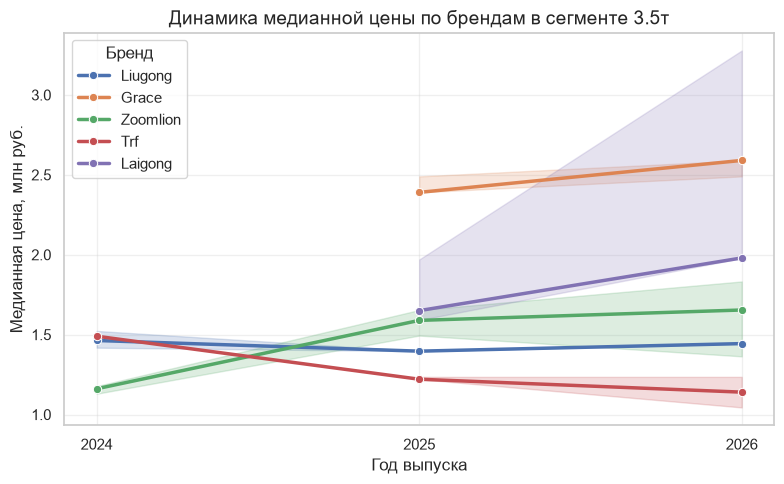

In [169]:
# весь сегмент 2024-2026, топ-5 брендов
df_filtered_top5 = df_filtered[df_filtered['Марка'].isin(df_filtered['Марка'].value_counts().head(5).index)]

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_filtered_top5,
    x='Год выпуска',
    y='Цена',
    hue='Марка',
    estimator='median',
    marker='o',
    linewidth=2.5
)
plt.title('Динамика медианной цены по брендам в сегменте 3.5т', fontsize=14)
plt.xlabel('Год выпуска')
plt.ylabel('Медианная цена, млн руб.')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}'))

plt.xticks([2024, 2025, 2026])
plt.grid(True, alpha=0.3)
plt.legend(title='Бренд')
plt.tight_layout()
plt.show()

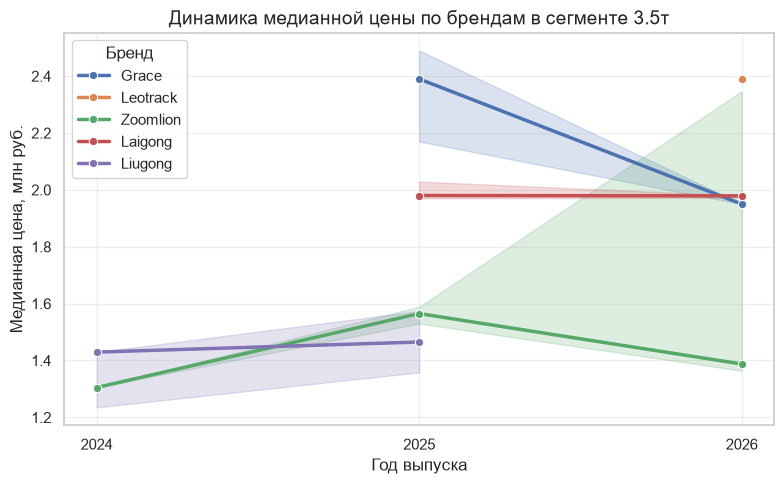

In [170]:
# Только сегмент 3.5т, топ-5 брендов
df_35_top = df_35[df_35['Марка'].isin(df_35['Марка'].value_counts().head(5).index)]

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_35_top,
    x='Год выпуска',
    y='Цена',
    hue='Марка',
    estimator='median',
    marker='o',
    linewidth=2.5
)
plt.title('Динамика медианной цены по брендам в сегменте 3.5т', fontsize=14)
plt.xlabel('Год выпуска')
plt.ylabel('Медианная цена, млн руб.')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}'))

plt.xticks([2024, 2025, 2026])
plt.grid(True, alpha=0.3)
plt.legend(title='Бренд')
plt.tight_layout()
plt.show()

####
<div class="alert alert-success">
    <b>Итог 4.1.4:</b><br>

* Анализ проводился по основным годам выпуска 2024–2026. 2023 год исключён из детальной интерпретации, поскольку представлен всего 6 объявлениями (0,45% выборки), поэтому его статистики недостаточно устойчивы для сравнения с основными годами.
* Медианная цена последовательно растёт: <b>1,28 млн руб. в 2024 → 1,49 млн руб. в 2025 → 1,95 млн руб. в 2026</b>. При этом темп роста медианной цены увеличивается: около <b>+16,5%</b> в 2025 году и <b>+31,3%</b> в 2026 году.
* Одновременно увеличивается вариативность цен: стандартное отклонение возрастает с <b>0,36 млн</b> в 2024 году до <b>0,99 млн</b> в 2025 и <b>1,27 млн</b> в 2026 году. Boxplot показывает расширение распределения и большое количество верхних ценовых выбросов в 2025–2026 годах.
* Во все рассматриваемые годы средняя цена выше медианной, что указывает на <b>правостороннюю асимметрию</b>: отдельные дорогие предложения заметно увеличивают среднюю цену относительно типичного уровня.
* Spearman подтверждает положительную монотонную связь между годом выпуска и ценой: <b>ρ = 0,339</b> по всей выборке и <b>ρ = 0,410</b> внутри сегмента 3,5 т.
* Проверка по пяти крупнейшим брендам внутри сегмента 3,5 т показала, что <b>общий рост цен не воспроизводится одинаково внутри каждого бренда</b>: одни бренды растут, другие остаются относительно стабильными или снижаются. Выбранные пять брендов покрывают около 2/3 объявлений сегмента, поэтому отражают основную часть рыночного предложения, но не весь рынок.

<b>Вывод:</b><br>

* <b>Год выпуска связан с ценой положительно:</b> более новым годам в исследуемой выборке в целом соответствуют более высокие цены.
* При этом связь <b>не является универсальной для всех брендов</b>. Следовательно, наблюдаемый рост цены от 2024 к 2026 году может зависеть не только от самого года выпуска, но и от изменения структуры предложения, прежде всего состава брендов и других характеристик техники.
* На уровне EDA корректно зафиксировать <b>устойчивую межгодовую тенденцию роста типичной цены</b>, но не утверждать, что год выпуска сам по себе является единственной или главной причиной роста.
* Для дальнейшего моделирования целесообразно проверить несколько представлений года выпуска и отдельно оценить, сохраняется ли его эффект после учёта бренда, грузоподъёмности, мощности и других характеристик. Также имеет смысл проверить взаимодействие <b>«год × бренд»</b>, поскольку динамика цен различается между основными брендами.

- Положительная связь между годом выпуска и ценой сохраняется как на всём рынке, так и внутри сегмента 3.5 т. При этом динамика цен отдельных брендов неоднородна, поэтому рост цены по годам нельзя однозначно интерпретировать как самостоятельный эффект года выпуска. На текущем этапе фиксируется общий рыночный тренд, а влияние бренда и взаимодействие «год × бренд» будут оцениваться на этапе моделирования.

</div>


#### 4.1.5. `Марка` или (Бренды техники)

In [171]:
# считаем количество объявлений, долю предложения и медианную цену по брендам
brand_analysis = (
    df_fe
    .groupby('Марка')
    .agg(
        Количество_объявлений=('Цена', 'size'),
        Медианная_цена=('Цена', 'median')
    )
    .sort_values('Количество_объявлений', ascending=False)
)

# считаем долю каждого бренда в общем предложении
brand_analysis['Доля_предложения_%'] = (
    brand_analysis['Количество_объявлений'] / len(df_fe) * 100
)

print('Распределение предложения и медианной цены по брендам:')
print(brand_analysis)

Распределение предложения и медианной цены по брендам:
            Количество_объявлений  Медианная_цена  Доля_предложения_%
Марка                                                                
Zoomlion                      441      1471000.00               32.81
Grace                         238      2590000.00               17.71
Liugong                       123      1400000.00                9.15
Laigong                       109      1970000.00                8.11
Trf                            68      1220889.00                5.06
Goodsense                      53      1441000.00                3.94
Leotrack                       48      2390000.00                3.57
Teu                            48      1890000.00                3.57
Hangcha                        41      1210000.00                3.05
Chl                            37      1263000.00                2.75
Maxora                         21      1631000.00                1.56
Kandela                        20  

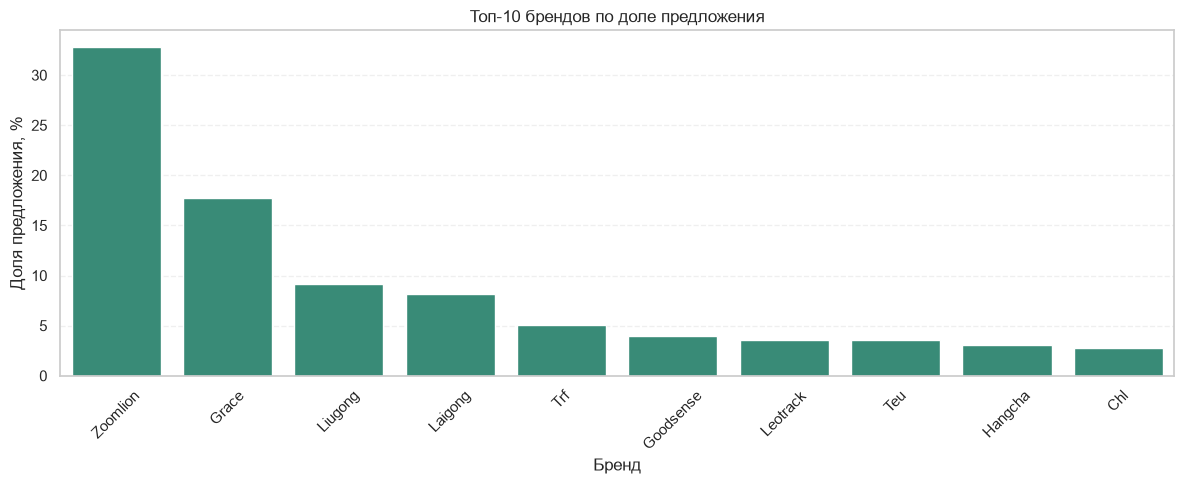

In [172]:
# берём топ-10 брендов по количеству объявлений
top_brands = (brand_analysis.head(10))

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.barplot(
    data=top_brands.reset_index(),
    x='Марка',
    y='Доля_предложения_%',
    ax=axes,
    color='#2b997e'
)

axes.set_title('Топ-10 брендов по доле предложения')
axes.set_xlabel('Бренд')
axes.set_ylabel('Доля предложения, %')
axes.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [173]:
# считаем количество объявлений по брендам и грузоподъёмности
brand_capacity = (
    df_fe
    .groupby(['Марка', 'Грузоподъемность_кг'])
    .size()
    .reset_index(name='Количество объявлений')
)

# добавляем долю каждой грузоподъёмности внутри бренда
brand_capacity['Доля внутри бренда, %'] = (
    brand_capacity.groupby('Марка')['Количество объявлений'].transform(
        lambda x: x / x.sum() * 100
    )
)

print('Структура грузоподъёмности внутри брендов:')
print(brand_capacity)

Структура грузоподъёмности внутри брендов:
       Марка  Грузоподъемность_кг  Количество объявлений  Доля внутри бренда, %
0        Afl              1500.00                      1                  25.00
1        Afl              2000.00                      1                  25.00
2        Afl              3000.00                      2                  50.00
3   Cargador              1500.00                     12                  75.00
4   Cargador              3500.00                      4                  25.00
..       ...                  ...                    ...                    ...
83  Zoomlion              5000.00                     21                   4.76
84  Zoomlion              7000.00                     13                   2.95
85  Zoomlion             10000.00                     19                   4.31
86  Zoomlion             16000.00                      1                   0.23
87      Мксм              3000.00                      2                 100.

In [174]:
# сопоставимые типоразмеры для анализа брендовой премии
target_capacities = [1500, 2000, 2500, 3000, 3500, 5000]

# берём топ-10 брендов и ограничиваем сопоставимыми грузоподъёмностями
df_brand_price = df_fe[
    (df_fe['Марка'].isin(top_brands.index)) &
    (df_fe['Грузоподъемность_кг'].isin(target_capacities))
].copy()

# считаем количество объявлений и медианную цену по бренду и грузоподъёмности
brand_price_by_capacity = (
    df_brand_price
    .groupby(['Грузоподъемность_кг', 'Марка'])
    .agg(
        Количество_объявлений=('Цена', 'size'),
        Медианная_цена=('Цена', 'median')
    )
    .reset_index()
)

# оставляем только сочетания с достаточным количеством объявлений,
# чтобы медиана не была шумовой
MIN_LISTINGS = 5

brand_price_reliable = brand_price_by_capacity[
    brand_price_by_capacity['Количество_объявлений'] >= MIN_LISTINGS
].sort_values(['Грузоподъемность_кг', 'Медианная_цена'], ascending=[True, False])

print('Медианная цена по брендам внутри сопоставимых типоразмеров (мин. 5 объявлений):')
print(brand_price_reliable)

Медианная цена по брендам внутри сопоставимых типоразмеров (мин. 5 объявлений):
    Грузоподъемность_кг      Марка  Количество_объявлений  Медианная_цена
3               1500.00    Laigong                     24      1479000.00
6               1500.00   Zoomlion                     79      1323000.00
4               1500.00        Teu                     16      1280000.00
0               1500.00        Chl                     24      1263000.00
1               1500.00  Goodsense                      6      1257000.00
2               1500.00    Hangcha                      8      1050000.00
5               1500.00        Trf                     17      1044372.00
10              2000.00   Zoomlion                     62      1660000.00
8               2000.00    Liugong                     39      1396424.00
7               2000.00  Goodsense                      9      1303000.00
15              2500.00        Teu                     16      1890000.00
14              2500.00    Liugo

In [175]:
brand_price_pivot = brand_price_reliable.pivot(
    index='Марка',
    columns='Грузоподъемность_кг',
    values='Медианная_цена'
)

print('Медианная цена по брендам и типоразмерам, ₽:')
print(brand_price_pivot)

Медианная цена по брендам и типоразмерам, ₽:
Грузоподъемность_кг    1500.00    2000.00    2500.00    3000.00    3500.00    5000.00
Марка                                                                                
Chl                 1263000.00        NaN        NaN 1158000.00        NaN        NaN
Goodsense           1257000.00 1303000.00        NaN 1491000.00 1936500.00 3311000.00
Grace                      NaN        NaN        NaN        NaN 1950000.00 3150000.00
Hangcha             1050000.00        NaN 1130000.00 1210000.00 1270000.00        NaN
Laigong             1479000.00        NaN 1405821.00 1538000.00 1979125.00 3336000.00
Leotrack                   NaN        NaN        NaN        NaN 2390000.00        NaN
Liugong                    NaN 1396424.00 1443761.00 1463200.00 1465000.00        NaN
Teu                 1280000.00        NaN 1890000.00 1998000.00        NaN        NaN
Trf                 1044372.00        NaN        NaN 1235658.00 1220889.00        NaN
Zoomlion 

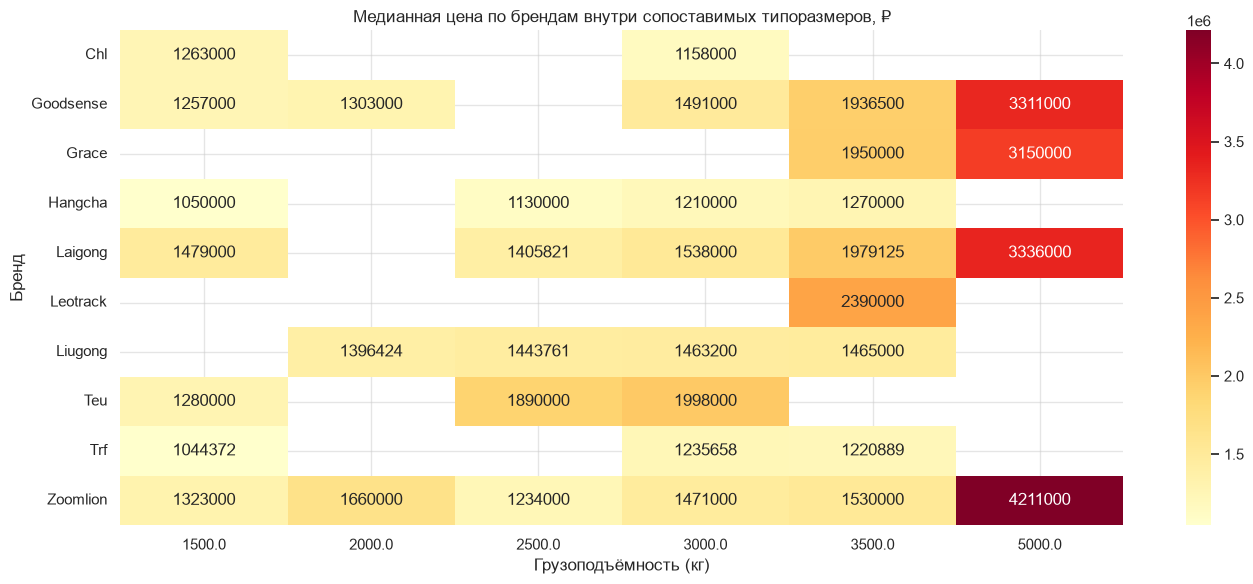

In [176]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

sns.heatmap(
    brand_price_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    ax=axes
)

axes.set_title('Медианная цена по брендам внутри сопоставимых типоразмеров, ₽')
axes.set_xlabel('Грузоподъёмность (кг)')
axes.set_ylabel('Бренд')

plt.tight_layout()
plt.show()

####
<div class="alert alert-success">
<b>Итог по 4.1.5 (Бренды):</b><br>

- Прямое сравнение медианных цен по брендам без контроля грузоподъёмности вводит в заблуждение: бренды сильно различаются<br>
по товарной структуре (например, Grace продаёт только 3500–5000 кг, Zoomlion представлен почти на всех типоразмерах).<br>
Поэтому наблюдавшаяся ранее разница Grace (2,59М) vs Zoomlion (1,47М) частично объясняется ассортиментом, а не «премией бренда».

- После контроля за типоразмером различия между брендами сохраняются и местами существенны: например, на 3500 кг разброс<br>
медиан — от ~1,22М (Trf) до ~2,39М (Leotrack).

- Позиционирование бренда не универсально: Grace дороже Zoomlion на 3500 кг, но дешевле на 5000 кг. Это говорит о том, что<br>
эффект бренда, вероятно, взаимодействует с грузоподъёмностью, а не действует как независимая константа.

<b>Вывод:</b> при дальнейшем моделировании цены бренд стоит рассматривать в связке с грузоподъёмностью (interaction), а не как<br>
отдельный аддитивный признак.

- *небольшое примечание:* также анализ брендов немного дополнил картину с разнообразностью цен в разделе "Марка(бренды)". Сама разнообразность цен обусловлена различными факторами
</div>

### 4.2. Дифференциация дополнительных признаков


#### 4.2.1 Категорийный признаки:
    `Состояние`,
    `ПТС_ПСМ`,
    `Доступность`

In [177]:
df_fe['Состояние'].value_counts(dropna=False)

Состояние
Новое    1344
Name: count, dtype: int64

In [178]:
df_fe['ПТС_ПСМ'].value_counts(dropna=False)

ПТС_ПСМ
Оригинал    1333
Нет           11
Name: count, dtype: int64

In [179]:
df_fe['Доступность'].value_counts(dropna=False)

Доступность
В наличии    1344
Name: count, dtype: int64

####
<div class="alert alert-success">
<b>Итог по 4.2.1:</b><br>
- Признаки: `Состояниe` и `Доступность` необходимо исключить из из анализа и модели, т.к. нет вариативности.<br>
- `ПТС_ПСМ` этот признак также достаточно маловариативен и составляет менее 1% от ген.выборки. его мы тоже исключим из анализа и модели.
</div>

#### 4.2.2. Гарантия
    'serv_warranty_months',
     'serv_warranty_hours',

Гарантия

In [180]:
# распределение гарантии по месяцам
df_fe['serv_warranty_months'].value_counts(dropna=False).sort_index()

serv_warranty_months
12.00    104
24.00      9
36.00    699
60.00      6
NaN      526
Name: count, dtype: int64

In [181]:
# распределение по моточасам
df_fe['serv_warranty_hours'].value_counts(dropna=False).sort_index()

serv_warranty_hours
1000.00     26
2000.00    138
3000.00    683
4000.00      1
5000.00      2
NaN        494
Name: count, dtype: int64

In [182]:
# Полные совпадения: одновременно указаны и месяцы, и моточасы

warranty_pairs = df_fe[
    df_fe['serv_warranty_months'].notna() &
    df_fe['serv_warranty_hours'].notna()
    ]

warranty_pairs[
    ['serv_warranty_months', 'serv_warranty_hours']
].value_counts()

serv_warranty_months  serv_warranty_hours
36.00                 3000.00                649
12.00                 2000.00                 60
36.00                 2000.00                 47
12.00                 1000.00                 26
24.00                 2000.00                  8
60.00                 5000.00                  2
Name: count, dtype: int64

как видно у нас 792 полных совпадений; только моточасов указано - 58; месяцев гарантии - 26

In [183]:
# Только часы: месяцы не указаны, часы указаны

warranty_hours = df_fe.loc[
    df_fe['serv_warranty_months'].isna() &
    df_fe['serv_warranty_hours'].notna(),
    [
        'serv_warranty_months',
        'serv_warranty_hours',
        'Цена',
        'Марка',
        'Модель'
    ]
]

# print(warranty_hours)

In [184]:
# Только месяцы: месяцы указаны, часы не указаны

warranty_months = df_fe.loc[
    df_fe['serv_warranty_months'].notna() &
    df_fe['serv_warranty_hours'].isna(),
    [
        'serv_warranty_months',
        'serv_warranty_hours',
        'Цена',
        'Марка',
        'Модель'
    ]
]

# print(warranty_months)


Исходя из данных, видно, что условия гарантии по месяцам и моточасам
не совпадают полностью и не всегда указываются одновременно.

Поэтому на данном этапе `serv_warranty_months` и
`serv_warranty_hours` рассматриваем как отдельные признаки.

Рассмотрим, как условия гарантии в моточасах распределяются между брендами.

In [185]:
# Количество объявлений каждой марки для каждого варианта гарантии в часах

df_fe.loc[
    df_fe['serv_warranty_hours'].notna(),
    ['Марка', 'serv_warranty_hours']
].groupby('Марка')['serv_warranty_hours'].value_counts(
    dropna=False
).sort_values(ascending=False)

Марка     serv_warranty_hours
Zoomlion  3000.00                414
Grace     3000.00                190
Laigong   2000.00                 55
          3000.00                 54
Leotrack  2000.00                 47
Grace     1000.00                 24
Maxora    3000.00                 21
Cargador  2000.00                 13
Un        2000.00                 11
Afl       2000.00                  4
Tfn       2000.00                  3
Liugong   3000.00                  3
Maxlion   2000.00                  2
Мксм      1000.00                  2
Zoomlion  5000.00                  2
Chl       2000.00                  1
Manforce  2000.00                  1
Leotrack  3000.00                  1
Tfn       4000.00                  1
Zoomlion  2000.00                  1
Name: count, dtype: int64

In [186]:
# Доля каждого варианта гарантии в часах внутри бренда

df_fe.loc[
    df_fe['serv_warranty_hours'].notna(),
    ['Марка', 'serv_warranty_hours']
].groupby('Марка')['serv_warranty_hours'].value_counts(
    normalize=True
).mul(100)

Марка     serv_warranty_hours
Afl       2000.00               100.00
Cargador  2000.00               100.00
Chl       2000.00               100.00
Grace     3000.00                88.79
          1000.00                11.21
Laigong   2000.00                50.46
          3000.00                49.54
Leotrack  2000.00                97.92
          3000.00                 2.08
Liugong   3000.00               100.00
Manforce  2000.00               100.00
Maxlion   2000.00               100.00
Maxora    3000.00               100.00
Tfn       2000.00                75.00
          4000.00                25.00
Un        2000.00               100.00
Zoomlion  3000.00                99.28
          5000.00                 0.48
          2000.00                 0.24
Мксм      1000.00               100.00
Name: proportion, dtype: float64

In [187]:
df_fe.loc[
    df_fe['serv_warranty_hours'].notna(),
    ['Марка', 'serv_warranty_hours']
].groupby(
    ['Марка', 'serv_warranty_hours']
).size().sort_values(ascending=False)

Марка     serv_warranty_hours
Zoomlion  3000.00                414
Grace     3000.00                190
Laigong   2000.00                 55
          3000.00                 54
Leotrack  2000.00                 47
Grace     1000.00                 24
Maxora    3000.00                 21
Cargador  2000.00                 13
Un        2000.00                 11
Afl       2000.00                  4
Tfn       2000.00                  3
Liugong   3000.00                  3
Maxlion   2000.00                  2
Мксм      1000.00                  2
Zoomlion  5000.00                  2
Chl       2000.00                  1
Manforce  2000.00                  1
Leotrack  3000.00                  1
Tfn       4000.00                  1
Zoomlion  2000.00                  1
dtype: int64


Гарантийные условия в моточасах заметно связаны с брендом в исследуемой
выборке. Для большинства брендов с заполненными гарантийными данными
наблюдается один доминирующий вариант гарантии.

При этом размеры отдельных групп невелики, поэтому полученные доли
не следует без дополнительной проверки трактовать как универсальные
характеристики бренда.


Рассмотрим, как условия гарантии в месяцах распределяются между брендами.

In [188]:
# Количество объявлений каждой марки для каждого варианта гарантии в месяцах

df_fe.loc[
    df_fe['serv_warranty_months'].notna(),
    ['Марка', 'serv_warranty_months']
].groupby('Марка')['serv_warranty_months'].value_counts(
    dropna=False
).sort_values(ascending=False)

Марка      serv_warranty_months
Zoomlion   36.00                   414
Grace      36.00                   160
Laigong    12.00                    55
           36.00                    54
Leotrack   36.00                    48
Grace      12.00                    24
Maxora     36.00                    21
Kandela    12.00                    14
Cargador   24.00                     7
Glavman    12.00                     4
Afl        12.00                     4
Мксм       12.00                     2
Hangcha    36.00                     2
Goodsense  60.00                     2
Trf        60.00                     2
Zoomlion   60.00                     2
Hangcha    24.00                     1
Maxlion    24.00                     1
Zoomlion   12.00                     1
Name: count, dtype: int64

In [189]:
# Доля каждого варианта гарантии в месяцах внутри бренда

df_fe.loc[
    df_fe['serv_warranty_months'].notna(),
    ['Марка', 'serv_warranty_months']
].groupby('Марка')['serv_warranty_months'].value_counts(
    normalize=True
).mul(100)

Марка      serv_warranty_months
Afl        12.00                  100.00
Cargador   24.00                  100.00
Glavman    12.00                  100.00
Goodsense  60.00                  100.00
Grace      36.00                   86.96
           12.00                   13.04
Hangcha    36.00                   66.67
           24.00                   33.33
Kandela    12.00                  100.00
Laigong    12.00                   50.46
           36.00                   49.54
Leotrack   36.00                  100.00
Maxlion    24.00                  100.00
Maxora     36.00                  100.00
Trf        60.00                  100.00
Zoomlion   36.00                   99.28
           60.00                    0.48
           12.00                    0.24
Мксм       12.00                  100.00
Name: proportion, dtype: float64

In [190]:
df_fe.loc[
    df_fe['serv_warranty_months'].notna(),
    ['Марка', 'serv_warranty_months']
].groupby(
    ['Марка', 'serv_warranty_months']
).size().sort_values(ascending=False)

Марка      serv_warranty_months
Zoomlion   36.00                   414
Grace      36.00                   160
Laigong    12.00                    55
           36.00                    54
Leotrack   36.00                    48
Grace      12.00                    24
Maxora     36.00                    21
Kandela    12.00                    14
Cargador   24.00                     7
Glavman    12.00                     4
Afl        12.00                     4
Мксм       12.00                     2
Hangcha    36.00                     2
Goodsense  60.00                     2
Trf        60.00                     2
Zoomlion   60.00                     2
Hangcha    24.00                     1
Maxlion    24.00                     1
Zoomlion   12.00                     1
dtype: int64


Условия гарантии в месяцах также демонстрируют связь с брендом.
Однако по сравнению с гарантией в моточасах количество наблюдений
для отдельных комбинаций значительно меньше, поэтому данный вывод
следует интерпретировать осторожнее.

In [191]:
# гарантия связь с ценой
df_fe.groupby('serv_warranty_hours')['Цена'].agg(
    count='count',
    share_pct=lambda x: (
        len(x) /
        df_fe['serv_warranty_hours'].notna().sum()
        * 100
    ),
    mean='mean',
    median='median',
    std='std'
)

,count,share_pct,mean,median,std
serv_warranty_hours,,,,,
1000.00,26,3.06,5896146.15,6300000.00,1426696.24
2000.00,138,16.24,2309714.48,2390000.00,1007902.41
3000.00,683,80.35,2054106.58,1832000.00,1009969.94
4000.00,1,0.12,1531100.00,1531100.00,NaN
5000.00,2,0.24,1245000.00,1245000.00,63639.61


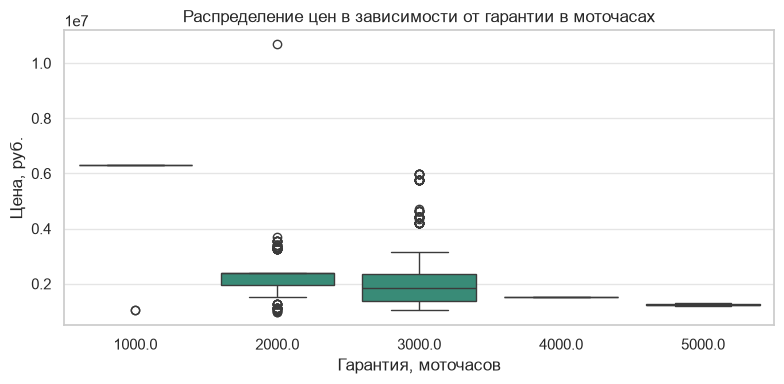

In [192]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_fe[df_fe['serv_warranty_hours'].notna()],
    x='serv_warranty_hours',
    y='Цена',
    color='#2b997e'
)

plt.title('Распределение цен в зависимости от гарантии в моточасах')
plt.xlabel('Гарантия, моточасов')
plt.ylabel('Цена, руб.')

plt.tight_layout()
plt.show()

In [193]:
pd.crosstab(
    df_fe['serv_warranty_hours'],
    df_fe['Грузоподъемность_кг'],
    normalize='index'
).mul(100)

Грузоподъемность_кг,1500.00,1750.00,1800.00,2000.00,2500.00,3000.00,3500.00,5000.00,6000.00,7000.00,10000.00,16000.00
serv_warranty_hours,,,,,,,,,,,,
1000.00,0.00,0.00,0.00,0.00,0.00,7.69,0.00,92.31,0.00,0.00,0.00,0.00
2000.00,9.42,0.72,1.45,0.72,0.00,2.17,65.94,15.94,2.90,0.00,0.00,0.72
3000.00,14.93,0.00,6.30,9.52,8.05,15.23,25.18,16.11,0.00,1.90,2.78,0.00
4000.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5000.00,0.00,0.00,0.00,50.00,0.00,50.00,0.00,0.00,0.00,0.00,0.00,0.00


разные гарантийные группы просто состоят из разной по размеру техники или действительно отличаются ещё чем-то.

In [194]:
df_fe.groupby('serv_warranty_months')['Цена'].agg(
    count='count',
    share_pct=lambda x: (
            len(x) /
            df_fe['serv_warranty_months'].notna().sum()
            * 100
    ),
    mean='mean',
    median='median',
    std='std'
)

,count,share_pct,mean,median,std
serv_warranty_months,,,,,
12.00,104,12.71,3200222.67,2206000.00,2074031.00
24.00,9,1.10,1253333.33,1130000.00,332640.95
36.00,699,85.45,2027319.42,1832000.00,975688.31
60.00,6,0.73,1185526.33,1237000.00,118790.77


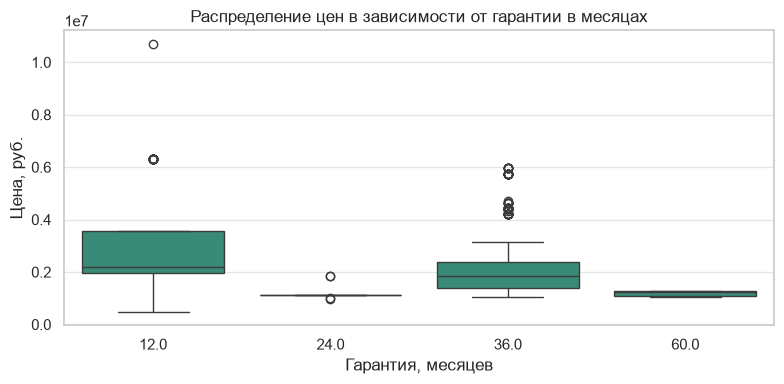

In [195]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_fe[df_fe['serv_warranty_months'].notna()],
    x='serv_warranty_months',
    y='Цена',
    color='#2b997e'
)

plt.title('Распределение цен в зависимости от гарантии в месяцах')
plt.xlabel('Гарантия, месяцев')
plt.ylabel('Цена, руб.')

plt.tight_layout()
plt.show()

проверим зависимость грузоподъемность * гарантия(моточасы) к цене

In [196]:
pd.crosstab(
    df_fe['serv_warranty_months'],
    df_fe['Грузоподъемность_кг'],
    normalize='index'
).mul(100)

Грузоподъемность_кг,800.00,1000.00,1500.00,1800.00,2000.00,2500.00,3000.00,3500.00,5000.00,6000.00,7000.00,10000.00,16000.00
serv_warranty_months,,,,,,,,,,,,,
12.00,0.96,0.96,8.65,0.00,4.81,0.00,7.69,27.88,44.23,3.85,0.00,0.00,0.96
24.00,0.00,0.00,66.67,11.11,0.00,0.00,0.00,22.22,0.00,0.00,0.00,0.00,0.00
36.00,0.00,0.00,14.74,6.15,9.30,7.58,14.88,31.47,11.30,0.00,1.86,2.72,0.00
60.00,0.00,0.00,0.00,0.00,83.33,0.00,16.67,0.00,0.00,0.00,0.00,0.00,0.00


In [197]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'serv_warranty_hours']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
)

count      median        mean
Грузоподъемность_кг serv_warranty_hours                               
1500.00             2000.00                 13  1130000.00  1096137.69
                    3000.00                102  1366000.00  1436919.62
                    4000.00                  1  1531100.00  1531100.00
1750.00             2000.00                  1  1631750.00  1631750.00
1800.00             2000.00                  2  1337900.00  1337900.00
                    3000.00                 43  1210000.00  1233604.65
2000.00             2000.00                  1  1680000.00  1680000.00
                    3000.00                 65  1512000.00  1577141.08
                    5000.00                  1  1200000.00  1200000.00
2500.00             3000.00                 55  1443761.00  1579589.96
3000.00             1000.00                  2  1049900.00  1049900.00
                    2000.00                  3  1250000.00  1426666.67
                    3000.00                104  1494000.00  1661619.70
                    5000.00                  1  1290000.00  1290000.00
3500.00             2000.00                 91  2390000.00  2153844.92
                    3000.00                172  1950000.00  1875439.66
5000.00             1000.00                 24  6300000.00  6300000.00
                    2000.00                 22  3336000.00  3361107.73
                    3000.00                110  3150000.00  3173757.33
6000.00             2000.00                  4  3395000.00  3395000.00
7000.00             3000.00                 13  4436000.00  4528769.23
10000.00            3000.00                 19  5749000.00  5820052.63
16000.00            2000.00                  1 10699000.00 10699000.00

In [198]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'serv_warranty_hours']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг serv_warranty_hours                             
1500.00             2000.00                 13 1130000.00 1096137.69
                    3000.00                102 1366000.00 1436919.62
1800.00             3000.00                 43 1210000.00 1233604.65
2000.00             3000.00                 65 1512000.00 1577141.08
2500.00             3000.00                 55 1443761.00 1579589.96
3000.00             3000.00                104 1494000.00 1661619.70
3500.00             2000.00                 91 2390000.00 2153844.92
                    3000.00                172 1950000.00 1875439.66
5000.00             1000.00                 24 6300000.00 6300000.00
                    2000.00                 22 3336000.00 3361107.73
                    3000.00                110 3150000.00 3173757.33
7000.00             3000.00                 13 4436000.00 4528769.23
10000.00            3000.00                 19 5749000.00 5820052.63

проверим зависимость грузоподъемность * гарантия(МЕСЯЦЫ) к цене

In [199]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'serv_warranty_months']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
)

count      median        mean
Грузоподъемность_кг serv_warranty_months                               
800.00              12.00                     1   480000.00   480000.00
1000.00             12.00                     1   540000.00   540000.00
1500.00             12.00                     9   990000.00   957777.78
                    24.00                     6  1130000.00  1106666.67
                    36.00                   103  1366000.00  1433163.12
1800.00             24.00                     1   980000.00   980000.00
                    36.00                    43  1210000.00  1233604.65
2000.00             12.00                     5   990000.00  1120000.00
                    36.00                    65  1512000.00  1577141.08
                    60.00                     5  1200000.00  1164631.60
2500.00             36.00                    53  1405821.00  1562243.89
3000.00             12.00                     8  1200000.00  1152475.00
                    36.00                   104  1494000.00  1661619.70
                    60.00                     1  1290000.00  1290000.00
3500.00             12.00                    29  1979125.00  2032413.38
                    24.00                     2  1830000.00  1830000.00
                    36.00                   220  1950000.00  1988161.92
5000.00             12.00                    46  6300000.00  4894442.83
                    36.00                    79  3150000.00  3183079.82
6000.00             12.00                     4  3395000.00  3395000.00
7000.00             36.00                    13  4436000.00  4528769.23
10000.00            36.00                    19  5749000.00  5820052.63
16000.00            12.00                     1 10699000.00 10699000.00

In [200]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'serv_warranty_months']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг serv_warranty_months                             
1500.00             36.00                   103 1366000.00 1433163.12
1800.00             36.00                    43 1210000.00 1233604.65
2000.00             36.00                    65 1512000.00 1577141.08
2500.00             36.00                    53 1405821.00 1562243.89
3000.00             36.00                   104 1494000.00 1661619.70
3500.00             12.00                    29 1979125.00 2032413.38
                    36.00                   220 1950000.00 1988161.92
5000.00             12.00                    46 6300000.00 4894442.83
                    36.00                    79 3150000.00 3183079.82
7000.00             36.00                    13 4436000.00 4528769.23
10000.00            36.00                    19 5749000.00 5820052.63

####
<div class="alert alert-success">
<b>Итог по гарантийным условиям 4.2.2:</b><br>

* В датасете гарантия представлена двумя характеристиками: <b>сроком в месяцах</b> и <b>лимитом моточасов</b>. Они не всегда указываются одновременно, поэтому на этапе анализа рассматривались как отдельные признаки.
* Условия гарантии заметно связаны со <b>структурой техники</b>: отдельные варианты гарантии характерны для определённых брендов и грузоподъёмностей.
* При анализе связи гарантии с ценой в общей выборке наблюдаются различия между гарантийными группами, однако после сравнения техники с одинаковой грузоподъёмностью <b>устойчивой зависимости цены от срока гарантии или лимита моточасов не выявлено</b>.
* Направление различий между гарантийными группами неоднородно: в одних типоразмерах более длительная гарантия сопровождается более высокой ценой, в других — более низкой или практически одинаковой.
* Дополнительно часть сочетаний «гарантия × грузоподъёмность» представлена небольшим количеством наблюдений, что ограничивает надёжность отдельных сравнений.

<b>Вывод:</b><br>

* <b>Гарантийные условия не рассматриваем как самостоятельный признак модели ценообразования на текущем этапе.</b>
* Причина отказа от признака — не доказанное отсутствие влияния гарантии, а отсутствие <b>однозначного и устойчивого эффекта</b> после учёта структуры техники.
* При этом признаки гарантии сохраняются в исходном датасете и могут быть использованы в дальнейшем для маркетингового анализа или дополнительной проверки в многомерной модели.
* Для основной модели гарантийные признаки пока исключаем как недостаточно однозначные. В исходном df_fe сохраняем их для возможного дополнительного эксперимента и маркетингового анализа.
</div>


#### 4.2.3. утильсбор
    'util_status',
     'util_amount'

In [201]:
df_fe.groupby('util_status')['Цена'].agg(
    count='count',
    share_pct=lambda x: len(x) / len(df_fe) * 100,
    mean='mean',
    median='median',
    std='std'
)

,count,share_pct,mean,median,std
util_status,,,,,
0,1032,76.79,2106384.14,1820000.00,1173952.48
1,233,17.34,1473224.95,1303000.00,565538.18
2,79,5.88,1448451.06,1235658.00,628657.86


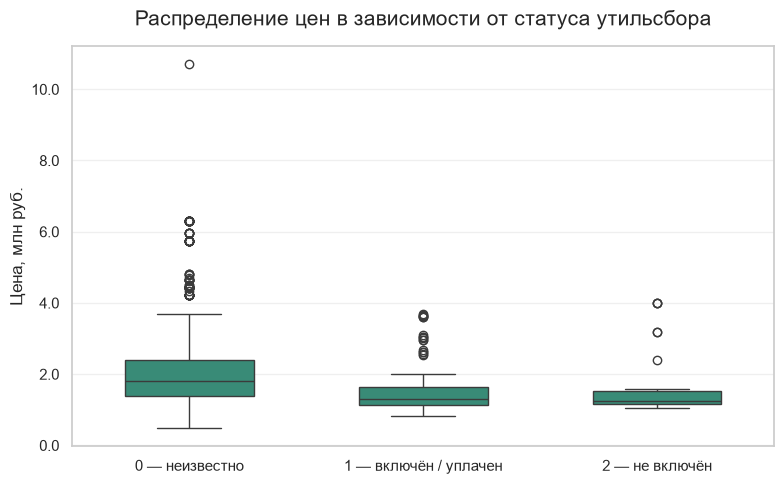

In [202]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_fe,
    x='util_status',
    y='Цена',
    color='#2b997e',
    width=0.55,
    showfliers=True
)

ax.set_xticklabels([
    '0 — неизвестно',
    '1 — включён / уплачен',
    '2 — не включён'
])

plt.title(
    'Распределение цен в зависимости от статуса утильсбора',
    fontsize=15,
    pad=15
)

plt.xlabel('')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

util_status не включаем в основную модель. Несмотря на заметное различие медианных цен между категориями, признак отражает наличие и характер упоминания утилизационного сбора в тексте объявления, а значение 0 не означает отсутствие сбора. Поэтому его связь с ценой неоднозначна и не позволяет интерпретировать признак как самостоятельный фактор стоимости.

In [203]:
df_fe['util_amount'].describe()

count        99.00
mean     283505.22
std      293056.08
min      207000.00
25%      210450.00
50%      210450.00
75%      210450.00
max     1500590.00
Name: util_amount, dtype: float64

In [204]:
df_fe.loc[
    df_fe['util_amount'].notna(),
    ['util_status', 'util_amount', 'Цена', 'Марка', 'Модель']
].sort_values('util_amount')

,util_status,util_amount,Цена,Марка,Модель
1188,2,207000.00,1235658,Trf,D30-3X
1230,2,207000.00,1235658,Trf,D30-3X
1138,2,210000.00,1078714,Trf,D25-3X5
2,1,210450.00,1053000,Chl,CPCD30
15,2,210450.00,1044372,Trf,D15-3X
...,...,...,...,...,...
515,2,1500509.00,3993962,Trf,D100-3X
501,2,1500509.00,3993962,Trf,D100-3X
514,2,1500509.00,3993962,Trf,D100-3X
129,2,1500590.00,3195906,Trf,D70-3X


####
<div class="alert alert-success">
<b>иотг 4.2.3:</b><br>

Информация об утилизационном сборе может влиять не только на содержательную интерпретацию признака, но и на <b>сопоставимость самой цены объявления</b>. В случаях, когда продавец указывает, что утилизационный сбор не включён в цену, опубликованная стоимость потенциально не отражает полную сумму расходов покупателя и может увеличиваться на величину соответствующего сбора.

При этом автоматически корректировать цену на сумму `util_amount` нельзя, поскольку сумма сбора указана лишь в части объявлений, а соответствие между статусом сбора и его конкретной величиной не всегда однозначно установлено.
<b>вывод:</b><br>
Поэтому `util_status` и `util_amount` не используются как самостоятельные признаки основной модели ценообразования, однако <b>факт возможного дополнительного платежа необходимо учитывать при интерпретации ценовых различий и при последующей маркетинговой аналитике</b>.

</div>


### 4.3 Бинарные признаки

#### 4.3.1. Бинарные признаки упоминания(есть или нет в описании)


In [205]:
binary_cols = [
    'nds_mentioned',
    'drive_4wd_mentioned',
    'leasing_mentioned',
    'tradein_mentioned',
    'warranty_mentioned',
    'opt_service_status'
]

for col in binary_cols:
    print(f'\n--- {col} ---')
    print(df_fe[col].value_counts(dropna=False))


--- nds_mentioned ---
nds_mentioned
0    1212
1     132
Name: count, dtype: int64

--- drive_4wd_mentioned ---
drive_4wd_mentioned
0    1015
1     329
Name: count, dtype: int64

--- leasing_mentioned ---
leasing_mentioned
1    1200
0     144
Name: count, dtype: int64

--- tradein_mentioned ---
tradein_mentioned
0    1162
1     182
Name: count, dtype: int64

--- warranty_mentioned ---
warranty_mentioned
1    1120
0     224
Name: count, dtype: int64

--- opt_service_status ---
opt_service_status
1    974
0    370
Name: count, dtype: int64


In [206]:
binary_summary = pd.DataFrame({
    'count_1': [
        df_fe[col].sum()
        for col in binary_cols
    ],

    'share_1_pct': [
        df_fe[col].mean() * 100
        for col in binary_cols
    ],

    'median_price_0': [
        df_fe.loc[df_fe[col] == 0, 'Цена'].median()
        for col in binary_cols
    ],

    'median_price_1': [
        df_fe.loc[df_fe[col] == 1, 'Цена'].median()
        for col in binary_cols
    ]
}, index=binary_cols)

binary_summary['median_diff'] = (
    binary_summary['median_price_1']
    - binary_summary['median_price_0']
)

binary_summary.sort_values(
    'median_diff',
    ascending=False
)

,count_1,share_1_pct,median_price_0,median_price_1,median_diff
drive_4wd_mentioned,329,24.48,1423000.00,2390000.00,967000.00
tradein_mentioned,182,13.54,1494000.00,1950000.00,456000.00
warranty_mentioned,1120,83.33,1396424.00,1654000.00,257576.00
leasing_mentioned,1200,89.29,1499002.00,1595000.00,95998.00
opt_service_status,974,72.47,1499619.50,1595000.00,95380.50
nds_mentioned,132,9.82,1581060.00,1473000.00,-108060.00


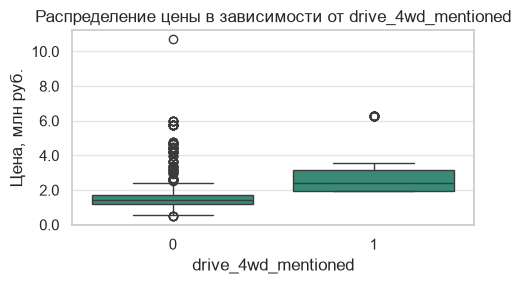

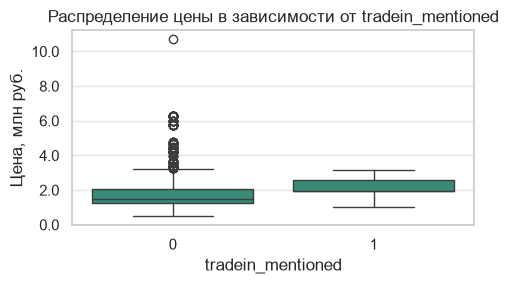

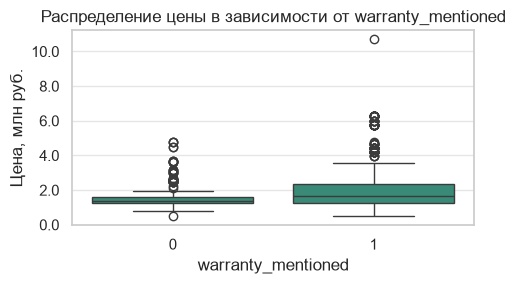

In [207]:
for col in ['drive_4wd_mentioned', 'tradein_mentioned', 'warranty_mentioned']:
    plt.figure(figsize=(5, 3))

    sns.boxplot(
        data=df_fe,
        x=col,
        y='Цена',
        color='#2b997e'
    )

    plt.title(f'Распределение цены в зависимости от {col}')
    plt.xlabel(col)
    plt.ylabel('Цена, млн руб.')

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
    )

    plt.tight_layout()
    plt.show()

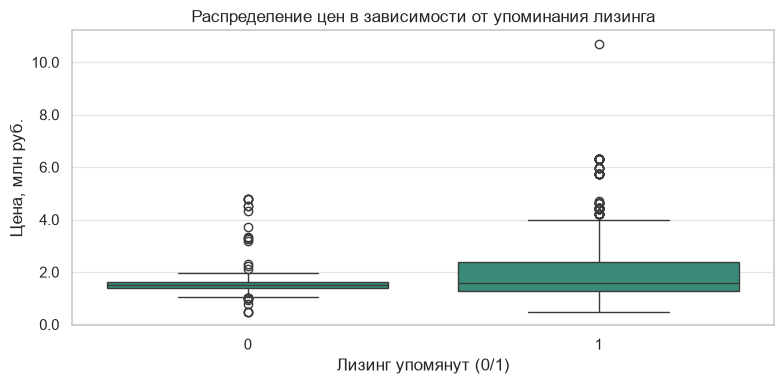

In [208]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_fe,
    x='leasing_mentioned',
    y='Цена',
    color='#2b997e'
)

plt.title('Распределение цен в зависимости от упоминания лизинга')
plt.xlabel('Лизинг упомянут (0/1)')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.tight_layout()
plt.show()


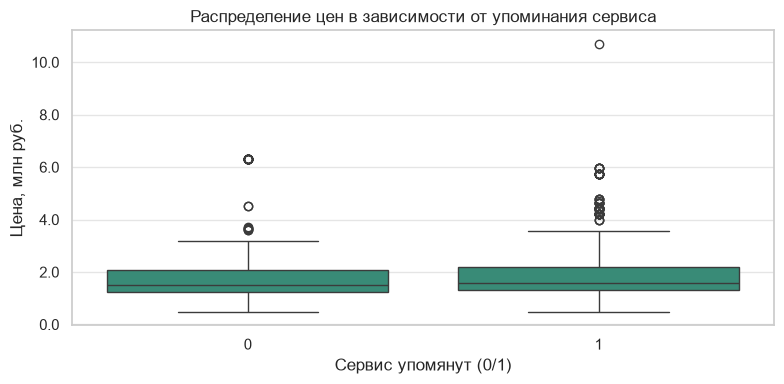

In [209]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_fe,
    x='opt_service_status',
    y='Цена',
    color='#2b997e'
)

plt.title('Распределение цен в зависимости от упоминания сервиса')
plt.xlabel('Сервис упомянут (0/1)')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.tight_layout()
plt.show()

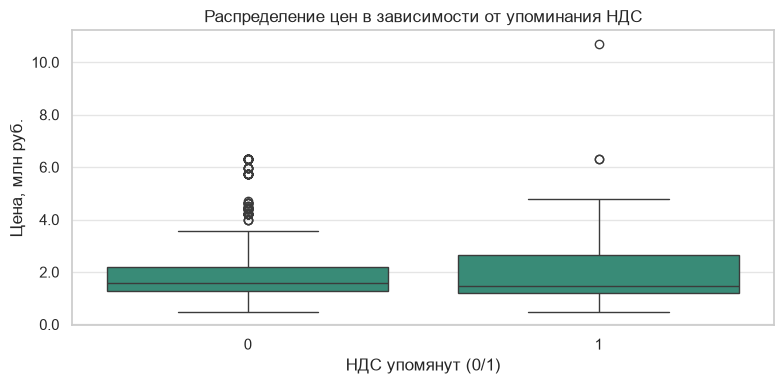

In [210]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_fe,
    x='nds_mentioned',
    y='Цена',
    color='#2b997e'
)

plt.title('Распределение цен в зависимости от упоминания НДС')
plt.xlabel('НДС упомянут (0/1)')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.tight_layout()
plt.show()

leasing_mentioned, opt_service_status и nds_mentioned не демонстрируют выраженной связи с ценой на уровне описательной статистики. Различия медианных цен между группами невелики, а наблюдаемые различия в разбросе сопровождаются большим количеством выбросов. Поэтому на текущем этапе эти признаки не являются приоритетными кандидатами для модели ценообразования.

Рассмотрим drive_4wd_mentioned и tradein_mantioned упоминание признаков полного привода дальше и трейдин

In [211]:
# проверим по грузоподъемности drive_4wd_mentioned
result = (
    df_fe
    .groupby(['Грузоподъемность_кг', 'drive_4wd_mentioned'])['Цена']
    .agg(
        n='count',
        median='median'
    )
    .reset_index()
)

print(result.to_string(index=False))

 Грузоподъемность_кг  drive_4wd_mentioned   n      median
              800.00                    0   4   480000.00
             1000.00                    0  18   838000.00
             1500.00                    0 204  1280000.00
             1600.00                    0   1  1900000.00
             1750.00                    0   1  1631750.00
             1800.00                    0  62  1226000.00
             2000.00                    0 134  1396424.00
             2500.00                    0 115  1443761.00
             3000.00                    0 234  1463200.00
             3500.00                    0 162  1518889.00
             3500.00                    1 184  1950000.00
             5000.00                    0  35  4211000.00
             5000.00                    1 145  3150000.00
             6000.00                    0   4  3395000.00
             7000.00                    0  18  4436000.00
            10000.00                    0  22  5749000.00
            16

In [212]:
# проверим по грузоподъемности tradein_mentioned
result = (
    df_fe
    .groupby(['Грузоподъемность_кг', 'tradein_mentioned'])['Цена']
    .agg(
        n='count',
        median='median'
    )
    .reset_index()
)

print(result.to_string(index=False))

 Грузоподъемность_кг  tradein_mentioned   n      median
              800.00                  0   4   480000.00
             1000.00                  0  18   838000.00
             1500.00                  0 193  1280000.00
             1500.00                  1  11  1130000.00
             1600.00                  0   1  1900000.00
             1750.00                  0   1  1631750.00
             1800.00                  0  61  1210000.00
             1800.00                  1   1  1292000.00
             2000.00                  0 130  1396424.00
             2000.00                  1   4  1328000.00
             2500.00                  0 114  1443761.00
             2500.00                  1   1  1340000.00
             3000.00                  0 229  1463200.00
             3000.00                  1   5  3039000.00
             3500.00                  0 242  1589000.00
             3500.00                  1 104  1950000.00
             5000.00                  0 124  327

####
<div class="alert alert-success">
<b>Итог по 4.3.1. бинарным признакам упоминания:</b><br>

* На этапе первичного анализа отдельные бинарные признаки демонстрировали различия медианных цен. Наиболее заметные различия наблюдались для <b>упоминания полного привода</b> и <b>trade-in</b>.
* После контроля по <b>грузоподъёмности</b> устойчивого однонаправленного эффекта не выявлено: в разных типоразмерах направление различий могло меняться, а отдельные группы были представлены небольшим количеством наблюдений.
* Для признаков <b>упоминания гарантии</b> и <b>сервисного обслуживания</b> дополнительный самостоятельный эффект не подтверждён; гарантийные условия ранее были отдельно исследованы и также не показали однозначной зависимости цены после учёта структуры техники.
* Признаки <b>НДС, лизинга, trade-in, гарантии, полного привода и сервисного обслуживания</b> не рассматриваются как самостоятельные факторы ценообразования в основной модели.
* При этом исходные признаки сохраняются в <b>df_fe</b> для возможного дополнительного анализа коммерческих и маркетинговых характеристик объявлений.

<b>Вывод:</b><br>

Бинарные текстовые и коммерческие признаки(упоминания) не включаются в основную модель, поскольку наблюдаемые различия в цене не продемонстрировали достаточно устойчивого самостоятельного эффекта после учёта структуры техники.
</div>

#### 4.3.2. "Бинарные признаки" статуса
 (найден/не найден, входит, частичное вхождение), это не совсем "бинарные признаки" тк они шифруются несколькими цифрами

In [213]:
multi_cols = [
    'attachment_extra_status',
    'opt_sideshift_status',
    'opt_transmission_auto_status',
    'opt_cabin_status',
    'util_status'
]

In [214]:
for col in multi_cols:
    print(f'\n--- {col} ---')
    print(df_fe[col].value_counts(dropna=False).sort_index())


--- attachment_extra_status ---
attachment_extra_status
0    558
1     58
2    571
3    157
Name: count, dtype: int64

--- opt_sideshift_status ---
opt_sideshift_status
0    912
1    165
2    148
3    119
Name: count, dtype: int64

--- opt_transmission_auto_status ---
opt_transmission_auto_status
0    641
1    678
2     25
Name: count, dtype: int64

--- opt_cabin_status ---
opt_cabin_status
0    404
1    686
2      1
3    166
4     87
Name: count, dtype: int64

--- util_status ---
util_status
0    1032
1     233
2      79
Name: count, dtype: int64


In [215]:
for col in multi_cols:
    print(f'\n===== {col} =====')

    summary = (
        df_fe.groupby(col)['Цена']
        .agg(
            count='count',
            share_pct=lambda x: len(x) / len(df_fe) * 100,
            mean='mean',
            median='median',
            std='std'
        )
        .sort_index()
    )

    print(summary)


===== attachment_extra_status =====
                         count  share_pct       mean     median        std
attachment_extra_status                                                   
0                          558      41.52 1807671.73 1573936.00  864719.02
1                           58       4.32 4260344.83 3150000.00 1784688.25
2                          571      42.49 1879242.79 1512000.00 1033724.66
3                          157      11.68 1927700.76 1651000.00  772224.94

===== opt_sideshift_status =====
                      count  share_pct       mean     median        std
opt_sideshift_status                                                   
0                       912      67.86 1759814.11 1523000.00  755914.24
1                       165      12.28 2860284.85 2654000.00 1756809.23
2                       148      11.01 2331117.28 1760000.00 1552124.63
3                       119       8.85 1761131.50 1591000.00  635699.61

===== opt_transmission_auto_status =====
     

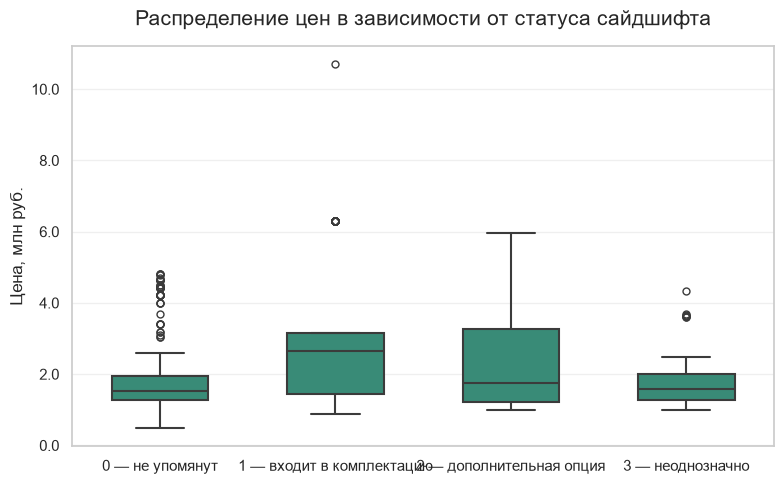

In [216]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_fe,
    x='opt_sideshift_status',
    y='Цена',
    color='#2b997e',
    width=0.55,
    showfliers=True,
    fliersize=5,
    linewidth=1.5
)

ax.set_xticklabels([
    '0 — не упомянут',
    '1 — входит в комплектацию',
    '2 — дополнительная опция',
    '3 — неоднозначно'
])

plt.title(
    'Распределение цен в зависимости от статуса сайдшифта',
    fontsize=15,
    pad=15
)

plt.xlabel('')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

Статус сайдшифта демонстрирует заметную неоднородность ценовых распределений. Наиболее высокий типичный уровень цены наблюдается для объявлений, где сайдшифт входит в комплектацию. Это делает opt_sideshift_status перспективным кандидатом для дальнейшей проверки как потенциального ценового фактора.

- не объясняется ли высокая цена категории 1 тем, что такие погрузчики просто имеют большую грузоподъёмность, более дорогие бренды или другие характеристики.

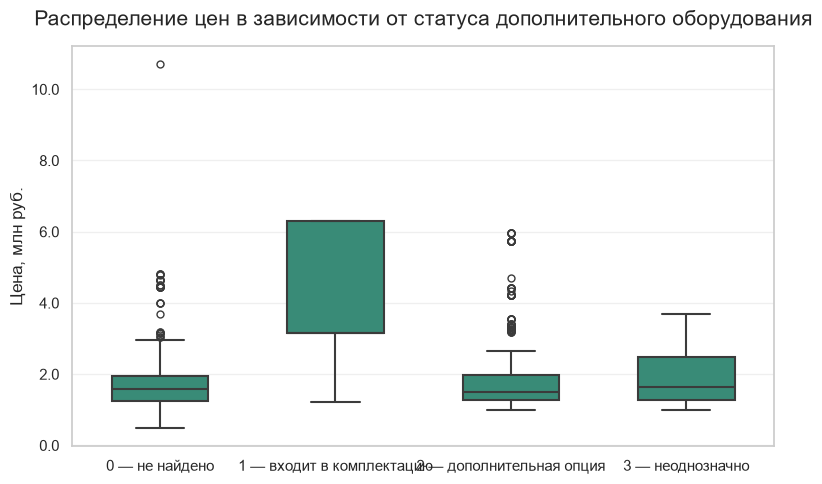

In [217]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_fe,
    x='attachment_extra_status',
    y='Цена',
    color='#2b997e',
    width=0.55,
    showfliers=True,
    fliersize=5,
    linewidth=1.5
)

ax.set_xticklabels([
    '0 — не найдено',
    '1 — входит в комплектацию',
    '2 — дополнительная опция',
    '3 — неоднозначно'
])

plt.title(
    'Распределение цен в зависимости от статуса дополнительного оборудования',
    fontsize=15,
    pad=15
)

plt.xlabel('')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

Статус дополнительного оборудования демонстрирует выраженное различие ценовых распределений. Наиболее высокий уровень цены наблюдается в группе, где дополнительное оборудование входит в комплектацию: медианная цена составляет 3,15 млн руб. против 1,57 млн руб. при отсутствии найденного оборудования. При этом данное различие требует контроля по грузоподъёмности, бренду и другим техническим характеристикам, поскольку категория 1 может характеризоваться иным составом техники.

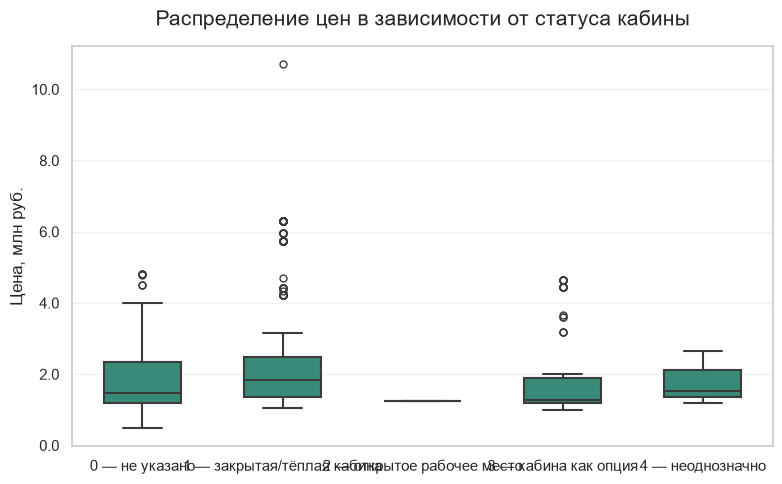

In [218]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_fe,
    x='opt_cabin_status',
    y='Цена',
    color='#2b997e',
    width=0.55,
    showfliers=True,
    fliersize=5,
    linewidth=1.5
)

ax.set_xticklabels([
    '0 — не указано',
    '1 — закрытая/тёплая кабина',
    '2 — открытое рабочее место',
    '3 — кабина как опция',
    '4 — неоднозначно'
])

plt.title(
    'Распределение цен в зависимости от статуса кабины',
    fontsize=15,
    pad=15
)

plt.xlabel('')
plt.ylabel('Цена, млн руб.')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}')
)

plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

Статус кабины связан с уровнем цены, однако различия между категориями выражены умеренно и имеют неоднозначный характер. Наиболее высокая медианная цена наблюдается для техники с закрытой/тёплой кабиной, тогда как предложения, где кабина указана как дополнительная опция, имеют более низкую медианную цену. Это не позволяет интерпретировать наличие кабины как однозначный самостоятельный фактор стоимости.

- Для ряда признаков комплектации наблюдается общий паттерн: когда соответствующая характеристика явно входит в комплектацию техники, медианная цена выше, чем при отсутствии её упоминания или при указании её как дополнительной опции. Наиболее выраженная разница наблюдается для дополнительного оборудования и сайдшифта.

проведем проверку влияния в паре с грузоподъемностью

In [219]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'opt_sideshift_status']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг opt_sideshift_status                             
1000.00             0                        18  838000.00  819055.56
1500.00             0                       103 1287000.00 1337761.65
                    1                        23 1130000.00 1329478.26
                    2                        41 1130000.00 1219097.56
                    3                        37 1280000.00 1298264.59
1800.00             0                        56 1210000.00 1246550.00
2000.00             0                       112 1396424.00 1485320.25
                    1                        15 1325000.00 1560600.00
2500.00             0                        79 1443761.00 1599355.08
                    1                        11 2222000.00 1717636.36
                    3                        19 1890000.00 1832684.21
3000.00             0                       161 1471000.00 1572679.61
                    1                        13 1364000.00 1503307.69
                    2                        23 1210000.00 1225521.74
                    3                        37 1650000.00 1679798.73
3500.00             0                       282 1950000.00 1834923.85
                    1                        18 2509500.00 2161000.00
                    2                        34 1971194.00 1936764.35
                    3                        12 2490000.00 2318833.33
5000.00             0                        73 2590000.00 3054478.21
                    1                        78 3150000.00 4109884.62
                    2                        25 3317760.00 3339374.80
7000.00             0                        15 4436000.00 4351054.13
10000.00            2                        19 5749000.00 5820052.63

In [220]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'attachment_extra_status']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг attachment_extra_status                             
1000.00             0                           18  838000.00  819055.56
1500.00             0                           49 1059000.00 1120482.63
                    2                          132 1347000.00 1382657.58
                    3                           23 1280000.00 1259643.04
1800.00             0                           12 1181000.00 1255500.00
                    2                           43 1210000.00 1233604.65
2000.00             0                           62 1396424.00 1428995.13
                    2                           65 1512000.00 1577141.08
2500.00             0                           35 1443761.00 1756089.29
                    2                           53 1405821.00 1559526.91
                    3                           27 1890000.00 1587629.63
3000.00             0                           78 1308674.00 1433519.51
                    2                          114 1485000.00 1600688.15
                    3                           39 1463200.00 1670794.87
3500.00             0                          223 1950000.00 1887265.57
                    2                           95 1589000.00 1810059.05
                    3                           20 1536590.00 1869334.00
5000.00             0                           57 2590000.00 2622208.93
                    1                           47 6300000.00 4758510.64
                    2                           46 3549000.00 3776688.61
                    3                           30 3150000.00 3180533.33
7000.00             0                           15 4436000.00 4351054.13
10000.00            2                           19 5749000.00 5820052.63

Часть маркетинговых и комплектационных признаков демонстрирует различия ценовых распределений, однако эти различия во многих случаях связаны со структурой техники — прежде всего с грузоподъёмностью и брендом. Наиболее устойчивым кандидатом среди уже проверенных признаков выглядит opt_sideshift_status.

In [221]:
df_fe.groupby(
    ['Грузоподъемность_кг', 'opt_cabin_status']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг opt_cabin_status                             
1000.00             0                    18  838000.00  819055.56
1500.00             0                    53 1059000.00 1162616.02
                    1                    97 1366000.00 1396802.07
                    3                    47 1263000.00 1189718.94
1800.00             0                    12 1181000.00 1255500.00
                    1                    43 1210000.00 1233604.65
2000.00             0                    49 1396424.00 1439546.16
                    1                    59 1512000.00 1529358.81
                    4                    20 1396424.00 1591596.80
2500.00             0                    34 1443761.00 1768327.21
                    1                    48 1405821.00 1470769.29
                    3                    26 1890000.00 1599692.31
3000.00             0                    63 1299300.00 1495453.21
                    1                    92 1485000.00 1591515.75
                    3                    49 1314000.00 1490608.16
                    4                    29 1523000.00 1661074.83
3500.00             0                   132 1979487.50 1985709.95
                    1                   179 1950000.00 1840094.32
                    3                    11 1270000.00 1292454.55
                    4                    24 1466097.50 1846454.83
5000.00             0                    26 3297805.00 3278895.35
                    1                   148 3150000.00 3625495.31
7000.00             3                    13 4436000.00 4528769.23
10000.00            1                    19 5749000.00 5820052.63

Высокая медианная цена закрытой кабины в общей выборке в значительной степени объясняется структурой техники. После учёта грузоподъёмности устойчивой самостоятельной связи opt_cabin_status с ценой не наблюдается.

####
<div class="alert alert-success">
<b>Итог по 4.3.2. статусным признакам:</b><br>

* В эту группу вошли признаки <b>дополнительного оборудования, сайдшифта, автоматической трансмиссии, кабины и утилизационного сбора</b>.
* На уровне общей выборки отдельные категории демонстрировали различия медианных цен, однако значительная часть этих различий была связана со <b>структурой техники</b>, прежде всего с грузоподъёмностью.
* После сравнения объявлений внутри одинаковых значений грузоподъёмности устойчивого и однозначного эффекта для всех статусных признаков не выявлено.
* Для <b>opt_sideshift_status</b> наблюдались различия цен внутри отдельных сегментов, особенно при грузоподъёмности 3500 и 5000 кг. Однако различия между категориями были неоднородными, а некоторые группы содержали небольшое количество наблюдений, поэтому признак не включался в основную модель на текущем этапе.
* Для <b>attachment_extra_status</b> наблюдаемый общий ценовой эффект в значительной степени объяснялся различиями в структуре техники.
* Для <b>opt_transmission_auto_status</b> существенных различий между основными категориями не обнаружено.
* Для <b>opt_cabin_status</b> после контроля по грузоподъёмности направление ценовых различий оказалось неоднозначным.
* Для <b>util_status</b> интерпретация ограничена тем, что значение <b>0</b> означает неизвестный статус, а не отсутствие утилизационного сбора. Поэтому признак не рассматривался как надёжный самостоятельный фактор цены.

<b>Вывод:</b><br>

<b>attachment_extra_status, opt_sideshift_status, opt_transmission_auto_status, opt_cabin_status и util_status</b> не включаются в основную модель как самостоятельные признаки ценообразования. Наблюдаемые различия по отдельным категориям недостаточно устойчивы после учёта структуры техники либо требуют более сложной многомерной проверки. При этом все признаки сохраняются в <b>df_fe</b> для возможного дальнейшего анализа и экспериментов.
</div>

### 4.4. Проверить "шумные признаки" (географ. положение, время публикации, изменнение курса валют {мб есть какой-то неликвид} )

#### 4.4.1 Проверка дублирующих объявлений

тк у нас есть уникальный идентификатор и уникальные ссылки, ghjdthrf yf hfyytq cnflbb. нужно искать дубли, по комбинациям признаков регион, продавец итд

In [222]:
# Повторяющиеся комбинации продавца и техники
repeat_ads = (
    df_fe
    .groupby(
        ['Продавец', 'Марка', 'Модель', 'Грузоподъемность_кг', 'Цена'],
        dropna=False
    )
    .agg(
        n=('Цена', 'size'),
        regions=('Регион', 'nunique'),
        region_list=('Регион', lambda x: ', '.join(sorted(x.dropna().astype(str).unique())))
    )
    .reset_index()
    .query('n >= 2')
    .sort_values(['n', 'regions'], ascending=False)
)

# repeat_ads.head(20)

«Технических дубликатов объявлений по номеру и ссылке не обнаружено. При этом выявлены массовые повторные размещения типовых коммерческих предложений: <br>
одинаковые комбинации продавца, модели, грузоподъёмности и цены встречаются многократно, в том числе в разных регионах. Поэтому такие наблюдения не удалялись<br>
 автоматически как дубликаты, но данный фактор необходимо учитывать при интерпретации региональной структуры предложения.»

In [223]:
# Проверка повторяемости типовых коммерческих предложений
repeat_stats = (
    df_fe
    .groupby(
        ['Продавец', 'Марка', 'Модель',
         'Грузоподъемность_кг', 'Цена'],
        dropna=False
    )
    .size()
    .rename('repeat_count')
)

# Распределение количества повторов для уникальных коммерческих комбинаций
print(repeat_stats.describe())

print('\nКоличество коммерческих комбинаций по уровню повторяемости:')
print(
    pd.cut(
        repeat_stats,
        bins=[0, 1, 2, 5, 10, 20, float('inf')],
        labels=['1', '2', '3–5', '6–10', '11–20', '21+']
    )
    .value_counts(sort=False)
)

# Доля уникальных коммерческих комбинаций, повторяющихся более одного раза
share_repeated = (repeat_stats > 1).mean() * 100

print(
    f'\nДоля повторяющихся коммерческих комбинаций: '
    f'{share_repeated:.1f}%'
)

count   298.00
mean      4.51
std       7.92
min       1.00
25%       1.00
50%       2.00
75%       6.00
max      97.00
Name: repeat_count, dtype: float64

Количество коммерческих комбинаций по уровню повторяемости:
repeat_count
1        120
2         39
3–5       31
6–10      92
11–20     10
21+        6
Name: count, dtype: int64

Доля повторяющихся коммерческих комбинаций: 59.7%


In [224]:
# Считаем количество объявлений для каждой коммерческой комбинации
repeat_counts = (
    df_fe
    .groupby(
        ['Продавец', 'Марка', 'Модель',
         'Грузоподъемность_кг', 'Цена'],
        dropna=False
    )
    .size()
)

# Оставляем только комбинации, которые встречаются более одного раза
repeated_rows = repeat_counts[repeat_counts > 1].sum()

# Рассчитываем их долю среди всех объявлений
share_repeated_rows = repeated_rows / len(df_fe) * 100

print(
    f'Объявлений, входящих в повторяющиеся коммерческие комбинации: '
    f'{repeated_rows} из {len(df_fe)} '
    f'({share_repeated_rows:.1f}%)'
)

Объявлений, входящих в повторяющиеся коммерческие комбинации: 1224 из 1344 (91.1%)


####
<div class="alert alert-success">
<b>4.4.1. Итог по проверке дублирующих комбинаций:</b><br>

* Полных дубликатов объявлений по <b>номеру объявления</b> и <b>ссылке</b> не обнаружено: все 1344 записи имеют уникальные идентификаторы.
* При этом выявлена высокая повторяемость типовых коммерческих предложений. При группировке по комбинации <b>Продавец + Марка + Модель + Грузоподъемность + Цена</b> получено 298 уникальных коммерческих комбинаций, при этом среднее число размещений одной комбинации составляет 4,51.
* <b>59,7%</b> уникальных коммерческих комбинаций встречаются более одного раза, а <b>91,1%</b> всех объявлений входят в такие повторяющиеся комбинации.
* Это указывает на наличие <b>массовых повторных размещений типовых предложений</b>, в том числе в разных регионах. Такие записи не рассматриваются как полные дубликаты и автоматически не удаляются.
* Повторные размещения необходимо учитывать при интерпретации <b>региональной структуры предложения</b>, поскольку количество объявлений в регионе не всегда отражает количество уникальных рыночных предложений.

<b>Вывод:</b><br>

В датасете отсутствуют полные дубликаты объявлений, однако широко представлены повторные размещения одинаковых коммерческих предложений. Поэтому при дальнейшем анализе региона количество объявлений следует интерпретировать с осторожностью: высокая представленность региона может частично объясняться тиражированием типовых предложений продавцами.
</div>

#### 4.4.2. Географический фактор


In [225]:
# Основная статистика предложения по регионам
region_summary = (
    df_fe
    .groupby('Регион')
    .agg(
        n_ads=('Цена', 'size'),
        sellers=('Продавец', 'nunique'),
        brands=('Марка', 'nunique'),
        median_price=('Цена', 'median')
    )
    .sort_values('n_ads', ascending=False)
)

# Доля региона в общем количестве объявлений
region_summary['share_pct'] = (
    region_summary['n_ads'] / len(df_fe) * 100
)

# Количество уникальных коммерческих комбинаций в регионе
region_unique_offers = (
    df_fe
    .groupby('Регион')
    .apply(
        lambda x: x[
            ['Продавец', 'Марка', 'Модель',
             'Грузоподъемность_кг', 'Цена']
        ].drop_duplicates().shape[0]
    )
    .rename('unique_offers')
)

region_summary = region_summary.join(region_unique_offers)

# Общее количество уникальных коммерческих комбинаций
total_unique_offers = (
    df_fe[
        ['Продавец', 'Марка', 'Модель',
         'Грузоподъемность_кг', 'Цена']
    ]
    .drop_duplicates()
    .shape[0]
)

# Доля уникальных комбинаций, представленных в регионе
region_summary['unique_offer_coverage_pct'] = (
    region_summary['unique_offers'] / total_unique_offers * 100
)

# Среднее количество объявлений на одну коммерческую комбинацию
region_summary['repeat_ratio'] = (
    region_summary['n_ads'] / region_summary['unique_offers']
)

region_summary

,n_ads,sellers,brands,median_price,share_pct,unique_offers,unique_offer_coverage_pct,repeat_ratio
Регион,,,,,,,,
Москва,461,18,18,1970000.00,34.30,204,68.46,2.26
Московская область,211,14,16,1650000.00,15.70,140,46.98,1.51
Санкт-Петербург,144,12,15,1414410.50,10.71,129,43.29,1.12
Нижегородская область,101,7,8,1530000.00,7.51,100,33.56,1.01
Татарстан,100,5,6,1489500.00,7.44,95,31.88,1.05
Самарская область,96,5,6,1521000.00,7.14,95,31.88,1.01
Ростовская область,40,7,8,1506000.00,2.98,37,12.42,1.08
Воронежская область,31,5,5,1254008.00,2.31,29,9.73,1.07
Ивановская область,23,2,4,1484000.00,1.71,23,7.72,1.00


в Москве 461 объявление, но они соответствуют 204 различным коммерческим комбинациям Продавец + Марка + Модель + Грузоподъемность + Цена.<br>
68.46% всех уникальных коммерческих комбинаций, встречающихся в датасете, представлены хотя бы в одном объявлении Москвы.
461 объявление; 204 уникальные комбинации `unique_offers`; 298 уникальных коммерческих комбинаций `unique_offer_share_pct`; степень повторов объявлений, сколько в среднем повторов на регион `repeat_ratio`

In [226]:
# Регионы с наибольшим количеством объявлений
region_summary[
    ['n_ads', 'share_pct', 'sellers', 'brands',
     'unique_offers', 'repeat_ratio', 'median_price']
].head(10)

,n_ads,share_pct,sellers,brands,unique_offers,repeat_ratio,median_price
Регион,,,,,,,
Москва,461,34.30,18,18,204,2.26,1970000.00
Московская область,211,15.70,14,16,140,1.51,1650000.00
Санкт-Петербург,144,10.71,12,15,129,1.12,1414410.50
Нижегородская область,101,7.51,7,8,100,1.01,1530000.00
Татарстан,100,7.44,5,6,95,1.05,1489500.00
Самарская область,96,7.14,5,6,95,1.01,1521000.00
Ростовская область,40,2.98,7,8,37,1.08,1506000.00
Воронежская область,31,2.31,5,5,29,1.07,1254008.00
Ивановская область,23,1.71,2,4,23,1.00,1484000.00


In [227]:
# Регионы с небольшим объёмом предложения
region_summary[
    ['n_ads', 'share_pct', 'sellers', 'brands',
     'unique_offers', 'repeat_ratio', 'median_price']
].sort_values('n_ads').head(10)

,n_ads,share_pct,sellers,brands,unique_offers,repeat_ratio,median_price
Регион,,,,,,,
Калужская область,3,0.22,2,1,3,1.00,1396424.00
Саратовская область,3,0.22,1,2,3,1.00,1500000.00
Смоленская область,3,0.22,1,1,3,1.00,1443761.00
Чувашия,3,0.22,3,3,3,1.00,2000000.00
Рязанская область,4,0.30,2,1,4,1.00,1420092.50
Костромская область,4,0.30,1,2,4,1.00,1585000.00
Кировская область,4,0.30,1,2,4,1.00,1585000.00
Архангельская область,4,0.30,1,2,4,1.00,1585000.00
Вологодская область,4,0.30,1,2,4,1.00,1585000.00


####
<div class="alert alert-success">
<b>4.4.2 Итог по географии предложения:</b><br>

* Предложение в выборке выраженно концентрировано в нескольких регионах. На <b>Москву, Московскую область и Санкт-Петербург приходится 60,7%</b> всех объявлений, а шесть крупнейших регионов формируют около <b>82,8%</b> выборки.
* <b>Москва</b> является крупнейшим региональным рынком в данных: 461 объявление (34,3% выборки), 18 продавцов и 18 представленных брендов. При этом на 461 объявление приходится 204 уникальные коммерческие комбинации, что соответствует коэффициенту повторяемости около <b>2,26</b>.
* В Московской области и Санкт-Петербурге повторяемость ниже: около <b>1,51</b> и <b>1,12</b> объявления на одну коммерческую комбинацию соответственно. В Нижегородской области, Татарстане и Самарской области этот показатель близок к единице.
* Обнаруженное многократное размещение одинаковых коммерческих предложений показывает, что <b>один продавец может размещать типовые предложения одновременно в нескольких регионах</b>. Поэтому регион публикации не всегда следует напрямую трактовать как фактическое местонахождение продавца или физическое наличие техники в данном регионе.
* Таким образом, количество объявлений по региону может завышать оценку фактической широты локального предложения. Особенно это важно при интерпретации Москвы и других крупных регионов с высокой повторяемостью размещений.
* Для регионов с небольшим количеством наблюдений медианные цены интерпретируются с осторожностью: при <b>n = 3–6</b> отдельные объявления могут существенно влиять на значение медианы.

<b>Вывод:</b><br>

Основная масса наблюдаемого предложения сосредоточена в Москве, Московской области и Санкт-Петербурге. Однако региональная статистика отражает прежде всего <b>структуру размещения объявлений на площадке</b>, а не точную географию физических запасов техники. Повторные размещения одного продавца в нескольких регионах необходимо учитывать при оценке региональной концентрации предложения и потенциальной конкурентности.
</div>

#### 4.4.3 Проверка нерыночных значений цены

In [228]:
# Проверяем общий диапазон и основные квантили цены
df_fe['Цена'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count       1344.00
mean     1957944.55
std      1099619.48
min       480000.00
1%        838000.00
5%       1050300.00
25%      1273561.50
50%      1573936.00
75%      2206000.00
95%      4412000.00
99%      6300000.00
max     10699000.00
Name: Цена, dtype: float64

In [229]:
# Проверяем нижний хвост распределения цены
df_fe[
    [
        'Цена',
        'Марка',
        'Модель',
        'Грузоподъемность_кг',
        'Масса_кг',
        'Год выпуска',
        'Регион',
        'Продавец'
    ]
].sort_values('Цена').head(20)

,Цена,Марка,Модель,Грузоподъемность_кг,Масса_кг,Год выпуска,Регион,Продавец
57,480000,Kandela,A-08,800.00,900.00,2026,Москва,KANDELA
981,480000,Kandela,A-08,800.00,1100.00,2026,Москва,KANDELA
1105,480000,Kandela,A-08,800.00,1200.00,2026,Москва,KANDELA
248,480000,Kandela,A-08,800.00,1100.00,2026,Московская область,KANDELA
535,540000,Kandela,A10,1000.00,1200.00,2026,Москва,KANDELA
286,795000,Xilin,CPD10S-E,1000.00,1730.00,2024,Удмуртия,Инстройтехком Подъёмно-транспортное оборудование
881,838000,Xilin,CPD10S-E,1000.00,960.00,2024,Кировская область,ИНСТРОЙТЕХКОМ (ИСТК)
1031,838000,Xilin,CPD10S-E,1000.00,960.00,2024,Москва,ИНСТРОЙТЕХКОМ (ИСТК)
1174,838000,Xilin,CPD10S-E,1000.00,960.00,2024,Архангельская область,ИНСТРОЙТЕХКОМ (ИСТК)
1176,838000,Xilin,CPD10S-E,1000.00,960.00,2024,Ярославская область,ИНСТРОЙТЕХКОМ (ИСТК)


In [230]:
# Проверяем верхний хвост распределения цены
df_fe[
    [
        'Цена',
        'Марка',
        'Модель',
        'Грузоподъемность_кг',
        'Масса_кг',
        'Год выпуска',
        'Регион',
        'Продавец'
    ]
].sort_values('Цена', ascending=False).head(20)

,Цена,Марка,Модель,Грузоподъемность_кг,Масса_кг,Год выпуска,Регион,Продавец
1024,10699000,Zoomlion,FD160,16000.00,25000.00,2026,Нижегородская область,СПЕЦТЕХЦЕНТР
1317,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
8,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
1295,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
41,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
42,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
621,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
43,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
741,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар
1283,6300000,Grace,CPCD50F,5000.00,8850.00,2026,Москва,ГарантКар


####
<div class="alert alert-success">
<b>4.4.3 Итог по нерыночным ценам:</b><br>
Верхний и нижний хвосты распределения представлены преимущественно разными классами техники по грузоподъёмности и массе. Высокие цены наблюдаются у более<br> тяжёлых машин, включая модели грузоподъёмностью 5–16 т, тогда как нижний хвост представлен компактными машинами грузоподъёмностью 0,8–1,0 т. Дополнительно<br> год выпуска может различаться между сегментами, но сам по себе не объясняет экстремальные значения.

#### 4.4.4. Временной фактор


In [231]:
print("Дата объявления:")
print(df_fe["Дата объявления"].min())
print(df_fe["Дата объявления"].max())

print("\nДата поднятия:")
print(df_fe["Дата поднятия"].min())
print(df_fe["Дата поднятия"].max())

Дата объявления:
2026-07-05 11:49:00
2026-08-04 11:10:00

Дата поднятия:
2026-07-05 11:49:58
2026-08-04 11:10:12


In [232]:
# смотрим месяцы
df_fe["Дата объявления"].dt.to_period("M").value_counts().sort_index()

Дата объявления
2026-07    1204
2026-08     140
Freq: M, Name: count, dtype: int64

In [233]:
# Считаем количество объявлений и медианную цену по неделям
weekly_stats = (
    df_fe.groupby(df_fe["Дата объявления"].dt.to_period("W"), observed=True)
    .agg(
        Количество=("Цена", "size"),
        Медиана_цены=("Цена", "median")
    )
    .reset_index()
    .rename(columns={"Дата объявления": "Неделя"})
)

weekly_stats

,Неделя,Количество,Медиана_цены
0,2026-06-29/2026-07-05,14,1235164.00
1,2026-07-06/2026-07-12,196,1588184.00
2,2026-07-13/2026-07-19,266,1855000.00
3,2026-07-20/2026-07-26,354,1654000.00
4,2026-07-27/2026-08-02,405,1532000.00
5,2026-08-03/2026-08-09,109,1329000.00


In [234]:
# Считаем количество объявлений по неделям и грузоподъёмности
weekly_capacity = (
    df_fe.groupby(
        [df_fe["Дата объявления"].dt.to_period("W"), "Грузоподъемность_кг"],
        observed=True
    )
    .size()
    .rename("Количество")
    .reset_index()
)

In [235]:
# Рассчитываем долю каждого класса грузоподъёмности внутри недели
weekly_capacity["Доля"] = (
    weekly_capacity["Количество"]
    / weekly_capacity.groupby("Дата объявления")["Количество"].transform("sum")
)

weekly_capacity

,Дата объявления,Грузоподъемность_кг,Количество,Доля
0,2026-06-29/2026-07-05,1000.00,3,0.21
1,2026-06-29/2026-07-05,1500.00,2,0.14
2,2026-06-29/2026-07-05,3000.00,7,0.50
3,2026-06-29/2026-07-05,3500.00,2,0.14
4,2026-07-06/2026-07-12,1000.00,6,0.03
...,...,...,...,...
56,2026-08-03/2026-08-09,3500.00,31,0.28
57,2026-08-03/2026-08-09,5000.00,15,0.14
58,2026-08-03/2026-08-09,6000.00,1,0.01
59,2026-08-03/2026-08-09,7000.00,1,0.01


In [236]:
# Смотрим медианную цену по неделям внутри основных классов грузоподъёмности
weekly_capacity_price = (
    df_fe[df_fe["Грузоподъемность_кг"].isin([1500, 3000, 3500, 5000])]
    .groupby(
        [
            df_fe.loc[df_fe["Грузоподъемность_кг"].isin([1500, 3000, 3500, 5000]), "Дата объявления"].dt.to_period("W"),
            "Грузоподъемность_кг"
        ],
        observed=True
    )["Цена"]
    .agg(["count", "median"])
    .reset_index()
)

weekly_capacity_price

,Дата объявления,Грузоподъемность_кг,count,median
0,2026-06-29/2026-07-05,1500.00,2,1235164.00
1,2026-06-29/2026-07-05,3000.00,7,1295650.00
2,2026-06-29/2026-07-05,3500.00,2,1668811.00
3,2026-07-06/2026-07-12,1500.00,31,1280000.00
4,2026-07-06/2026-07-12,3000.00,37,1435000.00
5,2026-07-06/2026-07-12,3500.00,49,1950000.00
6,2026-07-06/2026-07-12,5000.00,22,3306925.00
7,2026-07-13/2026-07-19,1500.00,39,1230000.00
8,2026-07-13/2026-07-19,3000.00,45,1588184.00
9,2026-07-13/2026-07-19,3500.00,73,1950000.00


In [237]:
# Считаем количество объявлений и медианную цену по дням внутри основных сегментов
daily_stats = (
    df_fe[
        df_fe["Грузоподъемность_кг"].isin([1500, 3000, 3500, 5000])
    ]
    .groupby(
        [
            df_fe["Дата объявления"].dt.date,
            "Грузоподъемность_кг"
        ],
        observed=True
    )["Цена"]
    .agg(["count", "median"])
    .reset_index()
    .rename(columns={"Дата объявления": "Дата"})
)

daily_stats

,Дата,Грузоподъемность_кг,count,median
0,2026-07-05,1500.00,2,1235164.00
1,2026-07-05,3000.00,7,1295650.00
2,2026-07-05,3500.00,2,1668811.00
3,2026-07-06,1500.00,3,1059000.00
4,2026-07-06,3000.00,5,1220000.00
...,...,...,...,...
111,2026-08-03,3500.00,20,1423000.00
112,2026-08-04,1500.00,4,1093000.00
113,2026-08-04,3000.00,10,1053000.00
114,2026-08-04,3500.00,11,1950000.00


In [238]:
# Проверяем корреляцию даты и медианной цены внутри каждого сегмента

daily_stats["Дата"] = pd.to_datetime(daily_stats["Дата"])

for capacity in [1500, 3000, 3500, 5000]:
    temp = daily_stats[
        (daily_stats["Грузоподъемность_кг"] == capacity) &
        (daily_stats["count"] >= 5)
    ]

    if len(temp) >= 5:
        rho, p_value = stats.spearmanr(
            temp["Дата"].map(pd.Timestamp.toordinal),
            temp["median"]
        )

        print(
            f"{capacity:.0f} кг | "
            f"дней: {len(temp)} | "
            f"Spearman: {rho:.3f} | "
            f"p-value: {p_value:.4f}"
        )

1500 кг | дней: 14 | Spearman: -0.062 | p-value: 0.8343
3000 кг | дней: 22 | Spearman: -0.047 | p-value: 0.8358
3500 кг | дней: 27 | Spearman: -0.082 | p-value: 0.6827
5000 кг | дней: 12 | Spearman: -0.232 | p-value: 0.4672


In [239]:
# Смотрим, насколько меняется дневная медиана относительно предыдущего дня
daily_stats = daily_stats.sort_values(
    ["Грузоподъемность_кг", "Дата"]
)

daily_stats["Изменение_%"] = (
    daily_stats
    .groupby("Грузоподъемность_кг")["median"]
    .pct_change() * 100
)

daily_stats[
    ["Дата", "Грузоподъемность_кг", "count", "median", "Изменение_%"]
]

,Дата,Грузоподъемность_кг,count,median,Изменение_%
0,2026-07-05,1500.00,2,1235164.00,NaN
3,2026-07-06,1500.00,3,1059000.00,-14.26
10,2026-07-08,1500.00,17,1287000.00,21.53
14,2026-07-09,1500.00,6,1226582.50,-4.69
18,2026-07-10,1500.00,4,1280000.00,4.35
...,...,...,...,...,...
93,2026-07-29,5000.00,4,2885000.00,-11.31
97,2026-07-30,5000.00,4,2870000.00,-0.52
101,2026-07-31,5000.00,2,3260380.00,13.60
108,2026-08-02,5000.00,3,4211000.00,29.16


####
<div class="alert alert-success">
<b>4.4.4 Временной фактор:</b><br> Выборка охватывает период с 05.07.2026 по 04.08.2026. Распределение объявлений по времени неравномерно, а основной объём наблюдений приходится на июль.

Общая медианная цена изменяется по неделям, однако часть этих различий связана с изменением структуры предложения по грузоподъёмности. Для проверки временного<br> эффекта цена дополнительно анализировалась по дням внутри основных сегментов 1,5 / 3 / 3,5 / 5 т.<br>

Внутри сегментов статистически значимой монотонной связи между датой публикации и дневной медианной ценой не обнаружено: Spearman от −0,232 до −0,047,<br> p-value > 0,46. При этом наблюдаются краткосрочные колебания дневных медиан, что может быть связано с небольшим количеством объявлений в отдельные дни<br> и изменением состава конкретных размещений.

- Вывод: устойчивого временного тренда цен в доступном периоде не выявлено. Наблюдаемые колебания не позволяют утверждать наличие систематического роста <br>или снижения рыночных цен во времени. Временной фактор не включается в основную модель, а короткий период наблюдения рассматривается как ограничение <br>анализа сезонности и долгосрочной динамики.

</div>

#### 4.4.5. Внешние рыночные факторы и ограничения

####
<div class="alert alert-success">
<b>4.4.5 Внешние рыночные факторы и ограничения:</b><br>

**Внешние рыночные факторы и ограничения.** На уровень цен вилочных погрузчиков потенциально могут влиять внешние факторы, не представленные в исходной выгрузке: изменение валютного курса, логистических и импортных затрат, условий поставок и финансирования, а также изменение размера утилизационного сбора и доступности отдельных брендов. Эти факторы могут одновременно влиять на себестоимость техники и структуру предложения.

Однако используемый датасет представляет собой единичный срез рынка на 04.08.2026 и не содержит исторических значений указанных факторов для каждой даты объявления. Поэтому их самостоятельное влияние на цену в рамках текущего исследования количественно оценить не представляется возможным.

**Вывод:** внешние рыночные факторы не включаются в основную модель как отдельные признаки. Они рассматриваются как ограничения интерпретации модели: полученные ценовые коэффициенты отражают наблюдаемую структуру рынка на момент сбора данных и не должны автоматически переноситься на другие периоды без дополнительной проверки.


### 4.5. итоговый корреляционный / ассоциативный анализ:
- Проверка через корреляцию мб Спирман, мб phik-матрицу


#### 4.5.1. Числовые признаки

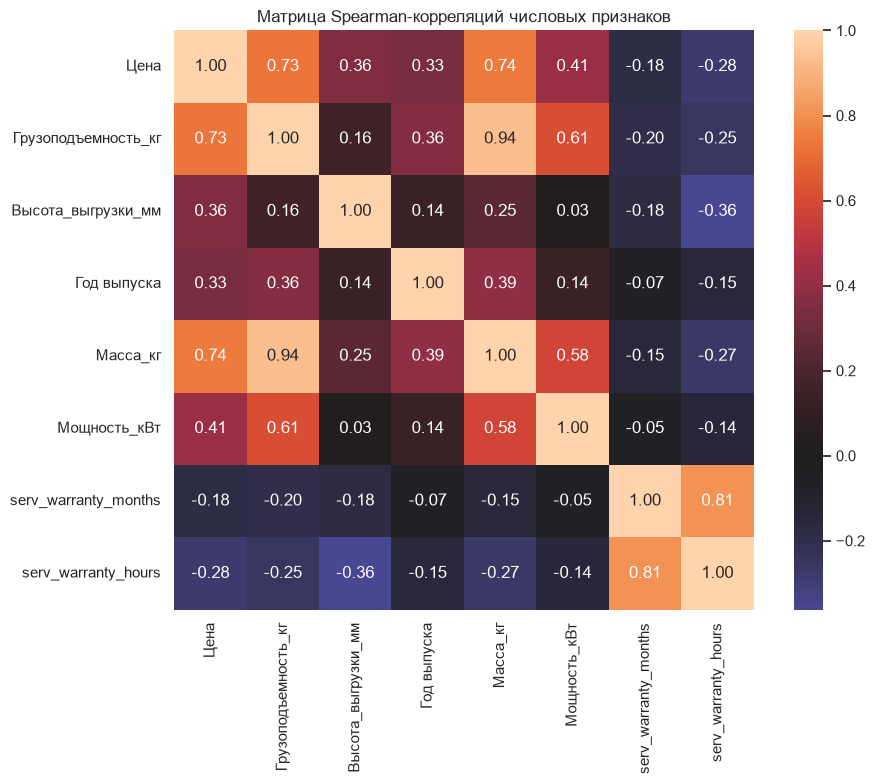

In [240]:
# Строим тепловую матрицу Spearman-корреляций для основных числовых признаков
numeric_cols = [
    "Цена",
    "Грузоподъемность_кг",
    "Высота_выгрузки_мм",
    "Год выпуска",
    "Масса_кг",
    "Мощность_кВт",
    "serv_warranty_months",
    "serv_warranty_hours"
]

corr_spearman = df_fe[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)

plt.title("Матрица Spearman-корреляций числовых признаков")
plt.tight_layout()
plt.show()

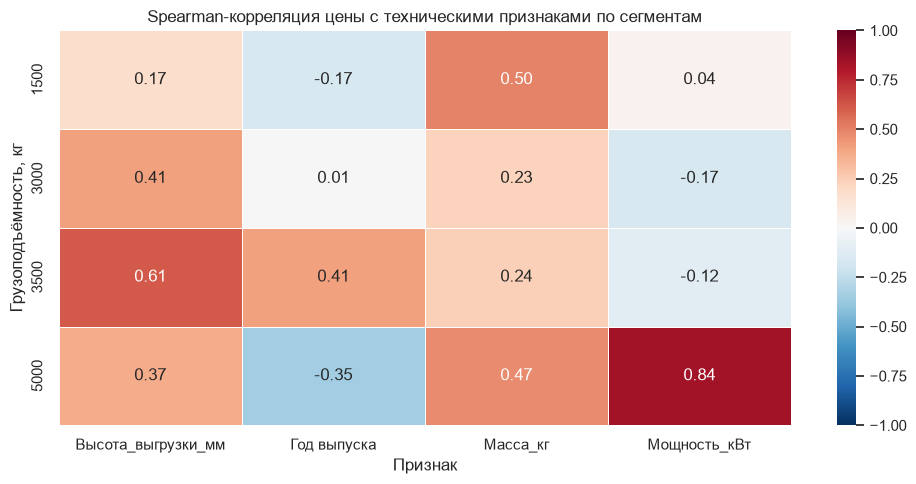

In [241]:


# Считаем Spearman-корреляцию цены с техническими признаками внутри основных сегментов
capacities = [1500, 3000, 3500, 5000]

features = [
    "Масса_кг",
    "Мощность_кВт",
    "Высота_выгрузки_мм",
    "Год выпуска"
]

results = []

for capacity in capacities:
    temp = df_fe[df_fe["Грузоподъемность_кг"] == capacity]

    for feature in features:
        data = temp[["Цена", feature]].dropna()

        rho, p_value = stats.spearmanr(
            data["Цена"],
            data[feature]
        )

        results.append({
            "Грузоподъемность": capacity,
            "Признак": feature,
            "N": len(data),
            "Spearman": rho,
            "p-value": p_value
        })

corr_by_capacity = pd.DataFrame(results)


# Строим тепловую матрицу Spearman-корреляций цены с признаками внутри сегментов
corr_heatmap = corr_by_capacity.pivot(
    index="Грузоподъемность",
    columns="Признак",
    values="Spearman"
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_heatmap,
    annot=True,
    fmt=".2f",
    center=0,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    linewidths=0.5
)

plt.title("Spearman-корреляция цены с техническими признаками по сегментам")
plt.xlabel("Признак")
plt.ylabel("Грузоподъёмность, кг")
plt.tight_layout()
plt.show()

масса — положительная связь в 1,5 и 5 т, слабее в 3 и 3,5 т;<br>
мощность — почти отсутствует в 1,5 т, отрицательная в 3 и 3,5 т, но очень сильная в 5 т;<br>
высота — наиболее последовательно положительная связь, особенно в 3,5 т;<br>
год — сильнее всего проявляется в 3,5 т, но направление меняется в других сегментах.<br>

##### 4.5.2 мощность

In [242]:
# Смотрим распределение мощности и цены внутри сегмента 5 тонн
df_5t = df_fe[df_fe["Грузоподъемность_кг"] == 5000].copy()

print(df_5t["Мощность_кВт"].describe())
print()
print(df_5t["Цена"].describe())

count   180.00
mean     52.06
std      18.61
min      37.00
25%      37.00
50%      37.00
75%      71.00
max      85.00
Name: Мощность_кВт, dtype: float64

count       180.00
mean    3568108.81
std     1190449.10
min     2385909.00
25%     2590000.00
50%     3150000.00
75%     3801500.00
max     6300000.00
Name: Цена, dtype: float64


In [243]:
# Проверяем, есть ли внутри 5-тонного сегмента отдельные группы мощности
df_5t["Мощность_группа"] = pd.cut(
    df_5t["Мощность_кВт"],
    bins=5
)

power_groups = (
    df_5t.groupby("Мощность_группа", observed=True)["Цена"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
)

power_groups

,Мощность_группа,count,median,min,max
0,"(36.952, 46.6]",106,3050000.00,2590000,3665000
1,"(46.6, 56.2]",3,2957000.00,2957000,3007000
2,"(56.2, 65.8]",4,3180000.00,2385909,3180000
3,"(65.8, 75.4]",46,6300000.00,3253000,6300000
4,"(75.4, 85.0]",21,4211000.00,4211000,4696000


In [244]:
# Смотрим, связаны ли диапазоны мощности с конкретными брендами
power_brand = (
    df_5t.groupby(
        ["Мощность_группа", "Марка"],
        observed=True
    )
    .size()
    .reset_index(name="Количество")
    .sort_values(
        ["Мощность_группа", "Количество"],
        ascending=[True, False]
    )
)

power_brand

,Мощность_группа,Марка,Количество
1,"(36.952, 46.6]",Grace,103
0,"(36.952, 46.6]",Goodsense,3
2,"(46.6, 56.2]",Goodsense,3
3,"(56.2, 65.8]",Hangcha,3
4,"(56.2, 65.8]",Trf,1
5,"(65.8, 75.4]",Grace,24
6,"(65.8, 75.4]",Laigong,22
7,"(75.4, 85.0]",Zoomlion,21


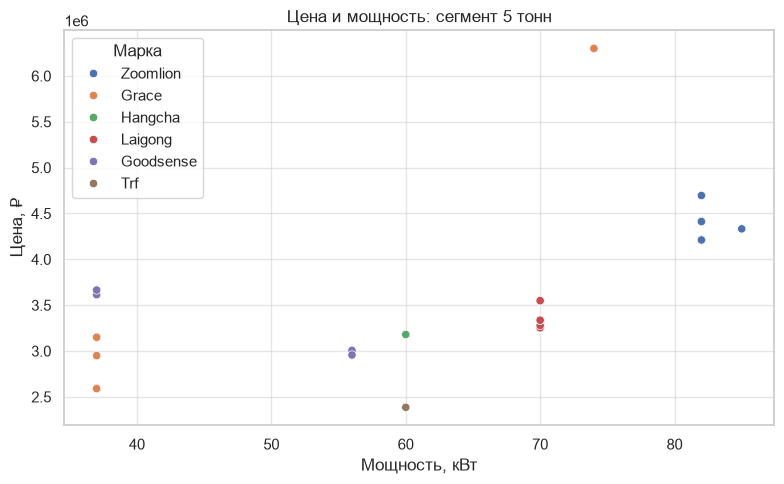

In [245]:
# Смотрим зависимость цены от мощности внутри сегмента 5 тонн
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_5t,
    x="Мощность_кВт",
    y="Цена",
    hue="Марка"
)

plt.title("Цена и мощность: сегмент 5 тонн")
plt.xlabel("Мощность, кВт")
plt.ylabel("Цена, ₽")
plt.tight_layout()
plt.show()

возможно, что сильная связь мощности с ценой в сегменте 5 т отражает различия между техническими и брендовыми подгруппами, а не обязательно самостоятельную ценовую премию за мощность.

In [246]:
# Смотрим структуру мощности, бренда и цены в 5-тонном сегменте
df_5t[
    [
        "Марка",
        "Модель",
        "Мощность_кВт",
        "Цена"
    ]
].sort_values(
    ["Мощность_кВт", "Цена"]
)

,Марка,Модель,Мощность_кВт,Цена
11,Grace,CPCD50,37.00,2590000
32,Grace,CPCD50,37.00,2590000
33,Grace,CPCD50,37.00,2590000
35,Grace,CPCD50,37.00,2590000
36,Grace,CPCD50,37.00,2590000
...,...,...,...,...
1073,Zoomlion,FD50Z,82.00,4412000
1074,Zoomlion,FD50Z,82.00,4412000
1076,Zoomlion,FD50Z,82.00,4412000
1079,Zoomlion,FD50Z,82.00,4696000


In [247]:
# Смотрим медианную цену по брендам внутри 5-тонного сегмента
df_5t.groupby("Марка", observed=True)["Цена"].agg(
    ["count", "median", "min", "max"]
).sort_values("median", ascending=False)

,count,median,min,max
Марка,,,,
Zoomlion,21,4211000.00,4211000,4696000
Laigong,22,3336000.00,3253000,3549000
Goodsense,6,3311000.00,2957000,3665000
Hangcha,3,3180000.00,3180000,3180000
Grace,127,3150000.00,2590000,6300000
Trf,1,2385909.00,2385909,2385909


#####
**итоги по мощности**
Мощность исключается из основной гедонической модели как самостоятельный линейный признак. Глобальная связь мощности с ценой и особенно сильная корреляция<br> внутри сегмента 5 т обусловлены неоднородной структурой предложения: мощность тесно связана с брендом и конкретными моделями техники. <br>
- Поэтому наблюдаемую связь нельзя "гарантировано" интерпретировать, как самостоятельную ценовую характеристику за мощность. (предпологаю, что нужно оценить мощность в модели)

##### 4.5.2 высота выгрузки

In [248]:
# Смотрим распределение высоты подъёма внутри сегмента 3,5 т
df_35t = df_fe[df_fe["Грузоподъемность_кг"] == 3500].copy()

height_stats = (
    df_35t.groupby("Высота_выгрузки_мм", observed=True)["Цена"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
    .sort_values("Высота_выгрузки_мм")
)

height_stats

,Высота_выгрузки_мм,count,median,min,max
0,3000.00,257,1950000.00,1194000,3700000
1,3300.00,4,1830000.00,1830000,1830000
2,4500.00,25,1979850.00,1530000,2654000
3,4800.00,51,2390000.00,2390000,2679000
4,5000.00,9,2490000.00,2490000,2490000


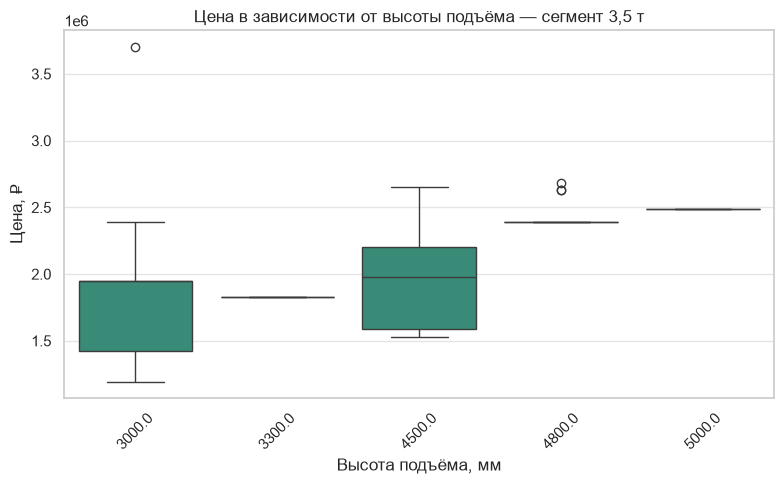

In [249]:
# Смотрим распределение цен по высоте подъёма в сегменте 3,5 т
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_35t,
    x="Высота_выгрузки_мм",
    y="Цена",
    color='#2b997e'
)

plt.title("Цена в зависимости от высоты подъёма — сегмент 3,5 т")
plt.xlabel("Высота подъёма, мм")
plt.ylabel("Цена, ₽")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [250]:
# Проверяем Spearman для цены и высоты в сегменте 3,5 т
rho_all, p_all = stats.spearmanr(
    df_35t["Цена"],
    df_35t["Высота_выгрузки_мм"]
)

print(f"Все наблюдения: Spearman = {rho_all:.3f}, p-value = {p_all:.4f}")

Все наблюдения: Spearman = 0.614, p-value = 0.0000


In [251]:
# Оставляем только высоты, представленные не менее чем 5 объявлениями
height_counts = df_35t["Высота_выгрузки_мм"].value_counts()

valid_heights = height_counts[height_counts >= 5].index

df_35t_common_height = df_35t[
    df_35t["Высота_выгрузки_мм"].isin(valid_heights)
].copy()

rho_common, p_common = stats.spearmanr(
    df_35t_common_height["Цена"],
    df_35t_common_height["Высота_выгрузки_мм"]
)

print(
    f"Только распространённые высоты: "
    f"Spearman = {rho_common:.3f}, p-value = {p_common:.4f}"
)

Только распространённые высоты: Spearman = 0.630, p-value = 0.0000


#####
**итог по высоте выгрузкт**
Высота подъёма сохраняет устойчивую положительную связь с ценой внутри сегмента 3,5 т. Spearman = 0,614 для всей выборки и 0,630 после исключения редких<br> значений высоты (менее 5 наблюдений на категорию), p < 0,001. Следовательно, наблюдаемая зависимость не объясняется только единичными редкими конфигурациями.<br>

- Высота подъёма рассматривается как самостоятельный кандидат в основной модели ценообразования.

##### 4.5.2 год выпуска

In [252]:
# Смотрим количество объявлений и медианную цену по году в сегменте 3,5 т
year_35t = (
    df_35t
    .groupby("Год выпуска", observed=True)["Цена"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
)

year_35t

,Год выпуска,count,median,min,max
0,2023,1,1470000.00,1470000,1470000
1,2024,10,1305000.00,1235000,1429500
2,2025,143,1573936.00,1194000,3700000
3,2026,192,1950000.00,1254008,2490000


In [253]:
# Смотрим распределение брендов по годам внутри сегмента 3,5 т
year_brand_35t = (
    df_35t
    .groupby(["Год выпуска", "Марка"], observed=True)
    .size()
    .reset_index(name="Количество")
    .sort_values(["Год выпуска", "Количество"], ascending=[True, False])
)

year_brand_35t.T

,0,2,1,11,8,7,9,10,4,5,6,3,13,16,21,18,14,12,15,17,20,19
Год выпуска,2023,2024,2024,2025,2025,2025,2025,2025,2025,2025,2025,2025,2026,2026,2026,2026,2026,2026,2026,2026,2026,2026
Марка,Zoomlion,Zoomlion,Liugong,Zoomlion,Liugong,Laigong,Trf,Un,Goodsense,Grace,Jac,Chl,Grace,Leotrack,Zoomlion,Maxora,Hangcha,Cargador,Laigong,Lgmg,Un,Rhinoceros
Количество,1,7,3,44,34,25,13,11,6,6,3,1,105,48,13,7,5,4,4,3,2,1


In [254]:
# Проверяем Spearman между годом и ценой внутри основных брендов сегмента 3,5 т
for brand in df_35t["Марка"].value_counts().head(5).index:
    temp = df_35t[df_35t["Марка"] == brand][
        ["Год выпуска", "Цена"]
    ].dropna()

    if len(temp) >= 10 and temp["Год выпуска"].nunique() >= 3:
        rho, p_value = stats.spearmanr(
            temp["Год выпуска"],
            temp["Цена"]
        )

        print(
            f"{brand}: "
            f"N={len(temp)}, "
            f"Spearman={rho:.3f}, "
            f"p-value={p_value:.4f}"
        )

Zoomlion: N=65, Spearman=0.280, p-value=0.0238


In [255]:
# Проверяем связь года и цены внутри брендов с достаточным количеством наблюдений
brand_year_results = []

for brand, temp in df_35t.groupby("Марка", observed=True):
    temp = temp[["Год выпуска", "Цена"]].dropna()

    if len(temp) >= 10 and temp["Год выпуска"].nunique() >= 2:
        rho, p_value = stats.spearmanr(
            temp["Год выпуска"],
            temp["Цена"]
        )

        brand_year_results.append({
            "Марка": brand,
            "N": len(temp),
            "Количество_лет": temp["Год выпуска"].nunique(),
            "Spearman": rho,
            "p-value": p_value
        })

brand_year_results = pd.DataFrame(brand_year_results).sort_values(
    "N",
    ascending=False
)

brand_year_results

,Марка,N,Количество_лет,Spearman,p-value
0,Grace,111,2,-0.49,0.00
4,Zoomlion,65,4,0.28,0.02
2,Liugong,37,2,0.27,0.11
1,Laigong,29,2,-0.03,0.90
3,Un,13,2,-0.63,0.02


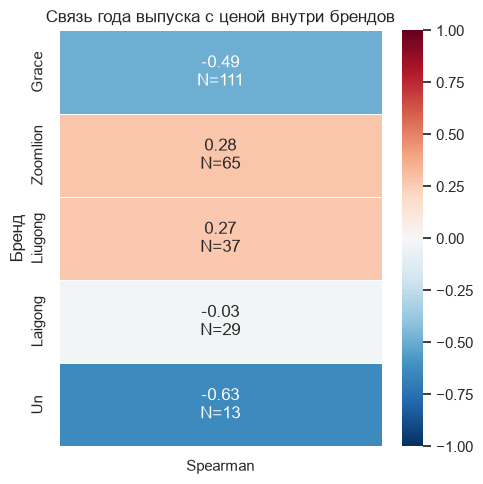

In [256]:
# Добавляем количество наблюдений к подписям матрицы
brand_year_plot = brand_year_results.copy()

brand_year_plot["Подпись"] = (
    brand_year_plot["Spearman"].map(lambda x: f"{x:.2f}")
    + "\nN=" +
    brand_year_plot["N"].astype(str)
)

brand_year_heatmap = brand_year_plot.set_index("Марка")[["Spearman"]]

plt.figure(figsize=(5, 5))

sns.heatmap(
    brand_year_heatmap,
    annot=brand_year_plot.set_index("Марка")[["Подпись"]],
    fmt="",
    center=0,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    linewidths=0.5
)

plt.title("Связь года выпуска с ценой внутри брендов")
plt.xlabel("")
plt.ylabel("Бренд")
plt.tight_layout()
plt.show()

Год выпуска демонстрирует положительную глобальную связь с ценой, однако внутри отдельных брендов направление эффекта неоднородно и может меняться. В сегменте 3,5 т общая корреляция Spearman = 0,41 снижается и меняет направление при контроле бренда (например, Grace: −0,49; Zoomlion: +0,28). Это указывает на значительное влияние структуры брендового предложения на общий эффект года. Поэтому год не следует интерпретировать как самостоятельную универсальную ценовую премию без контроля бренда. Признак сохраняется как кандидат для многомерной модели.

In [257]:
# Смотрим количество объявлений и медианную цену по году в сегменте 5 тонн
year_5t = (
    df_5t
    .groupby("Год выпуска", observed=True)["Цена"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
)

year_5t

,Год выпуска,count,median,min,max
0,2025,39,3549000.00,2385909,4696000
1,2026,141,3150000.00,2590000,6300000


In [258]:
# Смотрим распределение брендов по годам внутри сегмента 5 тонн
year_brand_5t = (
    df_5t
    .groupby(["Год выпуска", "Марка"], observed=True)
    .size()
    .reset_index(name="Количество")
    .sort_values(
        ["Год выпуска", "Количество"],
        ascending=[True, False]
    )
)

year_brand_5t

,Год выпуска,Марка,Количество
2,2025,Laigong,19
4,2025,Zoomlion,15
0,2025,Goodsense,3
1,2025,Grace,1
3,2025,Trf,1
6,2026,Grace,126
9,2026,Zoomlion,6
5,2026,Goodsense,3
7,2026,Hangcha,3
8,2026,Laigong,3


In [259]:
# Проверяем связь года и цены внутри брендов 5-тонного сегмента
brand_year_results_5t = []

for brand, temp in df_5t.groupby("Марка", observed=True):
    temp = temp[["Год выпуска", "Цена"]].dropna()

    if len(temp) >= 10 and temp["Год выпуска"].nunique() >= 2:
        rho, p_value = stats.spearmanr(
            temp["Год выпуска"],
            temp["Цена"]
        )

        brand_year_results_5t.append({
            "Марка": brand,
            "N": len(temp),
            "Количество_лет": temp["Год выпуска"].nunique(),
            "Spearman": rho,
            "p-value": p_value
        })

brand_year_results_5t = (
    pd.DataFrame(brand_year_results_5t)
    .sort_values("N", ascending=False)
)

brand_year_results_5t

,Марка,N,Количество_лет,Spearman,p-value
0,Grace,127,2,0.03,0.75
1,Laigong,22,2,-0.16,0.47
2,Zoomlion,21,2,-0.49,0.03


##### Год выпуска

Год выпуска оставить в качестве кандидата основной модели, но при моделировании проверить его взаимодействие с брендом и/или нелинейное представление.

###
<div class="alert alert-success">
<b>4.5.1 Корреляционный анализ показал:</b><br>
Корреляционный анализ показал, что на цену сильнее всего связаны грузоподъёмность, масса и мощность, однако часть этих связей обусловлена структурой <br>ассортимента и взаимосвязью характеристик. Высота выгрузки показала устойчивую связь с ценой и является важным кандидатом для моделирования, а эффект<br> года выпуска оказался неоднородным и зависит от брендовой структуры. Поэтому окончательное влияние факторов и брендовый эффект целесообразно оценивать <br>уже в многофакторной модели, а не по отдельным корреляциям.

#### 4.5.2 проверка статусных и бинарных признаков


In [260]:
# Проверяем разницу цен между наличием и отсутствием бинарных признаков

binary_features = [
    'nds_mentioned',
    'drive_4wd_mentioned',
    'leasing_mentioned',
    'tradein_mentioned',
    'warranty_mentioned'
]

binary_results = []

for feature in binary_features:

    # Оставляем только наблюдения, где признак имеет значение 0 или 1
    temp = df_fe[df_fe[feature].isin([0, 1])].copy()

    if temp.empty:
        continue

    # Считаем статистику цены отдельно для 0 и 1
    feature_stats = (
        temp
        .groupby(feature)['Цена']
        .agg(
            N='count',
            Медиана='median',
            Среднее='mean'
        )
        .reset_index()
    )

    # Если присутствуют обе группы, рассчитываем разницу
    if set(feature_stats[feature]) == {0, 1}:

        median_0 = feature_stats.loc[
            feature_stats[feature] == 0, 'Медиана'
        ].iloc[0]

        median_1 = feature_stats.loc[
            feature_stats[feature] == 1, 'Медиана'
        ].iloc[0]

        n_0 = feature_stats.loc[
            feature_stats[feature] == 0, 'N'
        ].iloc[0]

        n_1 = feature_stats.loc[
            feature_stats[feature] == 1, 'N'
        ].iloc[0]

        binary_results.append({
            'Признак': feature,
            'N_0': n_0,
            'N_1': n_1,
            'Медиана_0': median_0,
            'Медиана_1': median_1,
            'Разница': median_1 - median_0,
            'Разница_%': (median_1 / median_0 - 1) * 100
        })

binary_results = (
    pd.DataFrame(binary_results)
    .sort_values('Разница_%', ascending=False)
)

binary_results

,Признак,N_0,N_1,Медиана_0,Медиана_1,Разница,Разница_%
1,drive_4wd_mentioned,1015,329,1423000.00,2390000.00,967000.00,67.96
3,tradein_mentioned,1162,182,1494000.00,1950000.00,456000.00,30.52
4,warranty_mentioned,224,1120,1396424.00,1654000.00,257576.00,18.45
2,leasing_mentioned,144,1200,1499002.00,1595000.00,95998.00,6.40
0,nds_mentioned,1212,132,1581060.00,1473000.00,-108060.00,-6.83


In [261]:
# Смотрим долю объявлений с каждым бинарным признаком

binary_share = []

for feature in binary_features:

    temp = df_fe[df_fe[feature].isin([0, 1])]

    binary_share.append({
        'Признак': feature,
        'N': len(temp),
        'Есть_признак': (temp[feature] == 1).sum(),
        'Доля_есть_%': (
            (temp[feature] == 1).mean() * 100
        )
    })

binary_share = pd.DataFrame(binary_share)

binary_share

,Признак,N,Есть_признак,Доля_есть_%
0,nds_mentioned,1344,132,9.82
1,drive_4wd_mentioned,1344,329,24.48
2,leasing_mentioned,1344,1200,89.29
3,tradein_mentioned,1344,182,13.54
4,warranty_mentioned,1344,1120,83.33


проверим признаки внутри классов грузоподъемности

In [262]:
# Сравниваем цену при наличии и отсутствии бинарного признака
# отдельно внутри основных классов грузоподъёмности

binary_features = [
    'nds_mentioned',
    'drive_4wd_mentioned',
    'leasing_mentioned',
    'tradein_mentioned',
    'warranty_mentioned'
]

main_capacities = [1500, 3000, 3500, 5000]

binary_segment_results = []

for feature in binary_features:

    for capacity in main_capacities:

        temp = df_fe[
            (df_fe['Грузоподъемность_кг'] == capacity) &
            (df_fe[feature].isin([0, 1]))
        ].copy()

        # Проверяем, есть ли обе группы: 0 и 1
        if temp[feature].nunique() < 2:
            continue

        feature_stats = (
            temp
            .groupby(feature)['Цена']
            .agg(
                N='count',
                Медиана='median'
            )
        )

        n_0 = feature_stats.loc[0, 'N']
        n_1 = feature_stats.loc[1, 'N']

        median_0 = feature_stats.loc[0, 'Медиана']
        median_1 = feature_stats.loc[1, 'Медиана']

        binary_segment_results.append({
            'Признак': feature,
            'Грузоподъемность_кг': capacity,
            'N_0': n_0,
            'N_1': n_1,
            'Медиана_0': median_0,
            'Медиана_1': median_1,
            'Разница': median_1 - median_0,
            'Разница_%': (median_1 / median_0 - 1) * 100
        })

binary_segment_results = (
    pd.DataFrame(binary_segment_results)
    .sort_values(
        ['Признак', 'Грузоподъемность_кг']
    )
)

binary_segment_results

,Признак,Грузоподъемность_кг,N_0,N_1,Медиана_0,Медиана_1,Разница,Разница_%
4,drive_4wd_mentioned,3500,162,184,1518889.00,1950000.00,431111.00,28.38
5,drive_4wd_mentioned,5000,35,145,4211000.00,3150000.00,-1061000.00,-25.20
6,leasing_mentioned,1500,19,185,1499002.00,1280000.00,-219002.00,-14.61
7,leasing_mentioned,3000,38,196,1463200.00,1456000.00,-7200.00,-0.49
8,leasing_mentioned,3500,38,308,1573936.00,1950000.00,376064.00,23.89
9,leasing_mentioned,5000,5,175,3277850.00,3150000.00,-127850.00,-3.90
0,nds_mentioned,1500,196,8,1280000.00,1091000.00,-189000.00,-14.77
1,nds_mentioned,3000,213,21,1471000.00,1314000.00,-157000.00,-10.67
2,nds_mentioned,3500,315,31,1950000.00,1950000.00,0.00,0.00
3,nds_mentioned,5000,159,21,3150000.00,3150000.00,0.00,0.00


####
<div class="alert alert-success">
<b>4.5.2 анализ статусных и бинарных признаков показал:</b><br>
Были проанализированы признаки, отражающие упоминание НДС, полного привода, лизинга, trade-in и гарантии. Сначала оценивались различия цен в общей выборке, затем внутри основных классов грузоподъёмности, чтобы отделить возможный эффект признака от различий в структуре техники.<br>

В общей выборке наблюдались различия в цене, однако после контроля грузоподъёмности они стали неустойчивыми: для 4WD, лизинга, НДС и trade-in направление и<br> величина различий заметно менялись между сегментами, а отдельные группы имели небольшое число наблюдений.

Для warranty_mentioned наблюдалась более стабильная положительная связь с ценой: в основных сегментах медианная цена объявлений с упоминанием гарантии была<br> выше. Однако данный признак отражает только факт упоминания гарантии в объявлении, а не фактические гарантийные условия. Поэтому выявленную разницу нельзя<br> интерпретировать как влияние самой гарантии на цену: часть продавцов может не указывать гарантию, несмотря на её наличие, а само упоминание может выполнять маркетинговую функцию.

**Итоговое решение**

Все рассмотренные признаки не включаются в основную ценовую модель на текущем этапе. Они сохраняются в исходном df_fe для возможного отдельного анализа<br> маркетингового позиционирования объявлений.

- **Вывод:**<br> Анализ не выявил надёжных оснований считать упоминания НДС, 4WD, лизинга, trade-in или гарантии самостоятельными факторами рыночной цены. <br>Для ценового моделирования приоритет следует отдавать объективным техническим характеристикам и фактическим характеристикам комплектации.

#### 4.5.3 проверка признаков доп опций

сайдшифт и доп навесное

In [263]:
# Сравниваем медианную цену статусов комплектации
# внутри основных классов грузоподъёмности

option_segment_results = []

checks = {
    'opt_sideshift_status': [0, 1, 2],
    'attachment_extra_status': [0, 1, 2]
}

for feature, valid_statuses in checks.items():

    for capacity in [1500, 3000, 3500, 5000]:

        temp = df_fe[
            (df_fe['Грузоподъемность_кг'] == capacity) &
            (df_fe[feature].isin(valid_statuses))
        ].copy()

        feature_stats = (
            temp
            .groupby(feature)['Цена']
            .agg(
                N='count',
                Медиана='median'
            )
            .reset_index()
        )

        feature_stats.insert(0, 'Признак', feature)
        feature_stats.insert(1, 'Грузоподъемность_кг', capacity)

        option_segment_results.append(feature_stats)

option_segment_results = pd.concat(
    option_segment_results,
    ignore_index=True
)

option_segment_results

,Признак,Грузоподъемность_кг,opt_sideshift_status,N,Медиана,attachment_extra_status
0,opt_sideshift_status,1500,0.00,103,1287000.00,NaN
1,opt_sideshift_status,1500,1.00,23,1130000.00,NaN
2,opt_sideshift_status,1500,2.00,41,1130000.00,NaN
3,opt_sideshift_status,3000,0.00,161,1471000.00,NaN
4,opt_sideshift_status,3000,1.00,13,1364000.00,NaN
5,opt_sideshift_status,3000,2.00,23,1210000.00,NaN
6,opt_sideshift_status,3500,0.00,282,1950000.00,NaN
7,opt_sideshift_status,3500,1.00,18,2509500.00,NaN
8,opt_sideshift_status,3500,2.00,34,1971194.00,NaN
9,opt_sideshift_status,5000,0.00,73,2590000.00,NaN


- Сайдшифт
Статус opt_sideshift_status демонстрирует неоднородную связь с ценой. В сегментах 3,5 и 5 т наличие sideshift в комплектации связано с более высоким уровнем медианной цены, тогда как в меньших классах устойчивой премии не наблюдается. Таким образом, sideshift нельзя интерпретировать как универсальную фиксированную надбавку к цене, однако признак является перспективным кандидатом для расширенной многофакторной модели.

- Дополнительное оборудование
attachment_extra_status также связан с различиями в ценовых распределениях. Наиболее заметные различия наблюдаются в более тяжёлых сегментах, однако высокая цена техники с уже установленным дополнительным оборудованием может одновременно отражать более дорогие модели и комплектации. Поэтому самостоятельный ценовой эффект оборудования по результатам EDA не подтверждён, но признак сохраняется как кандидат Extended Model.

трансмиссия

In [264]:
# Проверяем распределение цены по статусам автоматической трансмиссии
# и затем используем только подтверждённый автоматический режим

df_fe.groupby(
    'opt_transmission_auto_status'
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean',
    std='std'
)

,count,median,mean,std
opt_transmission_auto_status,,,,
0,641,1573936.00,1938606.87,1140202.14
1,678,1595000.00,2004710.13,1069620.20
2,25,1130000.00,1185480.00,168292.43


In [265]:
# Сравниваем цену автоматической трансмиссии
# внутри основных классов грузоподъёмности

df_fe[
    df_fe['opt_transmission_auto_status'].isin([0, 1])
].groupby(
    ['Грузоподъемность_кг', 'opt_transmission_auto_status']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг opt_transmission_auto_status                             
1000.00             0                                18  838000.00  819055.56
1500.00             0                                69 1462000.00 1360197.81
                    1                               115 1280000.00 1300587.75
1800.00             0                                17 1434000.00 1373000.00
                    1                                45 1210000.00 1240462.22
2000.00             0                                86 1396424.00 1570112.77
                    1                                48 1220000.00 1360816.04
2500.00             0                                62 1443761.00 1751679.45
                    1                                53 1405821.00 1478866.51
3000.00             0                               139 1523000.00 1611928.22
                    1                                91 1435000.00 1474548.89
3500.00             0                               153 1690000.00 1902711.78
                    1                               192 1950000.00 1859779.22
5000.00             0                                83 2590000.00 3711830.23
                    1                                97 3150000.00 3445130.68
7000.00             1                                13 4436000.00 4528769.23
10000.00            1                                19 5749000.00 5820052.63

- Автоматическая трансмиссия

opt_transmission_auto_status показывает неоднородный эффект в зависимости от грузоподъёмности. В сегментах 3,5–5 т техника с подтверждённой автоматической трансмиссией имеет более высокую медианную цену, однако в меньших классах выраженной ценовой премии не наблюдается. Поэтому признак рассматривается как кандидат Extended Model, а статус гидротрансформатора (2) не приравнивается к подтверждённой автоматической трансмиссии.

сервис

In [266]:
# Проверяем, связана ли цена с упоминанием сервиса
# в общей выборке и внутри основных классов

df_fe.groupby(
    'opt_service_status'
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
)

,count,median,mean
opt_service_status,,,
0,370,1499619.50,1999047.05
1,974,1595000.00,1942330.67


In [267]:
# Проверяем различие цен при наличии и отсутствии
# упоминания сервиса внутри основных классов грузоподъёмности

df_fe.groupby(
    ['Грузоподъемность_кг', 'opt_service_status']
)['Цена'].agg(
    count='count',
    median='median',
    mean='mean'
).query('count >= 10')

count     median       mean
Грузоподъемность_кг opt_service_status                             
1000.00             0                      17  838000.00  835470.59
1500.00             0                      41 1280000.00 1256062.37
                    1                     163 1283000.00 1318329.34
1800.00             0                      18 1363000.00 1356722.22
                    1                      44 1210000.00 1244109.09
2000.00             0                      49 1396424.00 1441117.59
                    1                      85 1445000.00 1526283.60
2500.00             0                      37 1199999.00 1496486.46
                    1                      78 1443761.00 1687359.64
3000.00             0                      69 1588184.00 1645619.88
                    1                     165 1435000.00 1512340.60
3500.00             0                      67 1573936.00 1747288.31
                    1                     279 1950000.00 1910230.09
5000.00             0                      67 3150000.00 4173373.13
                    1                     113 3150000.00 3209235.27
7000.00             1                      15 4436000.00 4351054.13
10000.00            1                      22 5749000.00 5571040.27

Упоминание сервиса (opt_service_status) не демонстрирует устойчивой связи с ценой внутри основных классов грузоподъёмности. Кроме того, признак отражает факт упоминания сервиса в объявлении, а не стоимость или объём сервисного обслуживания. Поэтому в ценовую модель его не включаем.

####
<div class="alert alert-success">
<b>4.5.3 доп опции :</b><br>
- Общий вывод: различия в ценах по комплектации частично сохраняются после контроля грузоподъёмности, однако их величина зависит от сегмента техники. Наиболее перспективными для дальнейшей многофакторной проверки являются sideshift, дополнительное оборудование и автоматическая трансмиссия; их влияние не следует интерпретировать как фиксированную ценовую премию без учёта остальных характеристик.

### 4.5 Итоги:


Проверим связь основных признаков между собой

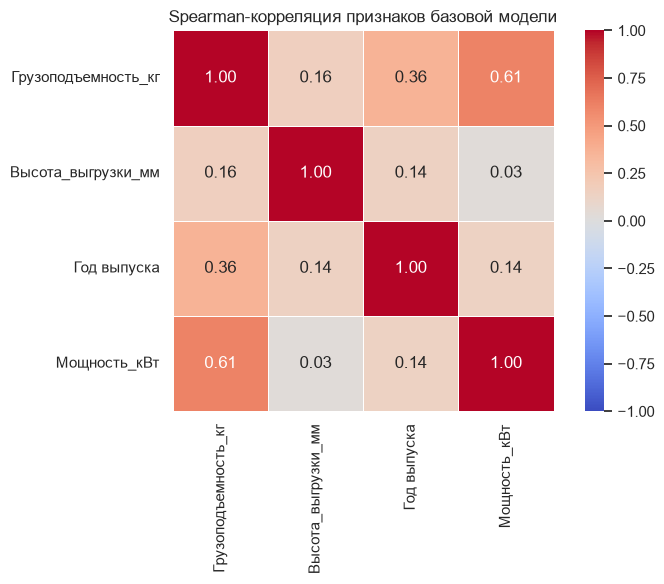

In [268]:
# построим теплову матрицу корреляции Spearmana
base_numeric = [
    'Грузоподъемность_кг',
    'Высота_выгрузки_мм',
    'Год выпуска',
    'Мощность_кВт'
]

corr_base = df_fe[base_numeric].corr(method='spearman')

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_base,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Spearman-корреляция признаков базовой модели')
plt.tight_layout()
plt.show()

####
<div class="alert alert-success">
<b>4.5 Итог :</b><br>
- 4 основных количественных признака;<br>
- 5 расширенных признаков/блоков;<br>
- масса исключена из-за сильного дублирования;<br>
- остальные слабые/нестабильные признаки исключены;<br>
- очевидной критической мультиколлинеарности среди Base-признаков нет.<br>

## ЭТАП 5. Построение гедонической модели и оценка рыночной стоимости характеристик

### сейвим датасет

In [269]:
df_fe['Грузоподъемность_т'] = df_fe['Грузоподъемность_кг'] / 1000
df_fe['Высота_подъема_м'] = df_fe['Высота_выгрузки_мм'] / 1000

In [270]:
# df_fe[['Грузоподъемность_т', 'Высота_подъема_м']]

In [271]:
df_fe = df_fe.drop(
    columns=[
        'Грузоподъемность_кг',
        'Высота_выгрузки_мм'
    ]
)

In [272]:
# df_fe.info()

In [273]:
rename_dict = {
    'Контактное лицо': 'Контактное_лицо',
    'Тип продавца': 'Тип_продавца',
    'Ссылка на объявление': 'Ссылка_на_объявление',
    'Дата поднятия': 'Дата_поднятия',
    'Дата объявления': 'Дата_объявления',
    'Номер объявления': 'Номер_объявления',
    'Сегодня просмотров': 'Сегодня_просмотров',
    'Всего просмотров': 'Всего_просмотров',
    'Год выпуска': 'Год_выпуска',
    'serv_warranty_months': 'Гарантия_месяцев',
    'serv_warranty_hours': 'Гарантия_моточасы',
    'attachment_extra_status': 'Навесное_оборуд',
    'opt_sideshift_status': 'Sideshift',
    'opt_transmission_auto_status': 'Трансмиссия',
    'opt_cabin_status': 'тип_кабины',
    'opt_service_status': 'Сервис.обслуж',
    'util_status': 'статус_утильсбора',
    'util_amount': 'стоимость_утильсбора',
    'nds_mentioned': 'ндс',
    'drive_4wd_mentioned': 'Полный_привод',
    'leasing_mentioned': 'Лизинг',
    'tradein_mentioned': 'Трайд-ин',
    'warranty_mentioned': 'Наличие_гарантии'

}

df_fe = df_fe.rename(columns=rename_dict)

In [274]:
df_fe.head(1)

,Продавец,Контактное_лицо,Тип_продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка_на_объявление,Дата_поднятия,Дата_объявления,Номер_объявления,Широта,Долгота,Параметры,Сегодня_просмотров,Всего_просмотров,Марка,Модель,Год_выпуска,Мощность_кВт,Масса_кг,Состояние,ПТС_ПСМ,Доступность,Гарантия_месяцев,Гарантия_моточасы,Навесное_оборуд,Sideshift,Трансмиссия,тип_кабины,Сервис.обслуж,статус_утильсбора,стоимость_утильсбора,ндс,Полный_привод,Лизинг,Трайд-ин,Наличие_гарантии,Грузоподъемность_т,Высота_подъема_м
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная теxника для cкладa и прoизводcтва\n\nЕсли вы ищeт...,1400000,Удмуртия,Ижевск,Нет метро,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spetstehnika/vilochnyy_pogruzchik_liugong_cpcd20_2024_8...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.78,53.18,Марка: LiuGong;Модель: CPCD20;Тип техники: Вилочный погрузчик;Год выпуска: 2024;Высота выгрузки:...,44,601,Liugong,CPCD20,2024,40.00,3370.00,Новое,Оригинал,В наличии,NaN,NaN,0,1,0,0,0,0,NaN,0,0,0,0,0,2.00,3.00


In [275]:
# сохраним датасет для моделированичя
df_final = df_fe.copy()

In [276]:
df_final.to_csv('../../data/fk_analysis/forklift_ml_dataset.csv', index=False, encoding='utf-8-sig')
print(f"Итоговый df_final сохранён: {df_final.shape[0]} строк, {df_final.shape[1]} колонок")

Итоговый df_final сохранён: 1344 строк, 43 колонок


In [277]:
df_final = pd.read_csv(
    '../../data/fk_analysis/forklift_ml_dataset.csv',
    encoding='utf-8-sig'
)

In [278]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Продавец              1344 non-null   str    
 1   Контактное_лицо       1344 non-null   str    
 2   Тип_продавца          1344 non-null   str    
 3   Заголовок             1344 non-null   str    
 4   Описание              1344 non-null   str    
 5   Цена                  1344 non-null   int64  
 6   Регион                1344 non-null   str    
 7   Город                 1344 non-null   str    
 8   Метро2                1344 non-null   str    
 9   Адрес                 1344 non-null   str    
 10  Ссылка_на_объявление  1344 non-null   str    
 11  Дата_поднятия         1344 non-null   str    
 12  Дата_объявления       1344 non-null   str    
 13  Номер_объявления      1344 non-null   int64  
 14  Широта                1344 non-null   float64
 15  Долгота               1344 non-n

### 5.1. Base Model

In [279]:
df_model = df_final[
    [
        'Цена',
        'Грузоподъемность_т',
        'Высота_подъема_м',
        'Год_выпуска',
        'Мощность_кВт'
    ]
].copy()

In [280]:
# создадим датасет для базовой модели
base_features = [
    'Цена',
    'Грузоподъемность_т',
    'Высота_подъема_м',
    'Год_выпуска',
    'Мощность_кВт'
]

df_model = df_final[base_features].copy()

# проверим структуру модельного датасета
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Цена                1344 non-null   int64  
 1   Грузоподъемность_т  1344 non-null   float64
 2   Высота_подъема_м    1344 non-null   float64
 3   Год_выпуска         1344 non-null   int64  
 4   Мощность_кВт        1344 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 52.6 KB


In [281]:
# проверим пропуски в признаках базовой модели
df_model.isna().sum()

Цена                  0
Грузоподъемность_т    0
Высота_подъема_м      0
Год_выпуска           0
Мощность_кВт          0
dtype: int64

In [282]:
# проверим полные дубликаты наблюдений
df_model.duplicated().sum()

np.int64(1042)

In [283]:
# посмотрим основные статистики признаков
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
Цена,1344.00,1957944.55,1099619.48,480000.00,1273561.50,1573936.00,2206000.00,10699000.00
Грузоподъемность_т,1344.00,3.12,1.53,0.80,2.00,3.00,3.50,16.00
Высота_подъема_м,1344.00,3.43,0.80,2.00,3.00,3.00,3.00,6.50
Год_выпуска,1344.00,2025.24,0.67,2023.00,2025.00,2025.00,2026.00,2026.00
Мощность_кВт,1344.00,37.62,15.23,2.00,34.00,37.00,39.25,129.00


In [284]:
# посмотрим распределение целевой переменной
df_model['Цена'].describe()

count       1344.00
mean     1957944.55
std      1099619.48
min       480000.00
25%      1273561.50
50%      1573936.00
75%      2206000.00
max     10699000.00
Name: Цена, dtype: float64

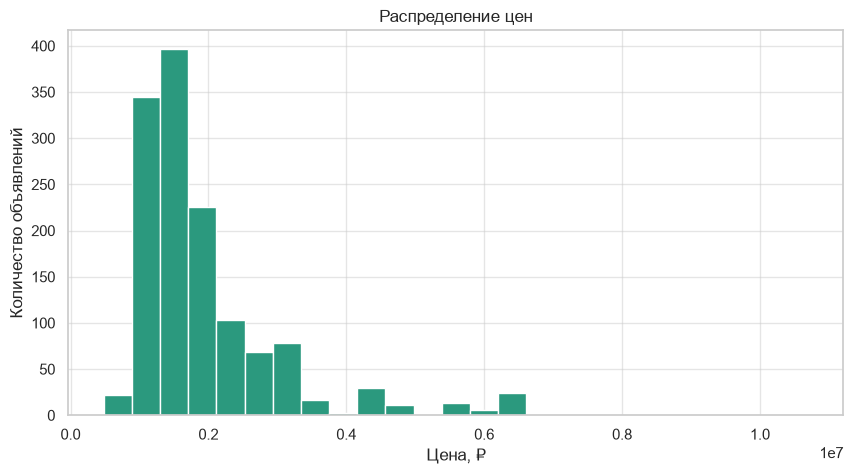

In [285]:
# построим распределение цены
plt.figure(figsize=(10, 5))
plt.hist(
    df_model['Цена'],
    bins=25,
    color='#2b997e',
    edgecolor='white'
)

plt.xlabel('Цена, ₽')
plt.ylabel('Количество объявлений')
plt.title('Распределение цен')
plt.show()

Данные распределены не нормально. будем строить модель ччерез log()  для более ровного распределения

In [286]:
# разделим данные на обучающую и тестовую выборки

X = df_model[
    [
        'Грузоподъемность_т',
        'Высота_подъема_м',
        'Год_выпуска',
        'Мощность_кВт'
    ]
]

y = np.log(df_model['Цена'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (1075, 4)
Test: (269, 4)


In [287]:
# построим базовую гедоническую модель
X_train_sm = sm.add_constant(X_train)

base_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

print(base_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     739.0
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          5.21e-306
Time:                        06:51:42   Log-Likelihood:                 76.471
No. Observations:                1075   AIC:                            -142.9
Df Residuals:                    1070   BIC:                            -118.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               -146.4056     22

In [288]:
# получим прогнозы базовой модели
X_test_sm = sm.add_constant(X_test)

y_pred = base_model.predict(X_test_sm)

# вернем прогноз из логарифма в рубли
price_pred = np.exp(y_pred)
price_actual = np.exp(y_test)

In [289]:
# оценим качество модели на тестовой выборке
mae = mean_absolute_error(price_actual, price_pred)
rmse = np.sqrt(mean_squared_error(price_actual, price_pred))
r2 = r2_score(price_actual, price_pred)

print(f'MAE:  {mae:,.0f} ₽')
print(f'RMSE: {rmse:,.0f} ₽')
print(f'R²:   {r2:.3f}')

MAE:  370,621 ₽
RMSE: 620,629 ₽
R²:   0.682


Модель объясняет 73,4% вариации **логарифма** цены на обучающей выборке и 68,2% на тестовой. Снижение R² на тесте относительно небольшое — около 5,2 п.п., поэтому выраженного переобучения не наблюдается

Средняя абсолютная ошибка прогноза составляет около 371 тыс. ₽, а RMSE — около 621 тыс. ₽. Разница между MAE и RMSE указывает на наличие отдельных объявлений с существенно большей ошибкой.
- вывод:

Базовая техническая модель уже достаточно хорошо описывает рыночное ценообразование: только четыре технических характеристики объясняют около 68% вариации цены на новых данных.

#### диагностика Base Model

In [290]:
# проверим мультиколлинеарность признаков
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()

vif = pd.DataFrame({
    'Признак': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values('VIF', ascending=False)

,Признак,VIF
2,Год_выпуска,25.48
1,Высота_подъема_м,19.73
3,Мощность_кВт,15.74
0,Грузоподъемность_т,11.25


vif > 10. проведем проверку, масштабируем показатели

In [291]:
# стандартизируем признаки для диагностической модели
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

# построим стандартизированную диагностическую модель
X_train_scaled_sm = sm.add_constant(X_train_scaled)

scaled_model = sm.OLS(
    y_train,
    X_train_scaled_sm
).fit()

print(scaled_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     739.0
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          5.21e-306
Time:                        06:51:42   Log-Likelihood:                 76.471
No. Observations:                1075   AIC:                            -142.9
Df Residuals:                    1070   BIC:                            -118.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.3766      0

In [292]:
# проверим VIF после стандартизации
vif_scaled = pd.DataFrame({
    'Признак': X_train_scaled.columns,
    'VIF': [
        variance_inflation_factor(
            X_train_scaled.values,
            i
        )
        for i in range(X_train_scaled.shape[1])
    ]
})

vif_scaled.sort_values('VIF', ascending=False)

,Признак,VIF
0,Грузоподъемность_т,2.44
3,Мощность_кВт,2.28
2,Год_выпуска,1.11
1,Высота_подъема_м,1.02


R² = 0.734 и т-статистики не поменялись. оставляем модель без масштабирования

In [293]:
# проверим гетероскедастичность остатков
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    base_model.resid,
    base_model.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        'LM Statistic',
        'LM p-value',
        'F Statistic',
        'F p-value'
    ]
)

bp_results

LM Statistic   9.53
LM p-value     0.05
F Statistic    2.39
F p-value      0.05
dtype: float64

Тест Бройша–Пагана дал пограничный результат (p ≈ 0,05), поэтому для статистических выводов использованы робастные HC3 стандартные ошибки.

In [294]:
# получим результаты модели с робастными стандартными ошибками
base_model_robust = base_model.get_robustcov_results(
    cov_type='HC3'
)

print(base_model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     456.7
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          1.35e-229
Time:                        06:51:42   Log-Likelihood:                 76.471
No. Observations:                1075   AIC:                            -142.9
Df Residuals:                    1070   BIC:                            -118.0
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               -146.4056     24

###

<div class="alert alert-success">
<b> 5.1 Base model :</b><br>
- Базовая гедоническая модель на основе грузоподъёмности, высоты подъёма, года выпуска и мощности объясняет 73,4% вариации логарифма рыночной цены на <br>обучающей выборке и 68,2% на тестовой. Все четыре технических характеристики имеют статистически значимый положительный эффект. Диагностика не выявила<br> критической мультиколлинеарности; после стандартизации максимальный VIF составил 2,44. Из-за пограничного результата теста Бройша–Пагана для статистических<br> выводов использованы робастные HC3 стандартные ошибки, при которых значимость всех факторов сохранилась.

### 5.2. Extended model

In [295]:
# создадим датасет для расширенной модели
extended_cols = [
    'Цена',
    'Марка',
    'Грузоподъемность_т',
    'Высота_подъема_м',
    'Год_выпуска',
    'Мощность_кВт',
    'Sideshift',
    'Навесное_оборуд',
    'Трансмиссия'
]

df_model_extended = df_final[extended_cols].copy()

In [296]:
# # проверим структуру датасета
# df_model_extended.info()

In [297]:
# проверим пропуски
df_model_extended.isna().sum()

Цена                  0
Марка                 0
Грузоподъемность_т    0
Высота_подъема_м      0
Год_выпуска           0
Мощность_кВт          0
Sideshift             0
Навесное_оборуд       0
Трансмиссия           0
dtype: int64

In [298]:
# посмотрим распределение брендов
df_model_extended['Марка'].value_counts()

Марка
Zoomlion      441
Grace         238
Liugong       123
Laigong       109
Trf            68
Goodsense      53
Leotrack       48
Teu            48
Hangcha        41
Chl            37
Maxora         21
Kandela        20
Xilin          17
Cargador       16
Un             13
Glavman        11
Tfn             7
Komatsu         6
Lgmg            6
Jac             5
Afl             4
Мксм            2
Oxlift          2
Maxlion         2
Noblelift       2
Ep              2
Manforce        1
Rhinoceros      1
Name: count, dtype: int64

In [299]:
# переведем марку в категориальный тип
df_model_extended['Марка'] = df_model_extended['Марка'].astype('category')

In [300]:
# проверим структуру датасета
df_model_extended.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Цена                1344 non-null   int64   
 1   Марка               1344 non-null   category
 2   Грузоподъемность_т  1344 non-null   float64 
 3   Высота_подъема_м    1344 non-null   float64 
 4   Год_выпуска         1344 non-null   int64   
 5   Мощность_кВт        1344 non-null   float64 
 6   Sideshift           1344 non-null   int64   
 7   Навесное_оборуд     1344 non-null   int64   
 8   Трансмиссия         1344 non-null   int64   
dtypes: category(1), float64(3), int64(5)
memory usage: 85.7 KB


In [301]:
# проверим уникальные значения дополнительных признаков
df_model_extended[
    ['Sideshift', 'Навесное_оборуд', 'Трансмиссия']
].nunique()

Sideshift          4
Навесное_оборуд    4
Трансмиссия        3
dtype: int64

In [302]:
# # посмотрим распределение значений дополнительных признаков
# for col in ['Sideshift', 'Навесное_оборуд', 'Трансмиссия']:
#     print(f'\n{col}')
#     print(df_model_extended[col].value_counts().sort_index())

In [303]:
# заново сформируем признаки для расширенной модели
X_ext = df_model_extended[
    [
        'Марка',
        'Грузоподъемность_т',
        'Высота_подъема_м',
        'Год_выпуска',
        'Мощность_кВт',
        'Sideshift',
        'Навесное_оборуд',
        'Трансмиссия'
    ]
].copy()

выбираем марку Zoomlion тк она сама я распространенная более 400 позиций в датасете

In [304]:
# зададим Zoomlion базовой категорией
X_ext['Марка'] = X_ext['Марка'].cat.reorder_categories(
    ['Zoomlion'] + [x for x in X_ext['Марка'].cat.categories if x != 'Zoomlion'],
    ordered=False
)

In [305]:
# закодируем категориальные признаки через dummy-переменные
X_ext = pd.get_dummies(
    X_ext,
    columns=[
        'Марка',
        'Sideshift',
        'Навесное_оборуд',
        'Трансмиссия'
    ],
    drop_first=True,
    dtype=int
)

In [306]:
# проверим dummy-признаки бренда
# [col for col in X_ext.columns if col.startswith('Марка_')]

In [307]:
# проверим структуру признаков после кодирования
# X_ext.info()

In [308]:
# выделим и логарифмируем целевую переменную
y_ext = np.log(df_model_extended['Цена'])

In [309]:
# разделим данные на обучающую и тестовую выборки
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext,
    y_ext,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train_ext.shape}')
print(f'Test: {X_test_ext.shape}')

Train: (1075, 39)
Test: (269, 39)


In [310]:
# зададим числовые признаки для масштабирования
numeric_ext = [
    'Грузоподъемность_т',
    'Высота_подъема_м',
    'Год_выпуска',
    'Мощность_кВт'
]

# создадим scaler для расширенной модели
scaler_ext = StandardScaler()

# обучим scaler на train и преобразуем train
X_train_ext[numeric_ext] = scaler_ext.fit_transform(
    X_train_ext[numeric_ext]
)

# преобразуем test с помощью scaler, обученного на train
X_test_ext[numeric_ext] = scaler_ext.transform(
    X_test_ext[numeric_ext]
)

In [311]:
# проверим масштабирование числовых признаков
X_train_ext[numeric_ext].describe().loc[['mean', 'std']].round(2)

,Грузоподъемность_т,Высота_подъема_м,Год_выпуска,Мощность_кВт
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00


In [312]:
# добавим константу в расширенную модель
X_train_ext_sm = sm.add_constant(X_train_ext)

# построим расширенную гедоническую модель
extended_model = sm.OLS(
    y_train_ext,
    X_train_ext_sm
).fit()

print(extended_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     155.1
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        06:51:42   Log-Likelihood:                 385.84
No. Observations:                1075   AIC:                            -693.7
Df Residuals:                    1036   BIC:                            -499.5
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.4016      0

In [313]:
# проверим мультиколлинеарность расширенной модели

X_vif_ext = X_train_ext.copy()

vif_ext = pd.DataFrame({
    'Признак': X_vif_ext.columns,
    'VIF': [
        variance_inflation_factor(
            X_vif_ext.values,
            i
        )
        for i in range(X_vif_ext.shape[1])
    ]
})

vif_ext = (
    vif_ext
    .sort_values('VIF', ascending=False)
    .reset_index(drop=True)
)

vif_ext.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
Признак,Трансмиссия_1,Навесное_оборуд_3,Грузоподъемность_т,Sideshift_2,Мощность_кВт,Навесное_оборуд_2,Sideshift_1,Марка_Grace,Sideshift_3,Марка_Teu,Марка_Chl,Год_выпуска,Трансмиссия_2,Марка_Laigong,Навесное_оборуд_1,Высота_подъема_м,Марка_Goodsense,Марка_Hangcha,Марка_Kandela,Марка_Leotrack,Марка_Glavman,Марка_Xilin,Марка_Lgmg,Марка_Liugong,Марка_Cargador,Марка_Maxora,Марка_Tfn,Марка_Trf,Марка_Afl,Марка_Rhinoceros,Марка_Noblelift,Марка_Мксм,Марка_Komatsu,Марка_Un,Марка_Ep,Марка_Maxlion,Марка_Jac,Марка_Oxlift,Марка_Manforce
VIF,4.13,3.84,3.84,3.65,3.52,3.50,3.27,3.23,2.93,2.89,2.48,2.43,2.23,2.21,2.12,2.07,1.99,1.72,1.45,1.36,1.32,1.19,1.19,1.16,1.14,1.14,1.07,1.06,1.05,1.03,1.03,1.03,1.03,1.03,1.02,1.01,1.00,1.00,NaN


- Extended Model существенно лучше Base Model: R² вырос с 0.734 до 0.851, то есть добавление брендов и комплектаций заметно повысило объясняющую способность модели.
- Все ключевые технические характеристики статистически значимы.
- Мультиколлинеарность приемлемая: все VIF < 5, критичных значений нет.
- Однако очень редкие бренды требуют дополнительной проверки перед финальной интерпретацией модели.
- Коэффициенты брендов и опций пока не интерпретируем как ценовые премии — сначала завершаем диагностику модели.

**Итог:** <br>Расширение модели оправдано и существенно улучшило качество, но перед финальными бизнес-выводами нужно обработать редкие категории и провести итоговую диагностику.

In [314]:
# проверим гетероскедастичность расширенной модели

bp_test_ext = het_breuschpagan(
    extended_model.resid,
    extended_model.model.exog
)

bp_results_ext = pd.Series(
    bp_test_ext,
    index=[
        'LM Statistic',
        'LM p-value',
        'F Statistic',
        'F p-value'
    ]
)

bp_results_ext

LM Statistic   254.34
LM p-value       0.00
F Statistic      8.45
F p-value        0.00
dtype: float64

h0 -  о постоянной дисперсии ошибок отвергается.

В Extended Model присутствует гетероскедастичность — величина ошибки модели зависит от уровня/характеристик наблюдения.

In [315]:
# пересчитаем стандартные ошибки с поправкой на гетероскедастичность
extended_model_hc3 = extended_model.get_robustcov_results(
    cov_type='HC3'
)

print(extended_model_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     296.7
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        06:51:42   Log-Likelihood:                 385.84
No. Observations:                1075   AIC:                            -693.7
Df Residuals:                    1036   BIC:                            -499.5
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.4016      0

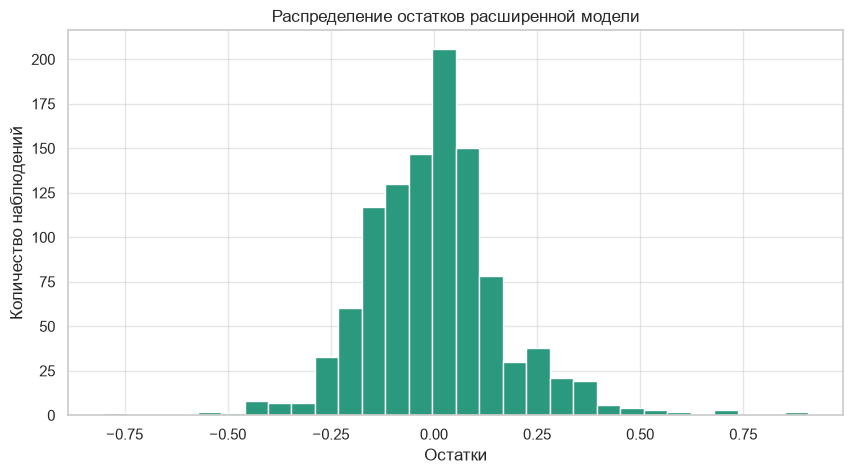

In [316]:
# получим остатки расширенной модели
residuals_ext = extended_model_hc3.resid

# построим распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(
    residuals_ext,
    bins=30,
    color='#2b997e',
    edgecolor='white'
)

plt.xlabel('Остатки')
plt.ylabel('Количество наблюдений')
plt.title('Распределение остатков расширенной модели')
plt.show()

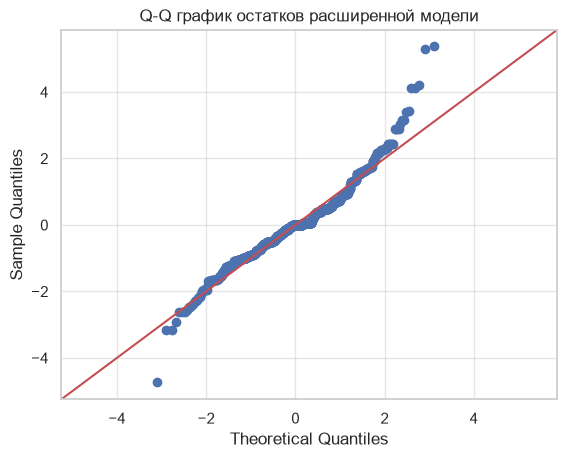

In [317]:
# построим Q-Q график остатков
fig = sm.qqplot(
    residuals_ext,
    line='45',
    fit=True
)

plt.title('Q-Q график остатков расширенной модели')
plt.show()

In [318]:
# проверим нормальность остатков
jb_test_ext = stats.jarque_bera(residuals_ext)

print(f'JB Statistic: {jb_test_ext.statistic:.2f}')
print(f'p-value: {jb_test_ext.pvalue:.4f}')

JB Statistic: 445.59
p-value: 0.0000


In [319]:
# Получаем прогнозы Extended Model на тестовой выборке

X_test_ext_sm = sm.add_constant(X_test_ext)

y_pred_ext = extended_model.predict(X_test_ext_sm)

# Возвращаем прогноз из log(Цена) в рубли
price_pred_ext = np.exp(y_pred_ext)
price_actual_ext = np.exp(y_test_ext)

In [320]:
# Оцениваем качество Extended Model на тестовой выборке

mae_ext = mean_absolute_error(
    price_actual_ext,
    price_pred_ext
)

rmse_ext = np.sqrt(
    mean_squared_error(
        price_actual_ext,
        price_pred_ext
    )
)

r2_ext = r2_score(
    price_actual_ext,
    price_pred_ext
)

print(f'MAE:  {mae_ext:,.0f} ₽')
print(f'RMSE: {rmse_ext:,.0f} ₽')
print(f'R²:   {r2_ext:.3f}')

MAE:  239,519 ₽
RMSE: 353,686 ₽
R²:   0.897


###

<div class="alert alert-success">
<b> 5.2 Extended model :</b><br>
Расширенная гедоническая модель, включающая технические характеристики, марку и признаки комплектации, существенно улучшила качество объяснения и <br>прогнозирования цены по сравнению с базовой моделью.<br>

На обучающей выборке модель объясняет 85,1% вариации логарифма цены, а на тестовой — 89,7% вариации цены. Средняя абсолютная ошибка прогноза составляет около<br> 240 тыс. ₽, RMSE — около 354 тыс. ₽.<br>

Разрыв между результатами обучающей и тестовой выборок не указывает на выраженное переобучение. Добавление категориальных характеристик позволило заметно <br>повысить точность модели относительно базовой: R² на тестовой выборке вырос с 68,2% до 89,7%.
</div>

### 5.3 Сравнение Base model и Extended model

таблица сравнения показателей `Base model` и `Extended model`
| Показатель                                 |  Base Model | Extended Model |
| ------------------------------------------ | ----------: | -------------: |
| Технические характеристики                 |           ✓ |              ✓ |
| Марка                                      |           — |              ✓ |
| Комплектация                               |           — |              ✓ |
| R² Test                                    |       0.682 |      **0.897** |
| MAE                                        | ~371 тыс. ₽ |  **239 519 ₽** |
| RMSE                                       | ~621 тыс. ₽ |  **353 686 ₽** |
| Удельные эффекты технических характеристик |           ✓ |              ✓ |
| Эффекты брендов                            |           — |              ✓ |
| Эффекты комплектации                       |           — |              ✓ |



Расширенная модель существенно превосходит базовую по качеству прогнозирования. На тестовой выборке R² увеличился с 0,682 до 0,897, MAE снизилась примерно на 35%, а RMSE — примерно на 43%. Добавление марки и характеристик комплектации существенно повысило объясняющую способность модели.

#### 5.3.1 Интерпретация коэффициентов

In [321]:
numeric_ext = [
    'Грузоподъемность_т',
    'Высота_подъема_м',
    'Год_выпуска',
    'Мощность_кВт'
]

In [322]:
# коэффициенты расширенной модели
coef_ext = pd.Series(
    extended_model_hc3.params,
    index=extended_model_hc3.model.exog_names
)

coef_ext

const                14.40
Грузоподъемность_т    0.20
Высота_подъема_м      0.04
Год_выпуска           0.05
Мощность_кВт          0.12
Марка_Afl            -0.31
Марка_Cargador       -0.21
Марка_Chl            -0.24
Марка_Ep              0.29
Марка_Glavman        -0.35
Марка_Goodsense      -0.05
Марка_Grace           0.19
Марка_Hangcha        -0.35
Марка_Jac             0.06
Марка_Kandela        -0.33
Марка_Komatsu         1.09
Марка_Laigong         0.05
Марка_Leotrack        0.11
Марка_Lgmg           -0.41
Марка_Liugong        -0.15
Марка_Manforce        0.00
Марка_Maxlion        -0.17
Марка_Maxora         -0.09
Марка_Noblelift      -0.23
Марка_Oxlift         -0.46
Марка_Rhinoceros     -0.28
Марка_Teu             0.23
Марка_Tfn             0.20
Марка_Trf            -0.23
Марка_Un             -0.22
Марка_Xilin          -0.09
Марка_Мксм           -0.21
Sideshift_1           0.15
Sideshift_2           0.05
Sideshift_3           0.03
Навесное_оборуд_1     0.14
Навесное_оборуд_2     0.12
Н

In [323]:
# стандартные отклонения исходных числовых признаков
numeric_std = df_model_extended[numeric_ext].std()

numeric_std

Грузоподъемность_т    1.53
Высота_подъема_м      0.80
Год_выпуска           0.67
Мощность_кВт         15.23
dtype: float64

In [324]:
# перевод коэффициентов из стандартизированной шкалы
# в исходные единицы измерения

coef_original = coef_ext.copy()

for feature in numeric_ext:
    coef_original[feature] = (
        coef_ext[feature] / numeric_std[feature]
    )

coef_original

const                14.40
Грузоподъемность_т    0.13
Высота_подъема_м      0.05
Год_выпуска           0.07
Мощность_кВт          0.01
Марка_Afl            -0.31
Марка_Cargador       -0.21
Марка_Chl            -0.24
Марка_Ep              0.29
Марка_Glavman        -0.35
Марка_Goodsense      -0.05
Марка_Grace           0.19
Марка_Hangcha        -0.35
Марка_Jac             0.06
Марка_Kandela        -0.33
Марка_Komatsu         1.09
Марка_Laigong         0.05
Марка_Leotrack        0.11
Марка_Lgmg           -0.41
Марка_Liugong        -0.15
Марка_Manforce        0.00
Марка_Maxlion        -0.17
Марка_Maxora         -0.09
Марка_Noblelift      -0.23
Марка_Oxlift         -0.46
Марка_Rhinoceros     -0.28
Марка_Teu             0.23
Марка_Tfn             0.20
Марка_Trf            -0.23
Марка_Un             -0.22
Марка_Xilin          -0.09
Марка_Мксм           -0.21
Sideshift_1           0.15
Sideshift_2           0.05
Sideshift_3           0.03
Навесное_оборуд_1     0.14
Навесное_оборуд_2     0.12
Н

#### 5.3.2 Удельные ценовые эффекты

##### base model


In [325]:
# Бизнес-интерпретация базовой модели

base_unit_effects = []

for feature in X.columns:

    beta = base_model.params[feature]

    percent_effect = (np.exp(beta) - 1) * 100

    base_unit_effects.append({
        'Признак': feature,
        'Коэффициент_log': beta,
        'Изменение цены, %': percent_effect
    })

base_unit_effects = pd.DataFrame(base_unit_effects)

base_unit_effects

,Признак,Коэффициент_log,"Изменение цены, %"
0,Грузоподъемность_т,0.16,17.04
1,Высота_подъема_м,0.15,15.83
2,Год_выпуска,0.08,8.20
3,Мощность_кВт,0.01,0.70


In [326]:
# Перевод процентного эффекта базовой модели в рубли

median_price_base = df_model['Цена'].median()

base_unit_effects['Медианная цена, ₽'] = median_price_base

base_unit_effects['Эффект, ₽'] = (
    median_price_base *
    (np.exp(base_unit_effects['Коэффициент_log']) - 1)
)

base_unit_effects

,Признак,Коэффициент_log,"Изменение цены, %","Медианная цена, ₽","Эффект, ₽"
0,Грузоподъемность_т,0.16,17.04,1573936.00,268262.56
1,Высота_подъема_м,0.15,15.83,1573936.00,249081.16
2,Год_выпуска,0.08,8.20,1573936.00,128985.71
3,Мощность_кВт,0.01,0.70,1573936.00,11007.70


##### Extended model

In [327]:
# точный процентный эффект одной исходной единицы

unit_effects = []

for feature in numeric_ext:

    beta = coef_original[feature]

    percent_effect = (np.exp(beta) - 1) * 100

    unit_effects.append({
        'Признак': feature,
        'Коэффициент_log': beta,
        'Изменение цены, %': percent_effect
    })

unit_effects = pd.DataFrame(unit_effects)

unit_effects

,Признак,Коэффициент_log,"Изменение цены, %"
0,Грузоподъемность_т,0.13,13.99
1,Высота_подъема_м,0.05,5.57
2,Год_выпуска,0.07,7.55
3,Мощность_кВт,0.01,0.80


In [328]:
median_price = df_model_extended['Цена'].median()

unit_effects['Медианная цена, ₽'] = median_price

unit_effects['Эффект, ₽'] = (
    median_price *
    (np.exp(unit_effects['Коэффициент_log']) - 1)
)

unit_effects

,Признак,Коэффициент_log,"Изменение цены, %","Медианная цена, ₽","Эффект, ₽"
0,Грузоподъемность_т,0.13,13.99,1573936.00,220122.04
1,Высота_подъема_м,0.05,5.57,1573936.00,87717.77
2,Год_выпуска,0.07,7.55,1573936.00,118909.71
3,Мощность_кВт,0.01,0.80,1573936.00,12532.31


Сводная таблица сравнение удельных эффектов технических характеристик

| Техническая характеристика | Base Model, ₽/ед. | Extended Model, ₽/ед. | Base, % | Extended, % |
| -------------------------- | ----------------: | --------------------: | ------: | ----------: |
| **Грузоподъёмность, +1 т** |     **268 263 ₽** |         **220 122 ₽** |  17,04% |      13,99% |
| **Высота подъёма, +1 м**   |     **249 081 ₽** |          **87 718 ₽** |  15,83% |       5,57% |
| **Год выпуска, +1 год**    |     **128 986 ₽** |         **118 910 ₽** |   8,20% |       7,55% |
| **Мощность, +1 кВт**       |      **11 008 ₽** |          **12 532 ₽** |   0,70% |       0,80% |

    Расчёт выполнен относительно медианной цены техники 1 573 936 ₽. Эффект показывает ориентировочное изменение цены при увеличении
    соответствующего числового признака на одну исходную единицу при прочих равных условиях.

<div class="alert alert-success"> <b>5.3. Сравнение Base и Extended Model:</b><br>
Extended Model показывает существенно более высокое качество прогнозирования цены: R² на тестовой выборке вырос с 0,682 до 0,897, а MAE снизилась примерно <br>с 371 тыс. до 240 тыс. ₽. Это подтверждает, что бренд и характеристики комплектации содержат существенную информацию о рыночной цене.<br><br>

При контроле за брендом и комплектацией оценка влияния технических характеристик изменилась. Наиболее значимым фактором остаётся грузоподъёмность: <br>увеличение на 1 т связано с ростом расчётной цены примерно на 220 тыс. ₽. Один дополнительный метр высоты подъёма соответствует примерно 88 тыс. ₽,<br> год выпуска — около 119 тыс. ₽, а 1 кВт мощности — около 12,5 тыс. ₽.<br><br>

Base Model целесообразно использовать для оценки общего вклада технических характеристик, а Extended Model — как основную модель для рыночной оценки, <br>поскольку она учитывает одновременно технические характеристики, бренд и комплектацию.

</div>

### 5.4 Анализ премии за бренды Extended Model

In [329]:
# Коэффициенты брендов относительно базового бренда Zoomlion

brand_coef = pd.DataFrame({
    'Бренд': X_train_ext_sm.columns,
    'Коэффициент_log': extended_model_hc3.params,
    'p_value': extended_model_hc3.pvalues
})

# оставляем только dummy-переменные брендов
brand_coef = brand_coef[
    brand_coef['Бренд'].str.startswith('Марка_')
].copy()

# убираем префикс
brand_coef['Бренд'] = (
    brand_coef['Бренд']
    .str.replace('Марка_', '', regex=False)
)

# переводим коэффициент log(Цена)
# в процентную премию / дисконт относительно Zoomlion
brand_coef['Премия_дисконт_%'] = (
    np.exp(brand_coef['Коэффициент_log']) - 1
) * 100

# округление
brand_coef['Коэффициент_log'] = brand_coef['Коэффициент_log'].round(4)
brand_coef['Премия_дисконт_%'] = brand_coef['Премия_дисконт_%'].round(1)
brand_coef['p_value'] = brand_coef['p_value'].round(4)

brand_coef = brand_coef.sort_values(
    'Премия_дисконт_%',
    ascending=False
)

brand_coef

,Бренд,Коэффициент_log,p_value,Премия_дисконт_%
15,Komatsu,1.09,0.00,198.20
8,Ep,0.29,0.00,33.20
26,Teu,0.23,0.00,25.20
27,Tfn,0.20,0.16,21.70
11,Grace,0.19,0.00,20.30
17,Leotrack,0.11,0.02,12.10
13,Jac,0.06,0.21,5.80
16,Laigong,0.05,0.07,5.60
20,Manforce,0.00,0.63,0.00
10,Goodsense,-0.05,0.51,-4.90


### 5.4. Премия за бренд в Extended Model

Премия бренда относительно Zoomlion:

| Бренд   | Премия/дисконт | Как понимать                                            |
| ------- | -------------: | ------------------------------------------------------- |
| Komatsu |      **+198%** | модель оценивает технику почти в 3 раза дороже Zoomlion |
| EP      |       **+33%** | примерно на треть дороже                                |
| TEU     |       **+25%** | примерно на четверть дороже                             |
| Grace   |       **+20%** | примерно на пятую часть дороже                          |
| Liugong |       **−14%** | примерно на 14% дешевле                                 |
| Hangcha |       **−30%** | примерно на 30% дешевле                                 |
| Lgmg    |       **−34%** | примерно на треть дешевле                               |
| Oxlift  |       **−37%** | примерно на 37% дешевле                                 |



Расширенная гедоническая модель позволяет оценить ценовую премию или дисконт бренда относительно базовой категории **Zoomlion** при прочих равных характеристиках техники.

Наиболее выраженная премия наблюдается у **Komatsu (+198,2%)**. Также статистически значимые положительные эффекты выявлены для **EP (+33,2%)**, **TEU (+25,2%)**, **Grace (+20,3%)** и **Leotrack (+12,1%)**. Эти бренды в рамках модели продаются с ценовой премией относительно Zoomlion после учёта технических характеристик и комплектации.

Ряд брендов имеет статистически значимый ценовой дисконт относительно Zoomlion. Наиболее выраженный дисконт наблюдается у **Lgmg (−33,9%)**, **Hangcha и Glavman (по −29,6%)**, **Kandela (−27,8%)** и **Chl (−21,0%)**. Это указывает на позиционирование данных марок преимущественно в более доступном ценовом сегменте при сопоставимых характеристиках техники.

Для части брендов наблюдаемые премии или дисконты статистически не подтверждены. В частности, коэффициенты **Tfn, Jac, Laigong, Goodsense, Xilin, Maxlion и Manforce** не имеют статистической значимости на уровне 5%. Для редких брендов **Noblelift, Rhinoceros и Oxlift** также не следует интерпретировать полученные крупные дисконты как устойчивый эффект бренда из-за высокой неопределённости оценок.

**Практический вывод:** рынок демонстрирует выраженную дифференциацию брендов по цене. Часть производителей имеет статистически подтверждённую ценовую премию и может использовать бренд как элемент ценности предложения, тогда как другие конкурируют преимущественно более низкой ценой. При этом величины премий и дисконтов следует рассматривать как оценки модели, а не как фиксированную рыночную наценку.

- **Примечание:**
Если две машины одинаковы по грузоподъёмности, высоте, году, мощности и комплектации, но одна Komatsu, а другая Zoomlion, то модель оценивает Komatsu примерно на +198% дороже относительно Zoomlion

### 5.5 Анализ комплектации Extended Model

In [330]:
# Интерпретация коэффициентов комплектации
# относительно базового состояния (0)

option_coef = pd.DataFrame({
    'Признак': X_train_ext_sm.columns,
    'Коэффициент_log': extended_model_hc3.params,
    'p_value': extended_model_hc3.pvalues
})

# оставляем только признаки комплектации
option_coef = option_coef[
    option_coef['Признак'].str.startswith(
        ('Sideshift_', 'Навесное_оборуд_', 'Трансмиссия_')
    )
].copy()

# переводим коэффициенты log(Цена) в процентное изменение цены
option_coef['Премия_дисконт_%'] = (
    np.exp(option_coef['Коэффициент_log']) - 1
) * 100

# округляем
option_coef['Коэффициент_log'] = option_coef['Коэффициент_log'].round(4)
option_coef['Премия_дисконт_%'] = option_coef['Премия_дисконт_%'].round(1)
option_coef['p_value'] = option_coef['p_value'].round(4)

option_coef = option_coef.sort_values(
    'Премия_дисконт_%',
    ascending=False
)

option_coef

,Признак,Коэффициент_log,p_value,Премия_дисконт_%
32,Sideshift_1,0.15,0.00,15.60
35,Навесное_оборуд_1,0.14,0.00,14.50
36,Навесное_оборуд_2,0.12,0.00,12.90
33,Sideshift_2,0.05,0.22,5.00
34,Sideshift_3,0.03,0.44,3.30
37,Навесное_оборуд_3,-0.04,0.30,-3.90
39,Трансмиссия_2,-0.13,0.12,-12.30
38,Трансмиссия_1,-0.18,0.00,-16.90


### таблица признаков комплектации

| Элемент комплектации  | Эффект относительно базового состояния | p-value | Интерпретация                  |
| --------------------- | -------------------------------------: | ------: | ------------------------------ |
| **Sideshift_1**       |                             **+15,6%** |  <0,001 | статистически значимая премия  |
| **Навесное_оборуд_1** |                             **+14,5%** |  <0,001 | статистически значимая премия  |
| **Навесное_оборуд_2** |                             **+12,9%** |  <0,001 | статистически значимая премия  |
| Sideshift_2           |                                  +5,0% |    0,22 | эффект не подтверждён          |
| Sideshift_3           |                                  +3,3% |    0,44 | эффект не подтверждён          |
| Навесное_оборуд_3     |                                  −3,9% |    0,30 | эффект не подтверждён          |
| Трансмиссия_2         |                                 −12,3% |    0,12 | эффект не подтверждён          |
| **Трансмиссия_1**     |                             **−16,9%** |  <0,001 | статистически значимый дисконт |


где:
- Sideshift : 1-входит в комплектацию; 2 — дополнительная опция или под заказ;3 — неоднозначный случай.
- Навесное_оборуд : 1 -установлено; 2  — оборудование предлагается как дополнительная опция; 3 — однозначно определить нельзя.
- Трансмиссия : 1 — автомат подтверждён; 2 — указан гидротрансформатор, но это не считается автоматически подтверждением автомата.


### 5.6 Анализ ошибок Extended Model

In [331]:
# Прогноз Extended Model на тестовой выборке

X_test_ext_sm = sm.add_constant(X_test_ext)

y_pred_ext = extended_model_hc3.predict(X_test_ext_sm)

# возвращаемся из log(Цена) в рубли
price_pred_ext = np.exp(y_pred_ext)
price_actual_ext = np.exp(y_test_ext)

# создаём таблицу ошибок
error_analysis = pd.DataFrame({
    'Цена_факт': price_actual_ext,
    'Цена_прогноз': price_pred_ext
})

error_analysis['Ошибка'] = (
    error_analysis['Цена_факт'] -
    error_analysis['Цена_прогноз']
)

error_analysis['Абсолютная_ошибка'] = (
    error_analysis['Ошибка'].abs()
)

error_analysis['Ошибка_%'] = (
    error_analysis['Ошибка'] /
    error_analysis['Цена_факт'] * 100
)

error_analysis.head()

,Цена_факт,Цена_прогноз,Ошибка,Абсолютная_ошибка,Ошибка_%
286,795000.00,838000.00,-43000.00,43000.00,-5.41
261,1530000.00,1813878.15,-283878.15,283878.15,-18.55
963,1120000.00,1420313.19,-300313.19,300313.19,-26.81
210,1443761.00,1440653.64,3107.36,3107.36,0.22
221,3395000.00,3192054.95,202945.05,202945.05,5.98


полная таблица ошибок

In [332]:
# исходные характеристики тестовой выборки
error_analysis = df_model_extended.loc[
    X_test_ext.index,
    [
        'Цена',
        'Марка',
        'Грузоподъемность_т',
        'Высота_подъема_м',
        'Год_выпуска',
        'Мощность_кВт'
    ]
].copy()

# добавляем прогноз
error_analysis['Цена_прогноз'] = price_pred_ext

# ошибка: факт - прогноз
error_analysis['Ошибка'] = (
    error_analysis['Цена'] -
    error_analysis['Цена_прогноз']
)

# абсолютная ошибка
error_analysis['Абсолютная_ошибка'] = (
    error_analysis['Ошибка'].abs()
)

# относительная ошибка
error_analysis['Ошибка_%'] = (
    error_analysis['Ошибка'] /
    error_analysis['Цена'] * 100
)

error_analysis.head()

,Цена,Марка,Грузоподъемность_т,Высота_подъема_м,Год_выпуска,Мощность_кВт,Цена_прогноз,Ошибка,Абсолютная_ошибка,Ошибка_%
286,795000,Xilin,1.00,3.00,2024,2.00,838000.00,-43000.00,43000.00,-5.41
261,1530000,Zoomlion,3.50,4.50,2025,36.00,1813878.15,-283878.15,283878.15,-18.55
963,1120000,Zoomlion,1.80,4.80,2024,32.00,1420313.19,-300313.19,300313.19,-26.81
210,1443761,Liugong,2.50,3.00,2026,35.00,1440653.64,3107.36,3107.36,0.22
221,3395000,Laigong,6.00,3.00,2025,70.00,3192054.95,202945.05,202945.05,5.98


ошибки по грузоподъемности

In [333]:
capacity_error = (
    error_analysis
    .groupby('Грузоподъемность_т')
    .agg(
        N=('Цена', 'count'),
        MAE=('Абсолютная_ошибка', 'mean'),
        RMSE=('Ошибка', lambda x: np.sqrt(np.mean(x ** 2))),
        Средняя_ошибка=('Ошибка', 'mean'),
        Средняя_ошибка_проц=('Ошибка_%', 'mean')
    )
    .reset_index()
)

capacity_error

,Грузоподъемность_т,N,MAE,RMSE,Средняя_ошибка,Средняя_ошибка_проц
0,1.00,5,8600.00,19230.18,-8600.00,-1.08
1,1.50,48,148323.30,236554.97,84167.96,5.02
2,1.60,1,1130229.23,1130229.23,1130229.23,59.49
3,1.80,9,141790.05,167147.87,-141790.05,-13.06
4,2.00,25,220005.90,258557.35,46550.54,0.36
5,2.50,25,224492.19,258637.30,22769.53,-0.08
6,3.00,40,259821.67,309534.75,-2465.30,-2.18
7,3.50,71,133560.64,198944.70,-20091.26,-2.90
8,5.00,36,496960.32,614385.78,268290.89,4.58
9,6.00,1,202945.05,202945.05,202945.05,5.98


ошибки по брендам

In [334]:
brand_error = (
    error_analysis
    .groupby('Марка')
    .agg(
        N=('Цена', 'count'),
        MAE=('Абсолютная_ошибка', 'mean'),
        Средняя_ошибка=('Ошибка', 'mean'),
        Средняя_ошибка_проц=('Ошибка_%', 'mean')
    )
    .reset_index()
    .sort_values('MAE', ascending=False)
)

brand_error

,Марка,N,MAE,Средняя_ошибка,Средняя_ошибка_проц
15,Noblelift,1,1130229.23,1130229.23,59.49
13,Manforce,1,421470.29,421470.29,21.29
6,Jac,2,401983.92,-401983.92,-35.26
3,Goodsense,5,359182.37,42709.65,-3.91
22,Zoomlion,82,338273.19,107097.28,-0.59
8,Komatsu,3,304840.65,-24093.61,-0.31
20,Un,1,278745.64,-278745.64,-22.23
17,Teu,13,273327.41,14576.54,0.87
19,Trf,20,257482.62,56718.95,3.85
5,Hangcha,8,250586.74,180539.95,7.02


Наихудшие объявления , которые обрабатывает модель

In [335]:
largest_errors = (
    error_analysis
    .sort_values('Абсолютная_ошибка', ascending=False)
    [
        [
            'Цена',
            'Цена_прогноз',
            'Ошибка',
            'Ошибка_%',
            'Марка',
            'Грузоподъемность_т',
            'Высота_подъема_м',
            'Год_выпуска',
            'Мощность_кВт'
        ]
    ]
    .head(20)
)

largest_errors

,Цена,Цена_прогноз,Ошибка,Ошибка_%,Марка,Грузоподъемность_т,Высота_подъема_м,Год_выпуска,Мощность_кВт
1079,4696000,3171815.45,1524184.55,32.46,Zoomlion,5.00,4.50,2025,82.00
1233,4637000,3350728.11,1286271.89,27.74,Zoomlion,7.00,3.00,2025,82.00
1077,4211000,2924832.76,1286167.24,30.54,Zoomlion,5.00,3.00,2025,82.00
113,4332306,3093068.84,1239237.16,28.60,Zoomlion,5.00,3.00,2025,85.00
23,3180000,1955128.71,1224871.29,38.52,Hangcha,5.00,3.00,2026,60.00
481,1900000,769770.77,1130229.23,59.49,Noblelift,1.60,3.00,2023,9.00
1247,4436000,3350728.11,1085271.89,24.47,Zoomlion,7.00,3.00,2025,82.00
243,4436000,3350728.11,1085271.89,24.47,Zoomlion,7.00,3.00,2025,82.00
1216,4436000,3350728.11,1085271.89,24.47,Zoomlion,7.00,3.00,2025,82.00
746,4211000,3148897.71,1062102.29,25.22,Zoomlion,5.00,3.00,2026,82.00


###

<div class="alert alert-success">
<b>5.6. Анализ ошибок Extended Model:</b><br>

Модель наиболее стабильно работает в основных сегментах рынка с достаточным количеством наблюдений. В классах грузоподъёмности 1,5–3,5 т средняя ошибка составляет порядка 130–260 тыс. ₽, при этом выраженного систематического завышения или занижения цены не наблюдается. В сегменте 5 т ошибка возрастает до примерно 497 тыс. ₽, а модель в среднем занижает цену примерно на 4,6%.

Наиболее высокие ошибки наблюдаются в отдельных крупных классах грузоподъёмности (6–10 т) и по некоторым брендам с малым количеством наблюдений. Эти результаты не следует интерпретировать как устойчивую закономерность из-за небольшого размера соответствующих подвыборок.

Для основных брендов с достаточным количеством наблюдений выраженного систематического смещения прогнозов не выявлено. Это указывает на то, что основные различия цен в целом достаточно хорошо учитываются включёнными в модель техническими характеристиками, брендом и комплектацией.

Повышение ошибки в крупных классах может быть связано с меньшим количеством наблюдений и дополнительными характеристиками техники, которые не представлены в модели: особенностями комплектации, исполнения, состояния техники и другими факторами продавца.

<b>Вывод:</b> Extended Model обеспечивает достаточно точное прогнозирование в основных сегментах рынка, однако её точность снижается для крупных и малочисленных сегментов. Поэтому прогнозы для таких сегментов следует использовать с большей осторожностью.

</div>


### Этап 5.7. Практическое применение модели — калькулятор прогнозной цены

In [336]:
def predict_price(
    грузоподъемность,
    высота_подъема,
    год_выпуска,
    мощность,
    марка,
    sideshift,
    навесное_оборуд,
    трансмиссия
):
    '''
    Рассчитывает прогнозную рыночную цену складской техники
    на основе расширенной OLS-модели.

    Модель прогнозирует логарифм цены, после чего результат
    преобразуется обратно в рубли.

    Параметры
    ----------
    грузоподъемность : float
        Грузоподъёмность техники в тоннах.
        Например: 1.5, 2.0, 3.5, 5.0.

    высота_подъема : float
        Высота подъёма в метрах.
        Например: 3.0, 4.5, 6.0.

    год_выпуска : int
        Год выпуска техники.
        Например: 2025 или 2026.

    мощность : float
        Мощность двигателя в кВт.
        Например: 36 или 41.

    марка : str
        Бренд техники.
        Значение должно соответствовать одной из марок,
        использованных при обучении расширенной модели.

    sideshift : int
        Статус бокового смещения (Sideshift).
        Используются значения, соответствующие кодировке
        признака в исходном датасете.

    навесное_оборуд : int
        Статус дополнительного навесного оборудования.
        Используются значения, соответствующие кодировке
        признака в исходном датасете.

    трансмиссия : int
        Код типа трансмиссии.
        Используются значения, соответствующие кодировке
        признака в исходном датасете.

    Возвращает
    ----------
    float
        Прогнозная цена техники в рублях.

    Логика расчёта
    --------------
    1. Введённые характеристики преобразуются в DataFrame.
    2. Категориальные признаки переводятся в dummy-переменные.
    3. Набор признаков приводится к структуре, использованной
       при обучении модели.
    4. Числовые признаки масштабируются тем же scaler,
       который использовался при обучении.
    5. Модель прогнозирует log(Цена).
    6. Экспоненцирование возвращает прогноз в исходную
       денежную шкалу — рубли.

    Важно
    -----
    Функция использует текущую версию расширенной модели,
    обученной на исторических данных проекта.

    Полученная цена является оценкой рыночного уровня,
    а не гарантированной ценой продажи конкретной единицы
    техники.

    Точность прогноза ограничена ошибкой модели:
        MAE ≈ 239 519 ₽
        RMSE ≈ 353 686 ₽
    '''

    # создаём одну строку с исходными признаками
    input_data = pd.DataFrame([{
        'Грузоподъемность_т': грузоподъемность,
        'Высота_подъема_м': высота_подъема,
        'Год_выпуска': год_выпуска,
        'Мощность_кВт': мощность,
        'Марка': марка,
        'Sideshift': sideshift,
        'Навесное_оборуд': навесное_оборуд,
        'Трансмиссия': трансмиссия
    }])

    # переводим категориальные признаки в dummy
    input_data = pd.get_dummies(
        input_data,
        columns=[
            'Марка',
            'Sideshift',
            'Навесное_оборуд',
            'Трансмиссия'
        ],
        drop_first=False,
        dtype=int
    )

    # создаём все признаки, которые использовались при обучении
    model_features = X_train_ext.columns

    # добавляем отсутствующие dummy-признаки
    for col in model_features:
        if col not in input_data.columns:
            input_data[col] = 0

    # оставляем только признаки модели
    input_data = input_data[model_features]

    # масштабируем числовые признаки
    input_data[numeric_ext] = scaler_ext.transform(
        input_data[numeric_ext]
    )

    # добавляем константу
    input_data_sm = sm.add_constant(
        input_data,
        has_constant='add'
    )

    # прогнозируем log(Цена)
    log_price_pred = extended_model.predict(input_data_sm)

    # возвращаем прогноз из логарифма в рубли
    price_pred = np.exp(log_price_pred.iloc[0])

    return price_pred

ввод параметров для калькуляции цены

In [337]:
price = predict_price(
    грузоподъемность=3.5,
    высота_подъема=4.5,
    год_выпуска=2025,
    мощность=36,
    марка='Zoomlion',
    sideshift=0,
    навесное_оборуд=2,
    трансмиссия=1
)

print(f'Прогнозная цена: {price:,.0f} ₽')

Прогнозная цена: 1,813,878 ₽


проверка № 1

In [338]:
real_config = df_model_extended[
    (df_model_extended['Грузоподъемность_т'] == 3.5) &
    (df_model_extended['Высота_подъема_м'] == 4.5) &
    (df_model_extended['Год_выпуска'] == 2025) &
    (df_model_extended['Мощность_кВт'] == 36) &
    (df_model_extended['Марка'] == 'Zoomlion') &
    (df_model_extended['Sideshift'] == 0) &
    (df_model_extended['Навесное_оборуд'] == 2) &
    (df_model_extended['Трансмиссия'] == 1)
].copy()

real_config[
    [
        'Цена',
        'Марка',
        'Грузоподъемность_т',
        'Высота_подъема_м',
        'Год_выпуска',
        'Мощность_кВт',
        'Sideshift',
        'Навесное_оборуд',
        'Трансмиссия'
    ]
].sort_values('Цена').head(5)

,Цена,Марка,Грузоподъемность_т,Высота_подъема_м,Год_выпуска,Мощность_кВт,Sideshift,Навесное_оборуд,Трансмиссия
219,1530000,Zoomlion,3.50,4.50,2025,36.00,0,2,1
261,1530000,Zoomlion,3.50,4.50,2025,36.00,0,2,1
279,1530000,Zoomlion,3.50,4.50,2025,36.00,0,2,1
411,1530000,Zoomlion,3.50,4.50,2025,36.00,0,2,1
416,1530000,Zoomlion,3.50,4.50,2025,36.00,0,2,1


по результатам 1 проверки выдало завышение ~15%

Проверка № 2

In [339]:
price_hangcha = predict_price(
    грузоподъемность=3.5,
    высота_подъема=3,
    год_выпуска=2026,
    мощность=41,
    марка='Hangcha',
    sideshift=2,
    навесное_оборуд=3,
    трансмиссия=1
)

print(f'Прогнозная цена: {price_hangcha:,.0f} ₽')

Прогнозная цена: 1,179,712 ₽


In [340]:
# по жесткому фильтру не отрабатывает поиск поэтому просто по таблице искал совпадения( и да есть такие объявления по указанным параметрам выше)
# вывод большой


# hangcha_data = df_model_extended[
#     df_model_extended['Марка'] == 'Hangcha'
# ].copy()
#
# hangcha_data[
#     [
#         'Цена',
#         'Марка',
#         'Грузоподъемность_т',
#         'Высота_подъема_м',
#         'Год_выпуска',
#         'Мощность_кВт',
#         'Sideshift',
#         'Навесное_оборуд',
#         'Трансмиссия'
#     ]
# ].sort_values('Цена')

занижение на ~2%

###
<div class="alert alert-success">
<b>5.7. Практическое применение модели — калькулятор прогнозной цены:</b><br>

Для проверки практической применимости расширенной модели были протестированы две реальные конфигурации техники с разными наборами характеристик и брендами.


<b>1. Zoomlion:</b> прогнозная цена отличалась от фактической примерно на <b>+15%</b>. Это означает, что модель оценила конфигурацию выше фактической цены объявления. Такое расхождение показывает, что модель может учитывать не все особенности конкретного коммерческого предложения, включая индивидуальную ценовую стратегию продавца.


<b>2. Hangcha:</b> прогнозная цена составила около <b>1,18 млн ₽</b> против фактических <b>1,21 млн ₽</b>. Расхождение составило около <b>−2%</b>, то есть прогноз практически совпал с рыночной ценой конкретного объявления.


<b>Вывод:</b><br>
Калькулятор позволяет получить ориентир рыночной цены для заданной конфигурации техники без необходимости вручную рассчитывать коэффициенты модели. При этом прогноз следует рассматривать как <b>рыночный ориентир, а не точную цену продажи</b>: фактическая цена конкретного объявления может отличаться из-за коммерческой стратегии продавца, особенностей комплектации и других характеристик, не учтённых в модели.

Таким образом, расширенная модель может использоваться менеджером как инструмент первичной оценки ценового уровня новой или существующей конфигурации техники и для выявления потенциального отклонения цены от наблюдаемого рыночного уровня.<br>
Расширенная модель имеет среднюю абсолютную ошибку около 240 тыс. ₽ на тестовой выборке. При этом фактическая ошибка отдельной конфигурации может быть как существенно ниже, так и выше этого значения. Поэтому прогноз калькулятора следует использовать как ориентир рыночного уровня цены, а не как точное значение стоимости конкретного предложения.

</div>


### 5.8 сохранение моделей:

In [342]:
model_objects = {
    'base_model': base_model,
    'extended_model': extended_model,
    'scaler_ext': scaler_ext,
    'extended_features': X_train_ext.columns.tolist(),
    'numeric_ext': numeric_ext
}

joblib.dump(
    model_objects,
    '../../models/forklift_price_analysis/forklift_price_models.pkl'
)

print('Финальные модели и параметры калькулятора сохранены.')

Финальные модели и параметры калькулятора сохранены.
